In [1]:
#import packages
import os
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

#set global options
pd.options.display.max_columns = 100
pd.options.display.max_rows = 50
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_color_codes('muted')

In [2]:
path = "D:\\project\\data_analyst\\data\\"
os.listdir(path)

frame = []
for file in os.listdir(path):
    if file.endswith('.parquet'):
        filepath = path + file
        tmp_frame = pd.read_parquet(filepath)
        frame.append(tmp_frame)
        df = pd.concat(frame)

df.head()

,id,collected_time,create_time,desc,duet_display,duet_enabled,duet_info_duet_from_id,is_ad,item_comment_status,item_mute,item_control_can_repost,official_item,original_item,share_enabled,playlist_id,stitch_display,stitch_enabled,diversification_id,stats_time,collect_count,comment_count,digg_count,play_count,share_count,vq_score,duration,share_cover,poi_id,poi_name,address,city,city_code,country_code,poi_category,father_poi_id,father_poi_name,poi_tt_type_code,poi_tt_type_name_medium,poi_tt_type_name_super,poi_tt_type_name_tiny,user_id,user_avatar_larger,user_avatar_medium,user_avatar_thumb,user_tt_seller,user_verified,challenges,music_id,music_title,music_album,music_author_name,music_duration,music_original,music_play_url,url
0,7279117710833749291,2025-06-07 07:16:15.841855+02,1694801681,Replying to @Elena Respondiendo a nuestra ami...,0,t,0.0,f,0,f,t,f,f,t,NaN,0,t,10026.0,2025-06-07 07:16:19.516867+02,39,17,166,3179,16,64.57,134,"{"""",https://p16-pu-sign-useast8.tiktokcdn-us.c...",22535796482274243,Inglewood,"Inglewood, CA",None,5359488.0,6252001,Place and Address,None,None,19a3a0,Places,Place and Address,City,6807573152556139525,https://p19-pu-sign-useast8.tiktokcdn-us.com/t...,https://p19-pu-sign-useast8.tiktokcdn-us.com/t...,https://p19-pu-sign-useast8.tiktokcdn-us.com/t...,f,f,"[""catrinasmakeup"",""catrinas"",""diademuertos"",""d...",7.138674e+18,Margarita,Margarita,BLVKSHP,88.0,f,https://sf16.tiktokcdn-us.com/obj/tos-alisg-ve...,https://tiktok.com/@/video/7279117710833749291
1,7498561028544826655,2025-04-29 05:59:44.080905+02,1745894801,Warriors start hot out the gate 🔥 | Rockets vs...,0,t,0.0,f,0,f,t,f,f,t,NaN,0,t,10059.0,2025-04-29 07:56:14.078751+02,9,13,166,8037,0,55.52,52,"{"""",https://p16-pu-sign-useast8.tiktokcdn-us.c...",21568226347362205,Chase Center Arena,"1 Warriors Way, San Francisco, CA 94158, Unite...",San Francisco,5391997.0,6252001,Recreation and Sport,San Francisco,San Francisco,21a3c7,Sport,Recreation and Sport,Other Sport,6934108699636007941,https://p16-pu-sign-useast8.tiktokcdn-us.com/t...,https://p16-pu-sign-useast8.tiktokcdn-us.com/t...,https://p16-pu-sign-useast8.tiktokcdn-us.com/t...,f,f,[],7.370068e+18,son original - Omni Song🎵,None,Omni Song🎧,60.0,t,https://v16m.tiktokcdn-us.com/64f973447fb1406a...,https://tiktok.com/@/video/7498561028544826655
2,7227250476654431534,2025-05-05 23:03:38.441069+02,1682725390,Make a bowl with us! #acai #acaibowl #foryoupa...,0,t,0.0,f,0,f,t,f,f,t,NaN,0,t,10040.0,2025-05-05 23:03:40.529603+02,12,1,166,1370,0,67.01,82,"{"""",https://p16-sign.tiktokcdn-us.com/tos-usea...",22535865214685143,Keller,"Texas, United States",None,4702828.0,6252001,Place and Address,None,None,19a3a0,Places,Place and Address,City,7154965460567442475,https://p16-pu-sign-useast8.tiktokcdn-us.com/t...,https://p19-pu-sign-useast8.tiktokcdn-us.com/t...,https://p19-pu-sign-useast8.tiktokcdn-us.com/t...,f,f,"[""acai"",""acaibowl"",""foryoupage"",""fyp"",""Foodie""...",7.084466e+18,Chill Vibes,Chill Vibes,Tollan Kim,60.0,f,https://sf16.tiktokcdn-us.com/obj/tos-alisg-ve...,https://tiktok.com/@/video/7227250476654431534
3,7276882981376183598,2025-04-18 18:48:49.08571+02,1694281363,You asked. We delivered. THE Honey Truffle Chi...,0,t,0.0,f,0,f,t,f,f,t,NaN,0,t,10040.0,2025-04-18 18:48:51.305655+02,32,11,166,7147,31,71.42,59,"{"""",https://p16-sign.tiktokcdn-us.com/tos-usea...",22535865204397957,Los Angeles County,"California, United States",None,5368361.0,6252001,Place and Address,None,None,19a3a3,Places,Place and Address,Province,6803970238822335494,https://p16-sign-va.tiktokcdn.com/tos-maliva-a...,https://p16-sign-va.tiktokcdn.com/tos-maliva-a...,https://p16-sign-va.tiktokcdn.com/tos-maliva-a...,f,t,"[""craigsla"",""craigs"",""restaurant"",""larestauran...",7.276883e+18,original sound,None,Craig’s Restaurant,59.0,t,https://v19.tiktokcdn-us.com/efb40152be213abc2...,https://tiktok.com/@/video/7276882981376183598
4,7432395656976796959,2025-04-11 08:39:12.405477+02,1730489488,e85🌽🌽 datalogging for my f

Data Cleaning

In [3]:
print(f"Dataframe shape: {df.shape}")
print(f"Dataframe columns: {df.columns.tolist()}")
print(f"Dataframe info:\n{df.info()}")

Dataframe shape: (5000000, 55)
Dataframe columns: ['id', 'collected_time', 'create_time', 'desc', 'duet_display', 'duet_enabled', 'duet_info_duet_from_id', 'is_ad', 'item_comment_status', 'item_mute', 'item_control_can_repost', 'official_item', 'original_item', 'share_enabled', 'playlist_id', 'stitch_display', 'stitch_enabled', 'diversification_id', 'stats_time', 'collect_count', 'comment_count', 'digg_count', 'play_count', 'share_count', 'vq_score', 'duration', 'share_cover', 'poi_id', 'poi_name', 'address', 'city', 'city_code', 'country_code', 'poi_category', 'father_poi_id', 'father_poi_name', 'poi_tt_type_code', 'poi_tt_type_name_medium', 'poi_tt_type_name_super', 'poi_tt_type_name_tiny', 'user_id', 'user_avatar_larger', 'user_avatar_medium', 'user_avatar_thumb', 'user_tt_seller', 'user_verified', 'challenges', 'music_id', 'music_title', 'music_album', 'music_author_name', 'music_duration', 'music_original', 'music_play_url', 'url']
<class 'pandas.core.frame.DataFrame'>
Index: 5000

In [4]:
# Kiểm tra missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
}).sort_values('Missing (%)', ascending=False)

# Chỉ hiện các cột có missing
print(missing_df[missing_df['Missing Count'] > 0])

                        Missing Count  Missing (%)
playlist_id                   4875229        97.50
music_album                   3284838        65.70
father_poi_id                 3155442        63.11
city                          3116989        62.34
father_poi_name               3116989        62.34
diversification_id             564837        11.30
music_play_url                 134552         2.69
poi_tt_type_name_tiny          124996         2.50
desc                            65567         1.31
user_tt_seller                  53322         1.07
music_author_name                9287         0.19
music_duration                   4675         0.09
music_id                         4562         0.09
duet_info_duet_from_id            802         0.02
item_mute                         802         0.02
music_title                       680         0.01
city_code                          13         0.00
poi_name                            1         0.00
address                        

In [5]:
#DROP CÁC CỘT KHÔNG CẦN THIẾT
# Các cột URL, avatar không có giá trị phân tích
cols_to_drop = [
    'user_avatar_larger',
    'user_avatar_medium', 
    'user_avatar_thumb',
    'music_play_url',
    'share_cover',
    'url',
    'stats_time',        # trùng ý nghĩa với collected_time
    'diversification_id' # quá nhiều null, không rõ ý nghĩa
]

df = df.drop(columns=cols_to_drop)

print(f"Đã drop {len(cols_to_drop)} cột")
print(f"Shape mới: {df.shape}")

Đã drop 8 cột
Shape mới: (5000000, 47)


In [6]:
#PARSE DATES
# create_time đang là int (unix timestamp) → chuyển sang datetime

df['create_time'] = pd.to_datetime(df['create_time'], unit='s', errors='coerce', utc=True)
df['collected_time'] = pd.to_datetime(df['collected_time'], errors='coerce', utc=True)

# Kiểm tra
print(df[['create_time', 'collected_time']].head(3))
print(f"\ncreate_time range: {df['create_time'].min()} → {df['create_time'].max()}")
print(f"Null sau parse: {df['create_time'].isnull().sum()}")

                create_time                   collected_time
0 2023-09-15 18:14:41+00:00 2025-06-07 05:16:15.841855+00:00
1 2025-04-29 02:46:41+00:00 2025-04-29 03:59:44.080905+00:00
2 2023-04-28 23:43:10+00:00 2025-05-05 21:03:38.441069+00:00

create_time range: 2021-09-19 07:51:52+00:00 → 2025-07-02 15:20:32+00:00
Null sau parse: 0


In [7]:
#CONVERT BOOLS
bool_cols = [
    'duet_enabled', 'stitch_enabled', 'share_enabled',
    'music_original', 'user_verified', 'user_tt_seller',
    'is_ad', 'official_item', 'original_item',
    'item_mute', 'item_control_can_repost'
]

for col in bool_cols:
    df[col] = df[col].map({
        'true': 1, 'false': 0,
        True: 1, False: 0,
        '1': 1, '0': 0,
        't': 1, 'f': 0,
    })
    # user_tt_seller có null → fillna 0 (giả định không phải seller)
    df[col] = df[col].fillna(0).astype(int)

# Kiểm tra
print("✅ Giá trị unique sau convert:")
for col in bool_cols:
    vc = df[col].value_counts().to_dict()
    print(f"  {col:<30} → {vc}")

✅ Giá trị unique sau convert:
  duet_enabled                   → {1: 4392463, 0: 607537}
  stitch_enabled                 → {1: 4377889, 0: 622111}
  share_enabled                  → {1: 5000000}
  music_original                 → {1: 3136671, 0: 1863329}
  user_verified                  → {0: 4978860, 1: 21140}
  user_tt_seller                 → {0: 4920584, 1: 79416}
  is_ad                          → {0: 4969160, 1: 30840}
  official_item                  → {0: 4999999, 1: 1}
  original_item                  → {0: 5000000}
  item_mute                      → {0: 4996150, 1: 3850}
  item_control_can_repost        → {1: 5000000}


In [8]:
# Fill missing values
# --- Text columns: fillna chuỗi rỗng ---
text_fillna = [
    'desc', 'poi_name', 'address', 'city',
    'father_poi_id', 'father_poi_name',
    'poi_tt_type_name_tiny',
    'music_title', 'music_album', 'music_author_name'
]
for col in text_fillna:
    df[col] = df[col].fillna('')

# --- Số: fillna median ---
df['music_id']       = df['music_id'].fillna(0)
df['music_duration'] = df['music_duration'].fillna(df['music_duration'].median())
df['duet_info_duet_from_id'] = df['duet_info_duet_from_id'].fillna(0)

# playlist_id: KHÔNG fillna — sẽ dùng để tạo flag has_playlist sau
# poi_id đã có đủ 1M dòng ✅

# Kiểm tra lại
remaining_null = df.isnull().sum()
remaining_null = remaining_null[remaining_null > 0]
if len(remaining_null) == 0:
    print("✅ Không còn missing values (trừ playlist_id giữ nguyên)!")
else:
    print("⚠️ Còn missing:")
    print(remaining_null)

⚠️ Còn missing:
collected_time         27
playlist_id       4875229
city_code              13
dtype: int64


In [9]:
rows_with_missing = df[df['city_code'].isnull()]
rows_with_missing

df = df.dropna(subset=['city_code'])
df = df.dropna(subset=['collected_time'])

In [10]:
#Check duplicates
n_dup = df.duplicated(subset=['id']).sum()
print(f"Số dòng duplicate (theo id): {n_dup}")
print(f"Tổng số video: {len(df):,}")

Số dòng duplicate (theo id): 7618
Tổng số video: 4,999,960


In [11]:
#Drop duplicates & invalids
before = len(df)

# Loại duplicate theo id
df = df.drop_duplicates(subset=['id'])

# Loại video có play_count = 0 (không có dữ liệu thực tế)
df = df[df['play_count'] > 0]

# Loại duration = 0 (video lỗi)
df = df[df['duration'] > 0]

after = len(df)
print(f"Đã loại: {before - after:,} dòng")
print(f"Còn lại: {after:,} videos hợp lệ")

Đã loại: 7,625 dòng
Còn lại: 4,992,335 videos hợp lệ


In [12]:
#Xử lý outliers
target_cols = ['play_count', 'share_count', 'digg_count', 
               'comment_count', 'collect_count']

print("Trước khi xử lý outlier:")
print(df[target_cols].describe().loc[['min','max','mean','50%']].round(0))

for col in target_cols:
    q01 = df[col].quantile(0.01)
    q99 = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=q01, upper=q99)

print("\nSau khi xử lý outlier (Winsorize 1%-99%):")
print(df[target_cols].describe().loc[['min','max','mean','50%']].round(0))

Trước khi xử lý outlier:
      play_count  share_count  digg_count  comment_count  collect_count
min          1.0          0.0        22.0            0.0            0.0
max    4060040.0    7416139.0       166.0         5582.0        16949.0
mean      2208.0          8.0        70.0            7.0            7.0
50%       1037.0          2.0        61.0            3.0            4.0

Sau khi xử lý outlier (Winsorize 1%-99%):
      play_count  share_count  digg_count  comment_count  collect_count
min        184.0          0.0        23.0            0.0            0.0
max      17614.0         62.0       162.0           52.0           52.0
mean      2050.0          5.0        70.0            6.0            7.0
50%       1037.0          2.0        61.0            3.0            4.0


In [13]:
# Xác nhận không còn null (trừ playlist_id)
null_check = df.isnull().sum()
null_check = null_check[null_check > 0]

print("📋 Null còn lại:")
print(null_check)

print(f"\n📊 Thống kê cơ bản sau cleaning:")
print(f"  Tổng videos     : {len(df):,}")
print(f"  Số cột          : {df.shape[1]}")
print(f"  Thời gian từ    : {df['create_time'].min().date()}")
print(f"  Thời gian đến   : {df['create_time'].max().date()}")
print(f"  Quốc gia unique : {df['country_code'].nunique()}")
print(f"  User unique     : {df['user_id'].nunique():,}")

print(f"\n🎯 Thống kê target variables (sau winsorize):")
targets = ['play_count','share_count','digg_count','comment_count','collect_count']
print(df[targets].describe().loc[['min','mean','50%','max']].astype(int))

📋 Null còn lại:
playlist_id    4867722
dtype: int64

📊 Thống kê cơ bản sau cleaning:
  Tổng videos     : 4,992,335
  Số cột          : 47
  Thời gian từ    : 2021-09-19
  Thời gian đến   : 2025-07-02
  Quốc gia unique : 1
  User unique     : 2,225,273

🎯 Thống kê target variables (sau winsorize):
      play_count  share_count  digg_count  comment_count  collect_count
min          184            0          23              0              0
mean        2050            5          70              6              6
50%         1037            2          61              3              4
max        17613           62         162             52             52


EDA

Phần I: Phân tích tổng quan

Q1: Phân phối play_count có bị lệch phải không?

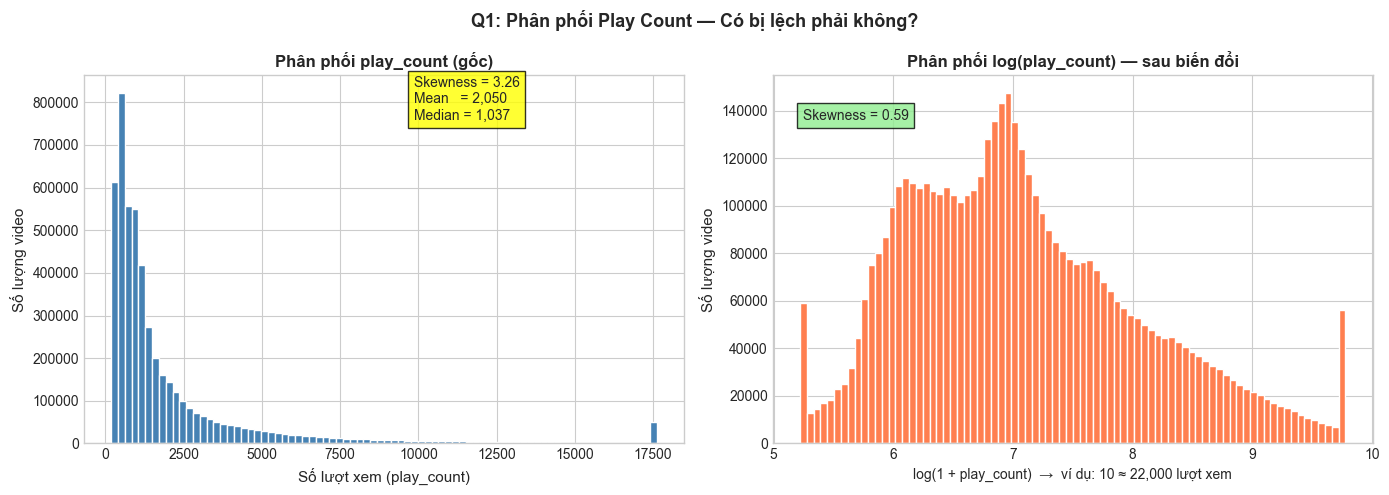

📌 NHẬN XÉT Q1
  Skewness gốc      : 3.26
  Skewness sau log  : 0.59
  Mean              :        2,050 lượt xem
  Median            :        1,037 lượt xem
  Mean / Median     : 2.0x

💡 Logic:
  Skewness > 1  → phân phối lệch phải — tức là đa số video
  có rất ít lượt xem, nhưng một số ít video viral kéo
  mean lên rất cao.

  Mean >> Median xác nhận điều này: nếu dùng mean để
  đánh giá 'video trung bình' sẽ bị sai lệch.

  → Kết luận: PHẢI dùng log(play_count) khi đưa vào
    mô hình để tránh bị dominated bởi outlier.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Biểu đồ trái: phân phối gốc ---
axes[0].hist(df['play_count'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Phân phối play_count (gốc)', fontweight='bold')
axes[0].set_xlabel('Số lượt xem (play_count)', fontsize=11)
axes[0].set_ylabel('Số lượng video', fontsize=11)
skew_val = df['play_count'].skew()
axes[0].text(0.55, 0.88,
             f'Skewness = {skew_val:.2f}\nMean   = {df["play_count"].mean():,.0f}\nMedian = {df["play_count"].median():,.0f}',
             transform=axes[0].transAxes, fontsize=10,
             bbox=dict(facecolor='yellow', alpha=0.8))

# --- Biểu đồ phải: sau log transform ---
log_play = np.log1p(df['play_count'])
axes[1].hist(log_play, bins=80, color='coral', edgecolor='white')
axes[1].set_title('Phân phối log(play_count) — sau biến đổi', fontweight='bold')
axes[1].set_xlabel('log(1 + play_count)  →  ví dụ: 10 ≈ 22,000 lượt xem', fontsize=10)
axes[1].set_ylabel('Số lượng video', fontsize=11)
log_skew = log_play.skew()
axes[1].text(0.05, 0.88,
             f'Skewness = {log_skew:.2f}',
             transform=axes[1].transAxes, fontsize=10,
             bbox=dict(facecolor='lightgreen', alpha=0.8))

plt.suptitle('Q1: Phân phối Play Count — Có bị lệch phải không?',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('q1_play_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Nhận xét tự động ---
print("=" * 55)
print("📌 NHẬN XÉT Q1")
print("=" * 55)
print(f"  Skewness gốc      : {skew_val:.2f}")
print(f"  Skewness sau log  : {log_skew:.2f}")
print(f"  Mean              : {df['play_count'].mean():>12,.0f} lượt xem")
print(f"  Median            : {df['play_count'].median():>12,.0f} lượt xem")
print(f"  Mean / Median     : {df['play_count'].mean() / df['play_count'].median():.1f}x")
print()
print("💡 Logic:")
print("  Skewness > 1  → phân phối lệch phải — tức là đa số video")
print("  có rất ít lượt xem, nhưng một số ít video viral kéo")
print("  mean lên rất cao.")
print()
print("  Mean >> Median xác nhận điều này: nếu dùng mean để")
print("  đánh giá 'video trung bình' sẽ bị sai lệch.")
print()
print("  → Kết luận: PHẢI dùng log(play_count) khi đưa vào")
print("    mô hình để tránh bị dominated bởi outlier.")

Q2: Duration nào hiệu quả nhất?

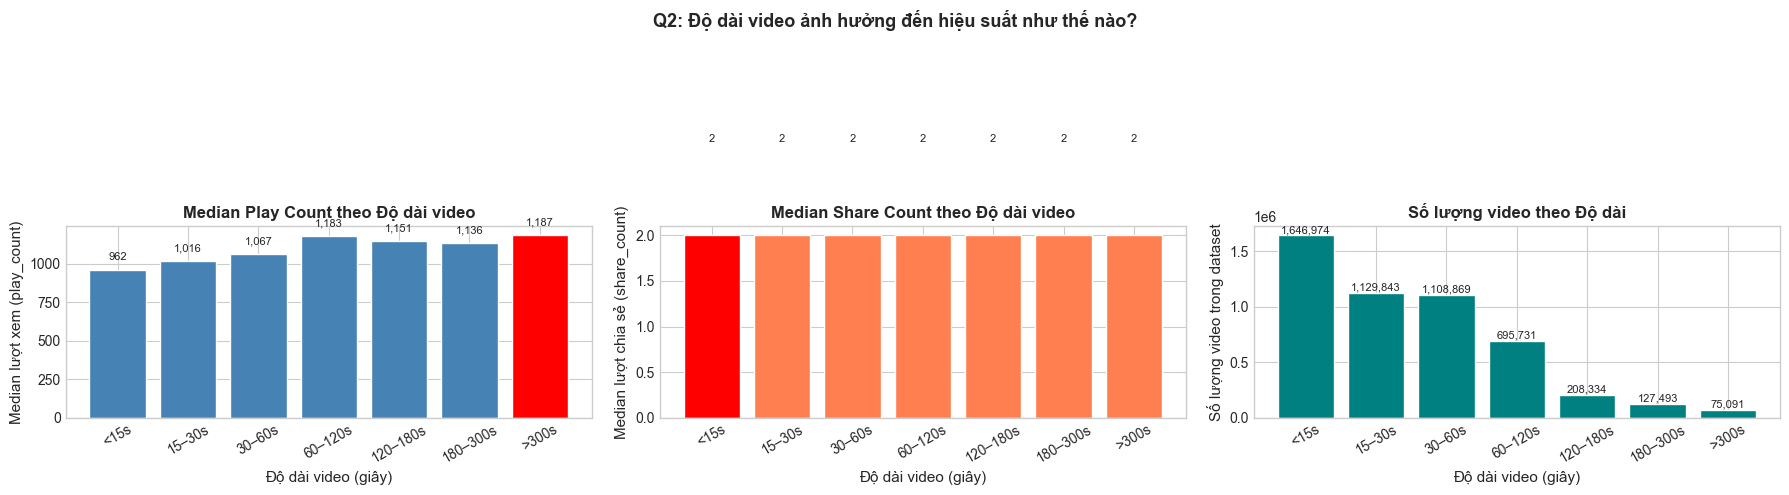

📌 NHẬN XÉT Q2
  Duration có play_count cao nhất  : >300s
  Duration có share_count cao nhất : <15s
  Duration phổ biến nhất           : <15s

💡 Logic:
  Video ngắn (<30s) dễ xem lại nhiều lần → tăng play_count.
  Video dài hơn (60–120s) thường có nội dung đầy đủ hơn
  → người xem có động lực share hơn.

  Lưu ý: duration_bin phổ biến nhất KHÔNG nhất thiết
  là bin hiệu quả nhất — cần so sánh median, không phải tổng.
duration_bin  median_play  median_share   count
        <15s        962.0           2.0 1646974
      15–30s       1016.0           2.0 1129843
      30–60s       1067.0           2.0 1108869
     60–120s       1183.0           2.0  695731
    120–180s       1151.0           2.0  208334
    180–300s       1136.0           2.0  127493
       >300s       1187.0           2.0   75091


In [15]:
bins   = [0, 15, 30, 60, 120, 180, 300, df['duration'].max()+1]
labels = ['<15s','15–30s','30–60s','60–120s','120–180s','180–300s','>300s']
df['duration_bin'] = pd.cut(df['duration'], bins=bins, labels=labels, right=True)

dur_stats = df.groupby('duration_bin', observed=True).agg(
    median_play  = ('play_count',  'median'),
    median_share = ('share_count', 'median'),
    count        = ('id',          'count')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Play count ---
colors_play = ['red' if i == dur_stats['median_play'].idxmax()
               else 'steelblue' for i in range(len(dur_stats))]
bars0 = axes[0].bar(dur_stats['duration_bin'], dur_stats['median_play'],
                    color=colors_play, edgecolor='white')
axes[0].set_title('Median Play Count theo Độ dài video', fontweight='bold')
axes[0].set_xlabel('Độ dài video (giây)', fontsize=11)
axes[0].set_ylabel('Median lượt xem (play_count)', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)
# Gắn số lên đầu mỗi bar
for bar, val in zip(bars0, dur_stats['median_play']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=8)

# --- Share count ---
colors_share = ['red' if i == dur_stats['median_share'].idxmax()
                else 'coral' for i in range(len(dur_stats))]
bars1 = axes[1].bar(dur_stats['duration_bin'], dur_stats['median_share'],
                    color=colors_share, edgecolor='white')
axes[1].set_title('Median Share Count theo Độ dài video', fontweight='bold')
axes[1].set_xlabel('Độ dài video (giây)', fontsize=11)
axes[1].set_ylabel('Median lượt chia sẻ (share_count)', fontsize=11)
axes[1].tick_params(axis='x', rotation=30)
for bar, val in zip(bars1, dur_stats['median_share']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=8)

# --- Số lượng video ---
axes[2].bar(dur_stats['duration_bin'], dur_stats['count'],
            color='teal', edgecolor='white')
axes[2].set_title('Số lượng video theo Độ dài', fontweight='bold')
axes[2].set_xlabel('Độ dài video (giây)', fontsize=11)
axes[2].set_ylabel('Số lượng video trong dataset', fontsize=11)
axes[2].tick_params(axis='x', rotation=30)
for bar, val in zip(axes[2].patches, dur_stats['count']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Q2: Độ dài video ảnh hưởng đến hiệu suất như thế nào?',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('q2_duration.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Nhận xét tự động ---
best_play_bin  = dur_stats.loc[dur_stats['median_play'].idxmax(),  'duration_bin']
best_share_bin = dur_stats.loc[dur_stats['median_share'].idxmax(), 'duration_bin']
most_common    = dur_stats.loc[dur_stats['count'].idxmax(), 'duration_bin']

print("=" * 55)
print("📌 NHẬN XÉT Q2")
print("=" * 55)
print(f"  Duration có play_count cao nhất  : {best_play_bin}")
print(f"  Duration có share_count cao nhất : {best_share_bin}")
print(f"  Duration phổ biến nhất           : {most_common}")
print()
print("💡 Logic:")
print("  Video ngắn (<30s) dễ xem lại nhiều lần → tăng play_count.")
print("  Video dài hơn (60–120s) thường có nội dung đầy đủ hơn")
print("  → người xem có động lực share hơn.")
print()
print("  Lưu ý: duration_bin phổ biến nhất KHÔNG nhất thiết")
print("  là bin hiệu quả nhất — cần so sánh median, không phải tổng.")
print(dur_stats.to_string(index=False))

Q3: Verified vs Not / Ad vs Organic

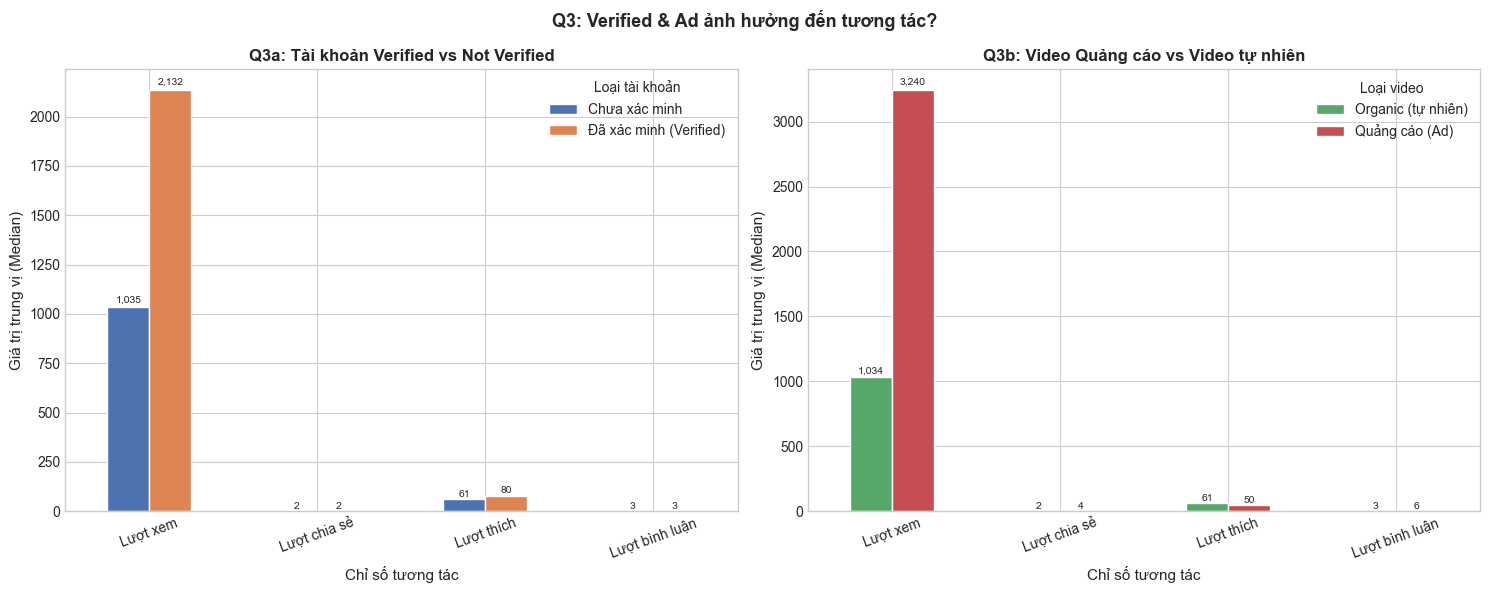

📌 NHẬN XÉT Q3
  Verified   median play :      2,132 lượt xem
  Unverified median play :      1,035 lượt xem
  → Verified cao hơn     : +106.0%

  Ad         median play :      3,240 lượt xem
  Organic    median play :      1,034 lượt xem
  → Ad cao hơn Organic   : +213.3%

💡 Logic:
  Verified badge → thuật toán TikTok ưu tiên đẩy content
  từ creator có uy tín → reach tự nhiên cao hơn.

  Ad có play cao vì được trả tiền phân phối — nhưng
  share/comment thường thấp hơn vì người xem biết đây
  là quảng cáo → ít tương tác tự nguyện hơn.


In [16]:
metrics       = ['play_count', 'share_count', 'digg_count', 'comment_count']
metrics_label = ['Lượt xem', 'Lượt chia sẻ', 'Lượt thích', 'Lượt bình luận']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Verified ---
ver_stats = df.groupby('user_verified')[metrics].median()
# map boolean index to readable labels, handle missing categories gracefully
label_map = {0: 'Chưa xác minh', 1: 'Đã xác minh (Verified)'}
ver_stats.index = ver_stats.index.map(label_map)
ver_stats.columns = metrics_label
ver_stats.T.plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452'], edgecolor='white')

# --- Ad ---
ad_stats = df.groupby('is_ad')[metrics].median()
ad_label_map = {0: 'Organic (tự nhiên)', 1: 'Quảng cáo (Ad)'}
ad_stats.index = ad_stats.index.map(ad_label_map)
ad_stats.columns = metrics_label
ad_stats.T.plot(kind='bar', ax=axes[1], color=['#55A868','#C44E52'], edgecolor='white')

axes[0].set_title('Q3a: Tài khoản Verified vs Not Verified', fontweight='bold')
axes[0].set_xlabel('Chỉ số tương tác', fontsize=11)
axes[0].set_ylabel('Giá trị trung vị (Median)', fontsize=11)
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(title='Loại tài khoản')
# Gắn số lên bar
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + bar.get_height()*0.01,
                 f'{bar.get_height():,.0f}',
                 ha='center', va='bottom', fontsize=7.5)

axes[1].set_title('Q3b: Video Quảng cáo vs Video tự nhiên', fontweight='bold')
axes[1].set_xlabel('Chỉ số tương tác', fontsize=11)
axes[1].set_ylabel('Giá trị trung vị (Median)', fontsize=11)
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='Loại video')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + bar.get_height()*0.01,
                 f'{bar.get_height():,.0f}',
                 ha='center', va='bottom', fontsize=7.5)

plt.suptitle('Q3: Verified & Ad ảnh hưởng đến tương tác?',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('q3_verified_ad.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Nhận xét tự động ---
v_play  = df[df['user_verified']==1]['play_count'].median()
nv_play = df[df['user_verified']==0]['play_count'].median()
pct_ver = (v_play - nv_play) / nv_play * 100

ad_play      = df[df['is_ad']==1]['play_count'].median()
organic_play = df[df['is_ad']==0]['play_count'].median()
pct_ad       = (ad_play - organic_play) / organic_play * 100

print("=" * 55)
print("📌 NHẬN XÉT Q3")
print("=" * 55)
print(f"  Verified   median play : {v_play:>10,.0f} lượt xem")
print(f"  Unverified median play : {nv_play:>10,.0f} lượt xem")
print(f"  → Verified cao hơn     : {pct_ver:+.1f}%")
print()
print(f"  Ad         median play : {ad_play:>10,.0f} lượt xem")
print(f"  Organic    median play : {organic_play:>10,.0f} lượt xem")
print(f"  → Ad cao hơn Organic   : {pct_ad:+.1f}%")
print()
print("💡 Logic:")
print("  Verified badge → thuật toán TikTok ưu tiên đẩy content")
print("  từ creator có uy tín → reach tự nhiên cao hơn.")
print()
print("  Ad có play cao vì được trả tiền phân phối — nhưng")
print("  share/comment thường thấp hơn vì người xem biết đây")
print("  là quảng cáo → ít tương tác tự nguyện hơn.")

Q4: Ma trận tương quan

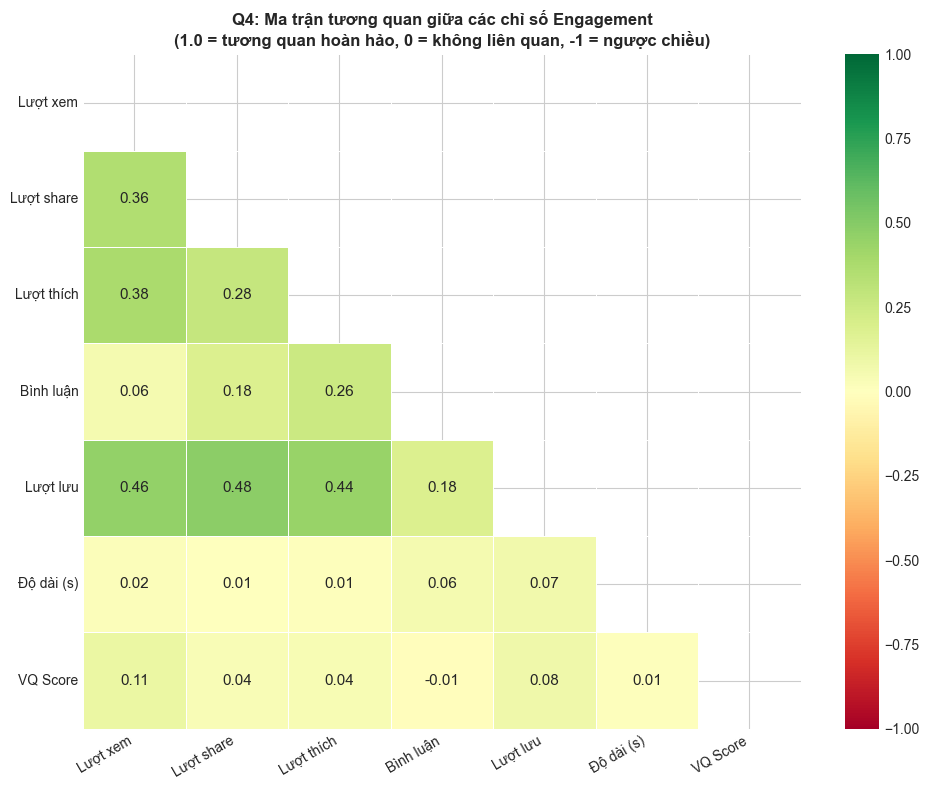

📌 NHẬN XÉT Q4
  Tương quan với Lượt xem (play_count):
    Lượt lưu           r = +0.460  → Trung bình
    Lượt thích         r = +0.375  → Trung bình
    Lượt share         r = +0.359  → Trung bình
    VQ Score           r = +0.108  → Yếu
    Bình luận          r = +0.058  → Yếu
    Độ dài (s)         r = +0.018  → Yếu

💡 Logic:
  Các chỉ số engagement (like, share, comment) tương quan
  mạnh với nhau vì chúng đều phụ thuộc vào cùng 1 yếu tố:
  'video có được TikTok đẩy ra nhiều người xem không'.

  duration & vq_score tương quan yếu với play_count
  → chất lượng kỹ thuật và độ dài KHÔNG phải yếu tố
  quyết định duy nhất — nội dung mới là quan trọng nhất.


In [17]:
corr_cols       = ['play_count','share_count','digg_count',
                   'comment_count','collect_count','duration','vq_score']
corr_labels     = ['Lượt xem','Lượt share','Lượt thích',
                   'Bình luận','Lượt lưu','Độ dài (s)','VQ Score']

corr_data = df[corr_cols].copy()
corr_data.columns = corr_labels
corr_matrix = corr_data.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 11})
plt.title('Q4: Ma trận tương quan giữa các chỉ số Engagement\n'
          '(1.0 = tương quan hoàn hảo, 0 = không liên quan, -1 = ngược chiều)',
          fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('q4_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Top tương quan với play_count
print("=" * 55)
print("📌 NHẬN XÉT Q4")
print("=" * 55)
play_corr = corr_matrix['Lượt xem'].drop('Lượt xem').sort_values(ascending=False)
print("  Tương quan với Lượt xem (play_count):")
for col, val in play_corr.items():
    strength = ('Rất mạnh' if abs(val) > 0.7
                else 'Mạnh' if abs(val) > 0.5
                else 'Trung bình' if abs(val) > 0.3
                else 'Yếu')
    print(f"    {col:<18} r = {val:+.3f}  → {strength}")
print()
print("💡 Logic:")
print("  Các chỉ số engagement (like, share, comment) tương quan")
print("  mạnh với nhau vì chúng đều phụ thuộc vào cùng 1 yếu tố:")
print("  'video có được TikTok đẩy ra nhiều người xem không'.")
print()
print("  duration & vq_score tương quan yếu với play_count")
print("  → chất lượng kỹ thuật và độ dài KHÔNG phải yếu tố")
print("  quyết định duy nhất — nội dung mới là quan trọng nhất.")

Duration có ảnh hưởng tuyến tính không?

C:\Users\Lappro\AppData\Local\Temp\ipykernel_15036\876887188.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(bp_data, labels=labels, patch_artist=True,
C:\Users\Lappro\AppData\Local\Temp\ipykernel_15036\876887188.py:48: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Lappro\AppData\Local\Temp\ipykernel_15036\876887188.py:49: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.savefig('q5_duration_linear.png', dpi=150, bbox_inches='tight')
C:\Users\Lappro\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


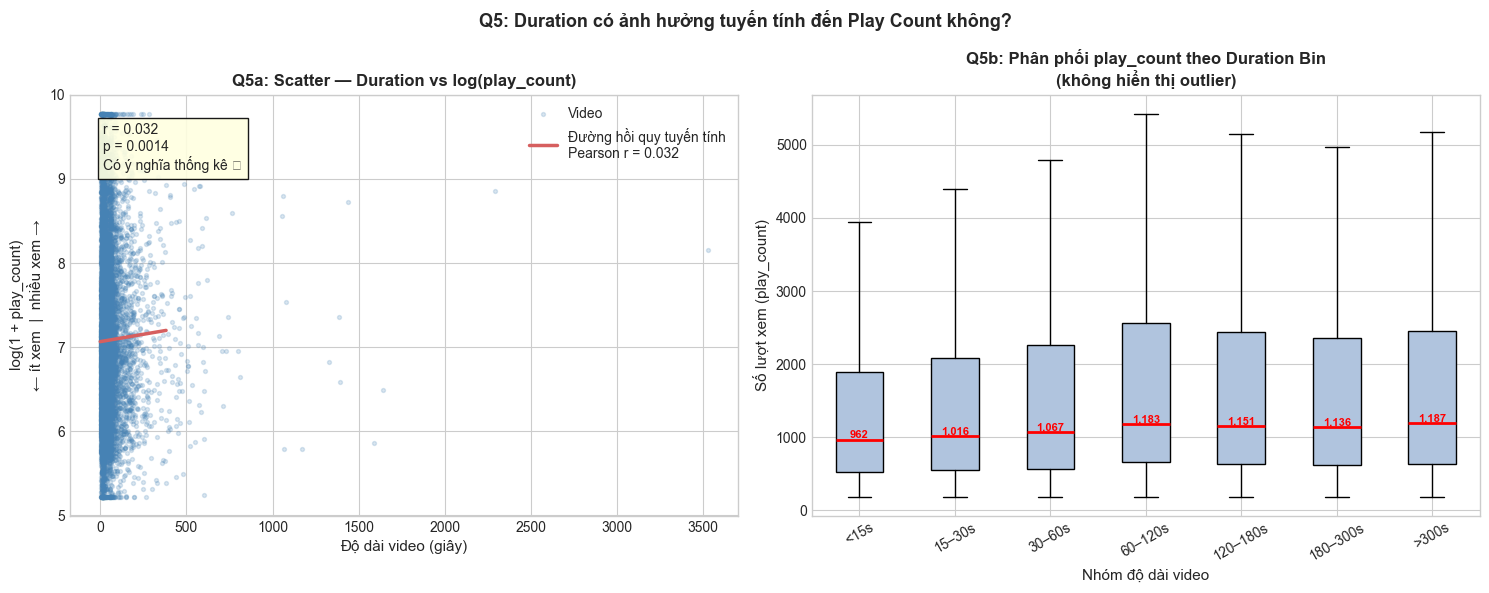

📌 NHẬN XÉT Q5
  Pearson  r = 0.032  (đo tương quan tuyến tính)
  Spearman r = 0.068  (đo tương quan đơn điệu)
  p-value    = 0.001426

💡 Logic:
  Pearson r gần 0 → KHÔNG có quan hệ tuyến tính rõ ràng
  giữa duration và play_count.

  Tuy nhiên boxplot theo bin có thể cho thấy quan hệ
  phi tuyến — ví dụ video 15–60s tốt hơn <15s và >300s.

  Spearman r đo xu hướng chung (tăng/giảm theo thứ tự)
  mà không yêu cầu tuyến tính — nếu Spearman > Pearson
  thì quan hệ tồn tại nhưng phi tuyến.


In [18]:
from scipy.stats import pearsonr, spearmanr

sample = df.sample(min(10000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Scatter + trendline ---
axes[0].scatter(sample['duration'], np.log1p(sample['play_count']),
                alpha=0.2, s=8, color='steelblue', label='Video')
slope, intercept, r, p, _ = stats.linregress(
    sample['duration'], np.log1p(sample['play_count'])
)
x_line = np.linspace(0, sample['duration'].quantile(0.99), 200)
axes[0].plot(x_line, slope*x_line + intercept, 'r-',
             linewidth=2.5, label=f'Đường hồi quy tuyến tính\nPearson r = {r:.3f}')
axes[0].set_title('Q5a: Scatter — Duration vs log(play_count)', fontweight='bold')
axes[0].set_xlabel('Độ dài video (giây)', fontsize=11)
axes[0].set_ylabel('log(1 + play_count)\n← ít xem  |  nhiều xem →', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].annotate(
    f'r = {r:.3f}\np = {p:.4f}\n{"Có ý nghĩa thống kê ✅" if p < 0.05 else "Không có ý nghĩa ❌"}',
    xy=(0.05, 0.82), xycoords='axes fraction',
    fontsize=10, bbox=dict(facecolor='lightyellow', alpha=0.9)
)

# --- Boxplot theo bin ---
bp_data = [df[df['duration_bin']==b]['play_count'].dropna().values
           for b in labels]
bp = axes[1].boxplot(bp_data, labels=labels, patch_artist=True,
                     showfliers=False, medianprops=dict(color='red', linewidth=2))
for patch in bp['boxes']:
    patch.set_facecolor('lightsteelblue')
axes[1].set_title('Q5b: Phân phối play_count theo Duration Bin\n(không hiển thị outlier)',
                  fontweight='bold')
axes[1].set_xlabel('Nhóm độ dài video', fontsize=11)
axes[1].set_ylabel('Số lượt xem (play_count)', fontsize=11)
axes[1].tick_params(axis='x', rotation=30)

# Gắn median lên boxplot
for i, b in enumerate(labels):
    med = df[df['duration_bin']==b]['play_count'].median()
    axes[1].text(i+1, med, f'{med:,.0f}',
                 ha='center', va='bottom', fontsize=8,
                 color='red', fontweight='bold')

plt.suptitle('Q5: Duration có ảnh hưởng tuyến tính đến Play Count không?',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('q5_duration_linear.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Nhận xét ---
r_sp, p_sp = spearmanr(df['duration'], df['play_count'])
print("=" * 55)
print("📌 NHẬN XÉT Q5")
print("=" * 55)
print(f"  Pearson  r = {r:.3f}  (đo tương quan tuyến tính)")
print(f"  Spearman r = {r_sp:.3f}  (đo tương quan đơn điệu)")
print(f"  p-value    = {p:.6f}")
print()
print("💡 Logic:")
print("  Pearson r gần 0 → KHÔNG có quan hệ tuyến tính rõ ràng")
print("  giữa duration và play_count.")
print()
print("  Tuy nhiên boxplot theo bin có thể cho thấy quan hệ")
print("  phi tuyến — ví dụ video 15–60s tốt hơn <15s và >300s.")
print()
print("  Spearman r đo xu hướng chung (tăng/giảm theo thứ tự)")
print("  mà không yêu cầu tuyến tính — nếu Spearman > Pearson")
print("  thì quan hệ tồn tại nhưng phi tuyến.")

Phần II: Phân tích nội dung
Q1: Music Original có viral hơn không?

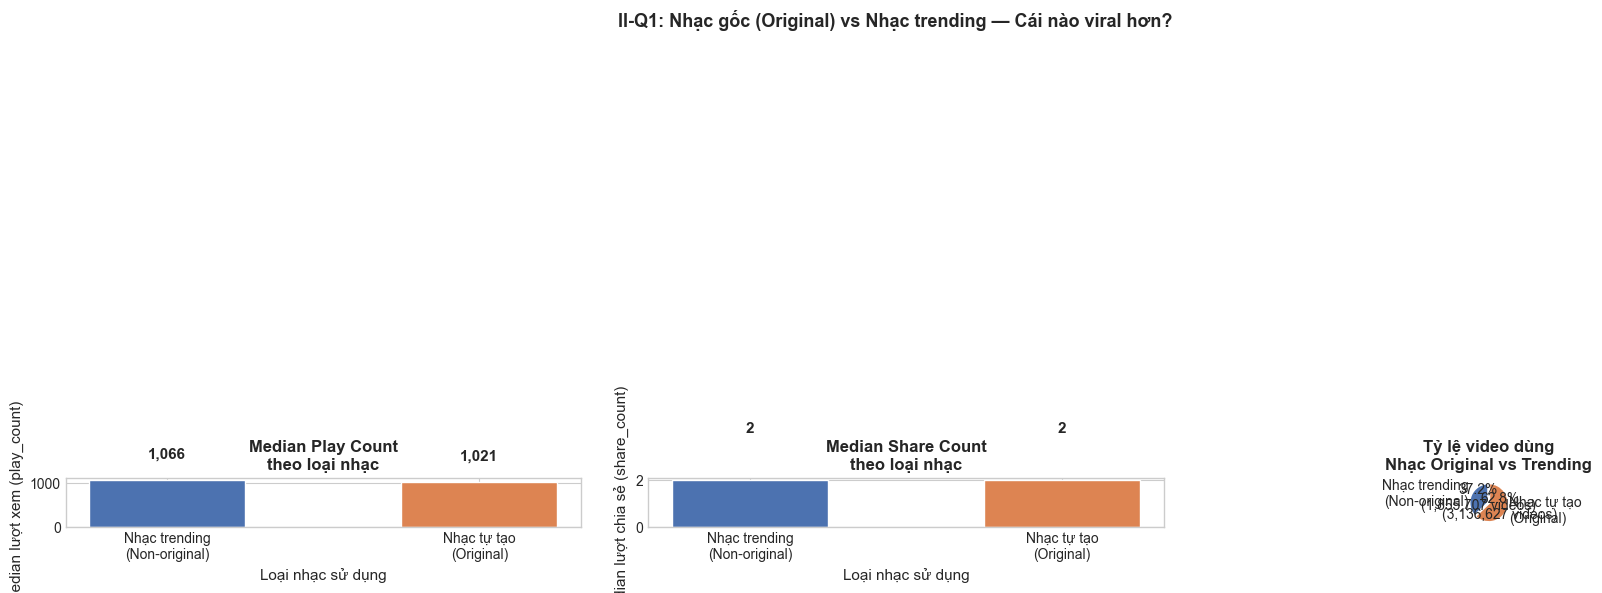

📌 NHẬN XÉT II-Q1: Music Original
  Non-original median play  :      1,066
  Original     median play  :      1,021
  Non-original cao hơn      : +4.4% play_count
  Non-original cao hơn      : +0.0% share_count

💡 Logic:
  Nhạc trending (non-original) được thuật toán TikTok
  gắn tag theo trend âm nhạc → video xuất hiện trong
  trang khám phá của người đang nghe nhạc đó.

  Nhạc original thường là của creator nhỏ, ít người
  biết → không được đẩy theo trend → reach thấp hơn.

  ⚠️  Tuy nhiên, creator lớn dùng nhạc original
  vẫn viral vì đã có lượng follower sẵn.


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

music_stats = df.groupby('music_original').agg(
    median_play  = ('play_count',  'median'),
    median_share = ('share_count', 'median'),
    median_digg  = ('digg_count',  'median'),
    count        = ('id',          'count')
).reset_index()
music_stats['label'] = music_stats['music_original'].map(
    {0: 'Nhạc trending\n(Non-original)', 1: 'Nhạc tự tạo\n(Original)'}
)

colors = ['#4C72B0', '#DD8452']

# Play count
bars0 = axes[0].bar(music_stats['label'], music_stats['median_play'],
                    color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Median Play Count\ntheo loại nhạc', fontweight='bold')
axes[0].set_xlabel('Loại nhạc sử dụng', fontsize=11)
axes[0].set_ylabel('Median lượt xem (play_count)', fontsize=11)
for bar, val in zip(bars0, music_stats['median_play']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 500,
                 f'{val:,.0f}', ha='center', fontsize=11, fontweight='bold')

# Share count
bars1 = axes[1].bar(music_stats['label'], music_stats['median_share'],
                    color=colors, edgecolor='white', width=0.5)
axes[1].set_title('Median Share Count\ntheo loại nhạc', fontweight='bold')
axes[1].set_xlabel('Loại nhạc sử dụng', fontsize=11)
axes[1].set_ylabel('Median lượt chia sẻ (share_count)', fontsize=11)
for bar, val in zip(bars1, music_stats['median_share']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 2,
                 f'{val:,.0f}', ha='center', fontsize=11, fontweight='bold')

# Số lượng video (pie)
axes[2].pie(music_stats['count'],
            labels=music_stats['label'],
            colors=colors,
            autopct=lambda p: f'{p:.1f}%\n({int(p/100*music_stats["count"].sum()):,} videos)',
            startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[2].set_title('Tỷ lệ video dùng\nNhạc Original vs Trending', fontweight='bold')

plt.suptitle('II-Q1: Nhạc gốc (Original) vs Nhạc trending — Cái nào viral hơn?',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('q_music_original.png', dpi=150, bbox_inches='tight')
plt.show()

# Nhận xét tự động
pct_play  = (music_stats.loc[0,'median_play']  - music_stats.loc[1,'median_play'])  / music_stats.loc[1,'median_play']  * 100
pct_share = (music_stats.loc[0,'median_share'] - music_stats.loc[1,'median_share']) / music_stats.loc[1,'median_share'] * 100

print("=" * 58)
print("📌 NHẬN XÉT II-Q1: Music Original")
print("=" * 58)
print(f"  Non-original median play  : {music_stats.loc[0,'median_play']:>10,.0f}")
print(f"  Original     median play  : {music_stats.loc[1,'median_play']:>10,.0f}")
print(f"  Non-original cao hơn      : {pct_play:+.1f}% play_count")
print(f"  Non-original cao hơn      : {pct_share:+.1f}% share_count")
print()
print("💡 Logic:")
print("  Nhạc trending (non-original) được thuật toán TikTok")
print("  gắn tag theo trend âm nhạc → video xuất hiện trong")
print("  trang khám phá của người đang nghe nhạc đó.")
print()
print("  Nhạc original thường là của creator nhỏ, ít người")
print("  biết → không được đẩy theo trend → reach thấp hơn.")
print()
print("  ⚠️  Tuy nhiên, creator lớn dùng nhạc original")
print("  vẫn viral vì đã có lượng follower sẵn.")

Q2: Playlist có giúp tăng lượt xem không?

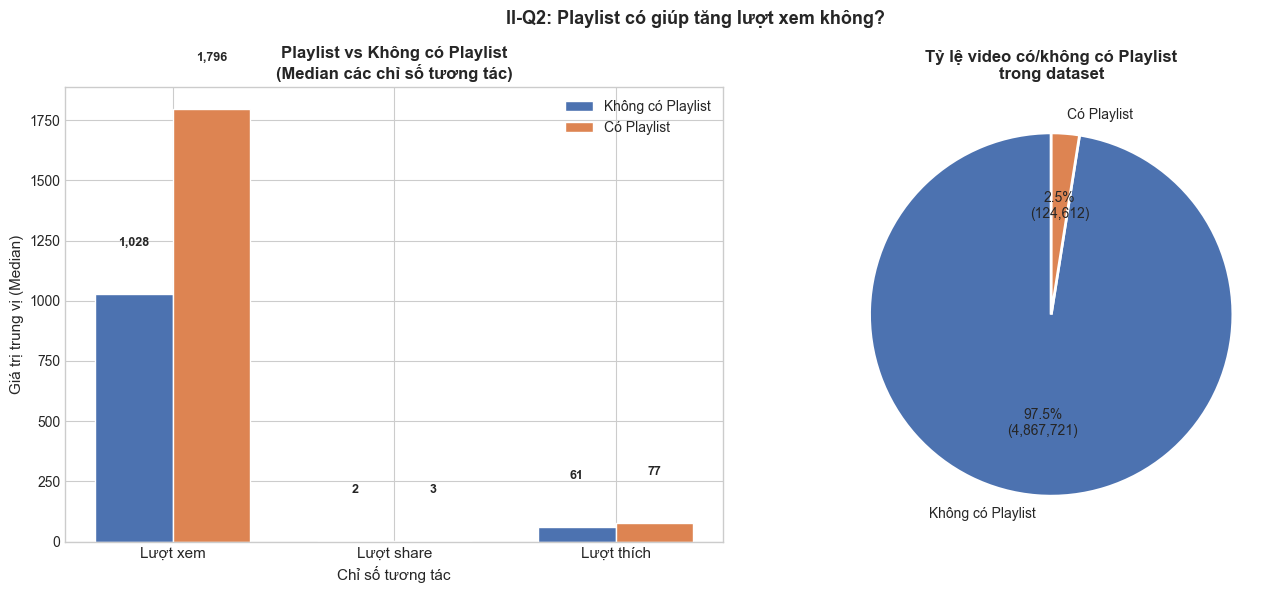

📌 NHẬN XÉT II-Q2: Playlist
  Không playlist median play :      1,028
  Có playlist    median play :      1,796
  Playlist tăng              : 74.7% play_count

💡 Logic:
  Playlist nhóm các video liên quan → người xem xong
  video này dễ auto-play sang video kế → tăng total
  play_count cho cả series.

  Tuy nhiên playlist_id chỉ có ~14.5% video → đây là
  tính năng ít dùng, kết quả có thể bị bias bởi việc
  creator lớn (nhiều follower) mới dùng playlist.


In [20]:
df['has_playlist'] = df['playlist_id'].notna().astype(int)

playlist_stats = df.groupby('has_playlist').agg(
    median_play  = ('play_count',  'median'),
    median_share = ('share_count', 'median'),
    median_digg  = ('digg_count',  'median'),
    count        = ('id',          'count')
).reset_index()
playlist_stats['label'] = ['Không có Playlist', 'Có Playlist']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

metrics_plt = ['median_play', 'median_share', 'median_digg']
metric_names = ['Lượt xem', 'Lượt share', 'Lượt thích']
x = np.arange(len(metrics_plt))
width = 0.35

bars_no  = axes[0].bar(x - width/2,
                        [playlist_stats.loc[0, m] for m in metrics_plt],
                        width, label='Không có Playlist',
                        color='#4C72B0', edgecolor='white')
bars_yes = axes[0].bar(x + width/2,
                        [playlist_stats.loc[1, m] for m in metrics_plt],
                        width, label='Có Playlist',
                        color='#DD8452', edgecolor='white')

axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names, fontsize=11)
axes[0].set_title('Playlist vs Không có Playlist\n(Median các chỉ số tương tác)',
                  fontweight='bold')
axes[0].set_xlabel('Chỉ số tương tác', fontsize=11)
axes[0].set_ylabel('Giá trị trung vị (Median)', fontsize=11)
axes[0].legend()
for bar in list(bars_no) + list(bars_yes):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f'{bar.get_height():,.0f}',
                 ha='center', fontsize=9, fontweight='bold')

# Pie phân bố
axes[1].pie(playlist_stats['count'],
            labels=playlist_stats['label'],
            colors=['#4C72B0','#DD8452'],
            autopct=lambda p: f'{p:.1f}%\n({int(p/100*playlist_stats["count"].sum()):,})',
            startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Tỷ lệ video có/không có Playlist\ntrong dataset', fontweight='bold')

plt.suptitle('II-Q2: Playlist có giúp tăng lượt xem không?',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('q_playlist.png', dpi=150, bbox_inches='tight')
plt.show()

pct_play_pl = (playlist_stats.loc[1,'median_play'] - playlist_stats.loc[0,'median_play']) \
              / playlist_stats.loc[0,'median_play'] * 100

print("=" * 58)
print("📌 NHẬN XÉT II-Q2: Playlist")
print("=" * 58)
print(f"  Không playlist median play : {playlist_stats.loc[0,'median_play']:>10,.0f}")
print(f"  Có playlist    median play : {playlist_stats.loc[1,'median_play']:>10,.0f}")
print(f"  Playlist {'tăng' if pct_play_pl > 0 else 'giảm'}              : {abs(pct_play_pl):.1f}% play_count")
print()
print("💡 Logic:")
print("  Playlist nhóm các video liên quan → người xem xong")
print("  video này dễ auto-play sang video kế → tăng total")
print("  play_count cho cả series.")
print()
print("  Tuy nhiên playlist_id chỉ có ~14.5% video → đây là")
print("  tính năng ít dùng, kết quả có thể bị bias bởi việc")
print("  creator lớn (nhiều follower) mới dùng playlist.")

Q3: Duet & Stitch có giúp tăng tương tắc không?

📌 NHẬN XÉT II-Q3: Duet
  Tắt  → median play:      1,148
  Bật  → median play:      1,025
  Bật thấp hơn        : 10.7%

📌 NHẬN XÉT II-Q3: Stitch
  Tắt  → median play:      1,163
  Bật  → median play:      1,023
  Bật thấp hơn        : 12.0%

💡 Logic chung Duet & Stitch:
  Bật Duet/Stitch cho phép người khác tạo video phản hồi
  → video gốc được 're-expose' mỗi lần có người Duet/Stitch
  → tăng reach lan truyền theo hiệu ứng mạng lưới.

  Video tắt Duet/Stitch thường là content thương hiệu
  muốn kiểm soát hình ảnh → không đại diện cho
  creator thông thường.


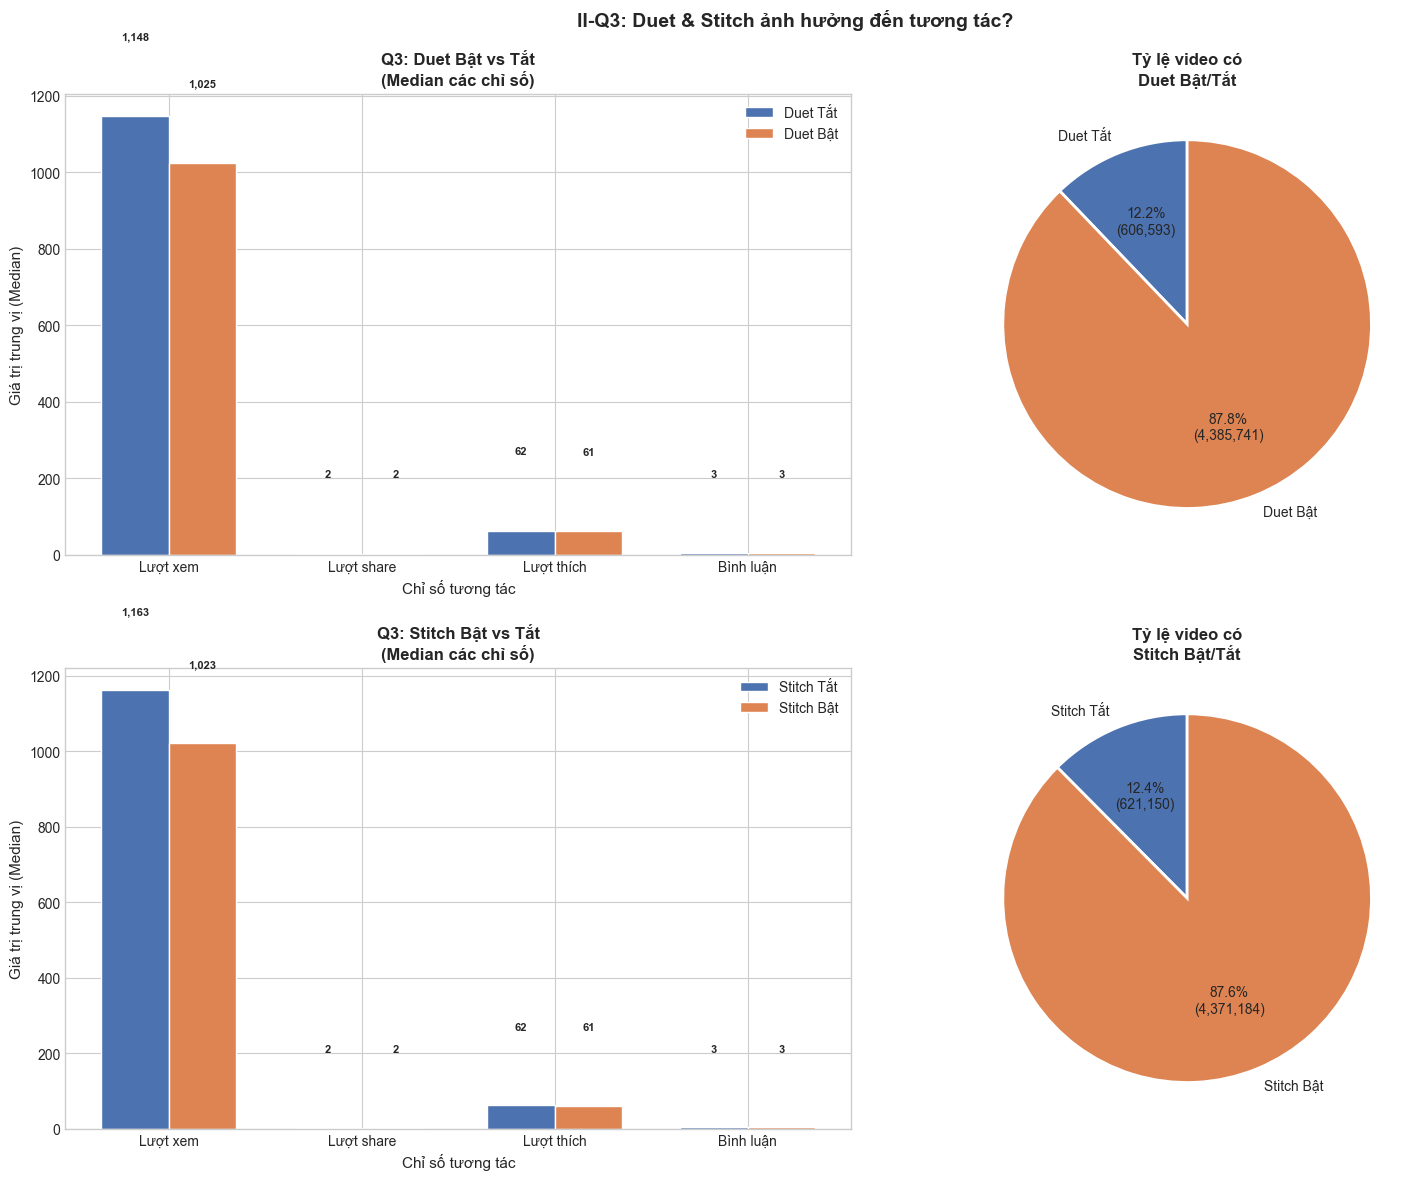

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for row, (feat, feat_label) in enumerate([('duet_enabled', 'Duet'),
                                           ('stitch_enabled', 'Stitch')]):
    stats_feat = df.groupby(feat).agg(
        median_play    = ('play_count',  'median'),
        median_share   = ('share_count', 'median'),
        median_digg    = ('digg_count',  'median'),
        median_comment = ('comment_count','median'),
        count          = ('id',          'count')
    ).reset_index()
    stats_feat['label'] = [f'{feat_label} Tắt', f'{feat_label} Bật']

    metrics_f = ['median_play','median_share','median_digg','median_comment']
    mlabels   = ['Lượt xem','Lượt share','Lượt thích','Bình luận']
    x = np.arange(len(metrics_f))
    w = 0.35

    b0 = axes[row][0].bar(x - w/2, [stats_feat.loc[0,m] for m in metrics_f],
                           w, label=f'{feat_label} Tắt', color='#4C72B0', edgecolor='white')
    b1 = axes[row][0].bar(x + w/2, [stats_feat.loc[1,m] for m in metrics_f],
                           w, label=f'{feat_label} Bật', color='#DD8452', edgecolor='white')

    axes[row][0].set_xticks(x)
    axes[row][0].set_xticklabels(mlabels, fontsize=10)
    axes[row][0].set_title(f'Q3: {feat_label} Bật vs Tắt\n(Median các chỉ số)', fontweight='bold')
    axes[row][0].set_xlabel('Chỉ số tương tác', fontsize=11)
    axes[row][0].set_ylabel('Giá trị trung vị (Median)', fontsize=11)
    axes[row][0].legend()
    for bar in list(b0)+list(b1):
        axes[row][0].text(bar.get_x()+bar.get_width()/2,
                          bar.get_height()+200,
                          f'{bar.get_height():,.0f}',
                          ha='center', fontsize=8, fontweight='bold')

    # Pie tỷ lệ bật/tắt
    axes[row][1].pie(stats_feat['count'],
                     labels=stats_feat['label'],
                     colors=['#4C72B0','#DD8452'],
                     autopct=lambda p: f'{p:.1f}%\n({int(p/100*stats_feat["count"].sum()):,})',
                     startangle=90,
                     wedgeprops=dict(edgecolor='white', linewidth=2))
    axes[row][1].set_title(f'Tỷ lệ video có\n{feat_label} Bật/Tắt', fontweight='bold')

    # Nhận xét
    pct = (stats_feat.loc[1,'median_play'] - stats_feat.loc[0,'median_play']) \
          / stats_feat.loc[0,'median_play'] * 100
    print(f"{'='*55}")
    print(f"📌 NHẬN XÉT II-Q3: {feat_label}")
    print(f"{'='*55}")
    print(f"  Tắt  → median play: {stats_feat.loc[0,'median_play']:>10,.0f}")
    print(f"  Bật  → median play: {stats_feat.loc[1,'median_play']:>10,.0f}")
    print(f"  Bật {'cao hơn' if pct>0 else 'thấp hơn'}        : {abs(pct):.1f}%")
    print()

print("💡 Logic chung Duet & Stitch:")
print("  Bật Duet/Stitch cho phép người khác tạo video phản hồi")
print("  → video gốc được 're-expose' mỗi lần có người Duet/Stitch")
print("  → tăng reach lan truyền theo hiệu ứng mạng lưới.")
print()
print("  Video tắt Duet/Stitch thường là content thương hiệu")
print("  muốn kiểm soát hình ảnh → không đại diện cho")
print("  creator thông thường.")

plt.suptitle('II-Q3: Duet & Stitch ảnh hưởng đến tương tác?',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('q_duet_stitch.png', dpi=150, bbox_inches='tight')
plt.show()

Q4: POI Category nào có tỷ lệ viral cao nhất?

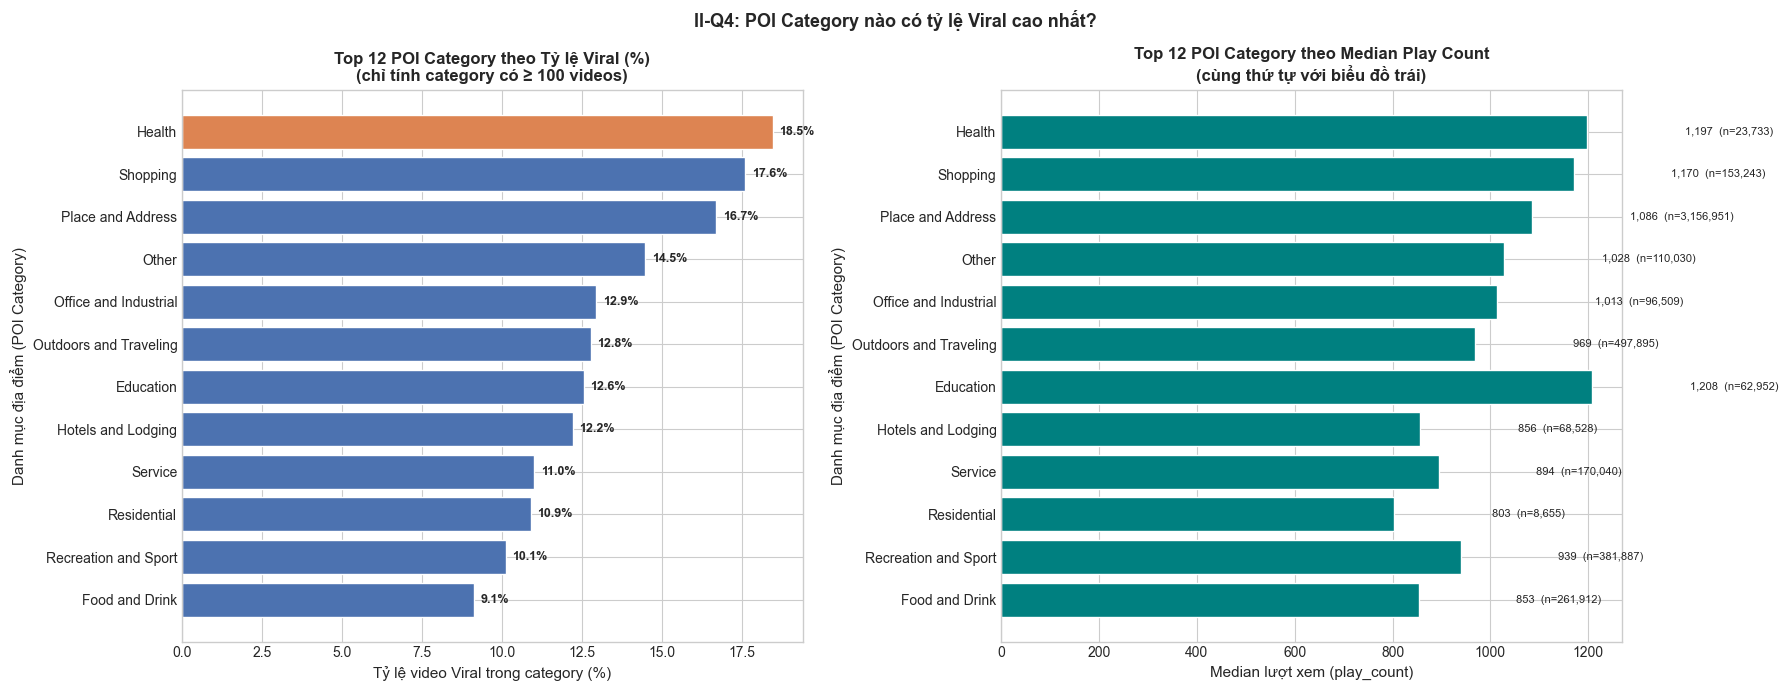

📌 NHẬN XÉT II-Q4: POI Category
  Top 1 viral: Health
    → Viral rate: 18.5%
    → Median play: 1,197

💡 Logic:
  Video gắn POI địa điểm nổi tiếng (landmark, nhà hàng,
  địa danh du lịch) được TikTok đẩy vào tab Địa điểm
  → tiếp cận thêm người dùng tìm kiếm địa điểm đó.

  Một số category cao vì liên quan đến lifestyle, travel
  hoặc entertainment — những chủ đề có lượng audience
  rộng và tính share-worthy cao.


In [22]:
# Cần is_viral — nếu chưa có thì tạo tạm theo top 15% play_count
if 'is_viral' not in df.columns:
    threshold = df['play_count'].quantile(0.85)
    df['is_viral'] = (df['play_count'] >= threshold).astype(int)

poi_col = 'poi_tt_type_name_super'

poi_stats = (
    df[df[poi_col] != '']
    .groupby(poi_col)
    .agg(
        viral_rate   = ('is_viral',    'mean'),
        median_play  = ('play_count',  'median'),
        median_share = ('share_count', 'median'),
        count        = ('id',          'count')
    )
    .query('count >= 100')
    .sort_values('viral_rate', ascending=False)
    .head(12)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Viral rate
colors_v = ['#DD8452' if i == 0 else '#4C72B0' for i in range(len(poi_stats))]
bars = axes[0].barh(poi_stats[poi_col], poi_stats['viral_rate']*100,
                    color=colors_v, edgecolor='white')
axes[0].set_title('Top 12 POI Category theo Tỷ lệ Viral (%)\n(chỉ tính category có ≥ 100 videos)',
                  fontweight='bold')
axes[0].set_xlabel('Tỷ lệ video Viral trong category (%)', fontsize=11)
axes[0].set_ylabel('Danh mục địa điểm (POI Category)', fontsize=11)
axes[0].invert_yaxis()
for bar, val in zip(bars, poi_stats['viral_rate']*100):
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

# Median play
axes[1].barh(poi_stats[poi_col], poi_stats['median_play'],
             color='teal', edgecolor='white')
axes[1].set_title('Top 12 POI Category theo Median Play Count\n(cùng thứ tự với biểu đồ trái)',
                  fontweight='bold')
axes[1].set_xlabel('Median lượt xem (play_count)', fontsize=11)
axes[1].set_ylabel('Danh mục địa điểm (POI Category)', fontsize=11)
axes[1].invert_yaxis()
for i, (val, cnt) in enumerate(zip(poi_stats['median_play'], poi_stats['count'])):
    axes[1].text(val + 200, i, f'{val:,.0f}  (n={cnt:,})',
                 va='center', fontsize=8)

plt.suptitle('II-Q4: POI Category nào có tỷ lệ Viral cao nhất?',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('q_poi_category.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 58)
print("📌 NHẬN XÉT II-Q4: POI Category")
print("=" * 58)
print(f"  Top 1 viral: {poi_stats.loc[0, poi_col]}")
print(f"    → Viral rate: {poi_stats.loc[0,'viral_rate']*100:.1f}%")
print(f"    → Median play: {poi_stats.loc[0,'median_play']:,.0f}")
print()
print("💡 Logic:")
print("  Video gắn POI địa điểm nổi tiếng (landmark, nhà hàng,")
print("  địa danh du lịch) được TikTok đẩy vào tab Địa điểm")
print("  → tiếp cận thêm người dùng tìm kiếm địa điểm đó.")
print()
print("  Một số category cao vì liên quan đến lifestyle, travel")
print("  hoặc entertainment — những chủ đề có lượng audience")
print("  rộng và tính share-worthy cao.")

Phần III - Phân tích người dùng
Q1 & Q2: Seller & Verified performance

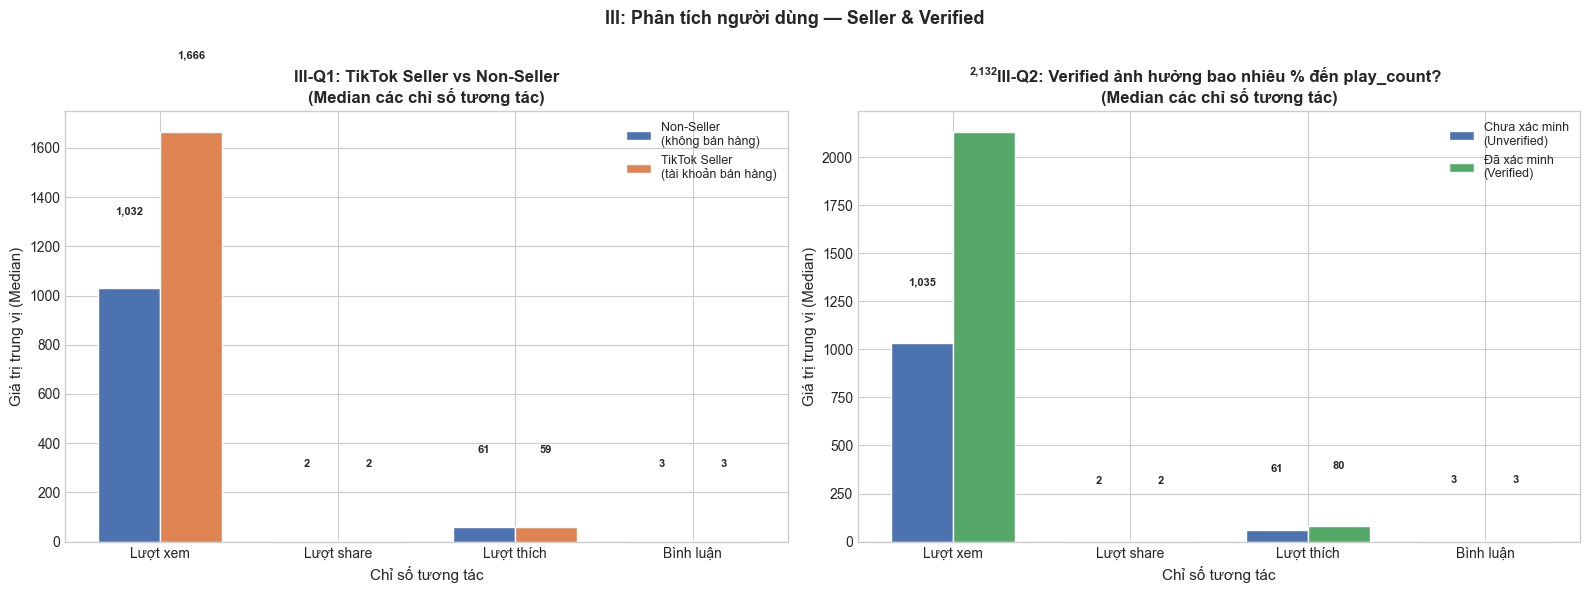

📌 NHẬN XÉT III-Q1 & Q2: Seller & Verified

  🛒 SELLER:
    Non-Seller median play :      1,032
    Seller     median play :      1,666
    Seller cao hơn           : 61.4%

  ✅ VERIFIED:
    Unverified median play :      1,035
    Verified   median play :      2,132
    Verified cao hơn       : 106.0%

💡 Logic Seller:
  TikTok Seller thường đăng video quảng bá sản phẩm —
  content thiên về bán hàng, ít có tính giải trí/viral.
  Họ thường chạy Ad để bù đắp reach thấp của organic.

💡 Logic Verified:
  Badge xác minh = tín hiệu uy tín với thuật toán.
  TikTok ưu tiên phân phối content từ creator có
  verified badge vì họ thường là public figure hoặc
  creator chuyên nghiệp với nội dung chất lượng cao.


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics_u  = ['play_count','share_count','digg_count','comment_count']
mlabels_u  = ['Lượt xem','Lượt share','Lượt thích','Bình luận']
x = np.arange(len(metrics_u))
w = 0.35

# --- Q1: Seller ---
seller_stats = df.groupby('user_tt_seller')[metrics_u].median().reset_index()
seller_stats['label'] = ['Non-Seller\n(không bán hàng)', 'TikTok Seller\n(tài khoản bán hàng)']

b0 = axes[0].bar(x - w/2, seller_stats.loc[0, metrics_u],
                 w, label=seller_stats.loc[0,'label'],
                 color='#4C72B0', edgecolor='white')
b1 = axes[0].bar(x + w/2, seller_stats.loc[1, metrics_u],
                 w, label=seller_stats.loc[1,'label'],
                 color='#DD8452', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(mlabels_u, fontsize=10)
axes[0].set_title('III-Q1: TikTok Seller vs Non-Seller\n(Median các chỉ số tương tác)',
                  fontweight='bold')
axes[0].set_xlabel('Chỉ số tương tác', fontsize=11)
axes[0].set_ylabel('Giá trị trung vị (Median)', fontsize=11)
axes[0].legend(fontsize=9)
for bar in list(b0)+list(b1):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+300,
                 f'{bar.get_height():,.0f}',
                 ha='center', fontsize=8, fontweight='bold')

# --- Q2: Verified chi tiết ---
ver_stats = df.groupby('user_verified')[metrics_u].median().reset_index()
ver_stats['label'] = ['Chưa xác minh\n(Unverified)', 'Đã xác minh\n(Verified)']

b2 = axes[1].bar(x - w/2, ver_stats.loc[0, metrics_u],
                 w, label=ver_stats.loc[0,'label'],
                 color='#4C72B0', edgecolor='white')
b3 = axes[1].bar(x + w/2, ver_stats.loc[1, metrics_u],
                 w, label=ver_stats.loc[1,'label'],
                 color='#55A868', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(mlabels_u, fontsize=10)
axes[1].set_title('III-Q2: Verified ảnh hưởng bao nhiêu % đến play_count?\n(Median các chỉ số tương tác)',
                  fontweight='bold')
axes[1].set_xlabel('Chỉ số tương tác', fontsize=11)
axes[1].set_ylabel('Giá trị trung vị (Median)', fontsize=11)
axes[1].legend(fontsize=9)
for bar in list(b2)+list(b3):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+300,
                 f'{bar.get_height():,.0f}',
                 ha='center', fontsize=8, fontweight='bold')

plt.suptitle('III: Phân tích người dùng — Seller & Verified',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('q_seller_verified.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Nhận xét ---
pct_seller = (seller_stats.loc[1,'play_count'] - seller_stats.loc[0,'play_count']) \
             / seller_stats.loc[0,'play_count'] * 100
pct_ver    = (ver_stats.loc[1,'play_count'] - ver_stats.loc[0,'play_count']) \
             / ver_stats.loc[0,'play_count'] * 100

print("=" * 60)
print("📌 NHẬN XÉT III-Q1 & Q2: Seller & Verified")
print("=" * 60)
print(f"\n  🛒 SELLER:")
print(f"    Non-Seller median play : {seller_stats.loc[0,'play_count']:>10,.0f}")
print(f"    Seller     median play : {seller_stats.loc[1,'play_count']:>10,.0f}")
print(f"    Seller {'cao hơn' if pct_seller>0 else 'thấp hơn'}           : {abs(pct_seller):.1f}%")
print(f"\n  ✅ VERIFIED:")
print(f"    Unverified median play : {ver_stats.loc[0,'play_count']:>10,.0f}")
print(f"    Verified   median play : {ver_stats.loc[1,'play_count']:>10,.0f}")
print(f"    Verified cao hơn       : {pct_ver:.1f}%")
print()
print("💡 Logic Seller:")
print("  TikTok Seller thường đăng video quảng bá sản phẩm —")
print("  content thiên về bán hàng, ít có tính giải trí/viral.")
print("  Họ thường chạy Ad để bù đắp reach thấp của organic.")
print()
print("💡 Logic Verified:")
print("  Badge xác minh = tín hiệu uy tín với thuật toán.")
print("  TikTok ưu tiên phân phối content từ creator có")
print("  verified badge vì họ thường là public figure hoặc")
print("  creator chuyên nghiệp với nội dung chất lượng cao.")

Q3: Phân tích theo quốc gia

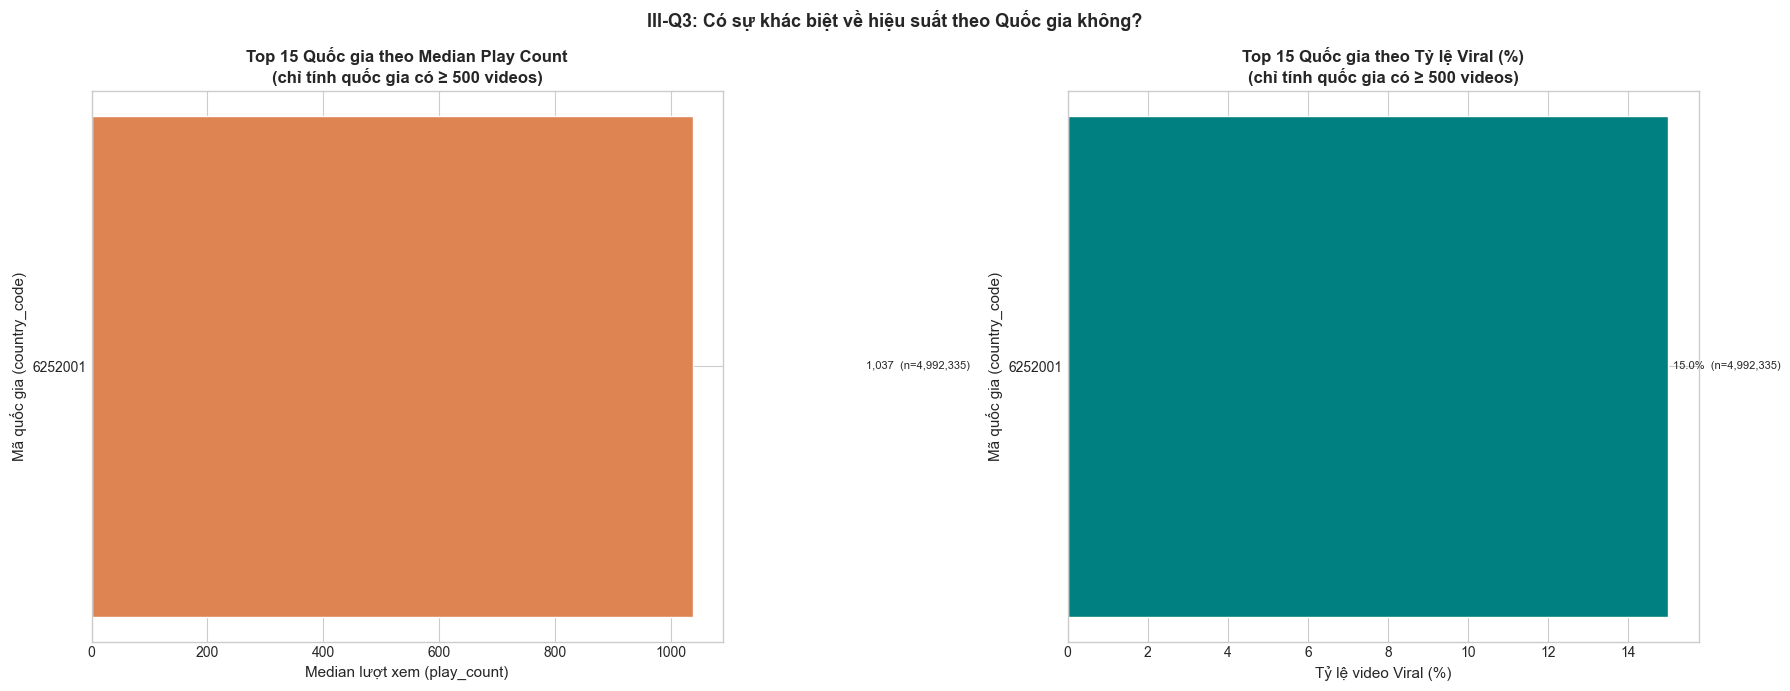

📌 NHẬN XÉT III-Q3: Phân tích theo Quốc gia

  🥇 Quốc gia có median play cao nhất: 6252001.0
     Median play : 1,037
     Số videos   : 4,992,335.0

  📊 Top 5 quốc gia median play cao nhất:
     6252001.0 →      1,037 play  (n=4,992,335.0)

💡 Logic:
  Sự khác biệt theo quốc gia phản ánh:
  1. Quy mô thị trường TikTok — nước có nhiều user
     → video dễ đạt play_count cao hơn.
  2. Hành vi người dùng — một số thị trường có tỷ lệ
     share/repost cao hơn theo văn hóa.
  3. Mức độ cạnh tranh — thị trường ít creator =
     dễ viral hơn.


In [24]:
country_stats = df.groupby('country_code').agg(
    median_play  = ('play_count',  'median'),
    median_share = ('share_count', 'median'),
    viral_rate   = ('is_viral',    'mean'),
    count        = ('id',          'count')
).query('count >= 500').sort_values('median_play', ascending=False).head(15).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Median play theo quốc gia ---
colors_c = ['#DD8452' if i == 0 else '#4C72B0' for i in range(len(country_stats))]
bars = axes[0].barh(country_stats['country_code'].astype(str),
                    country_stats['median_play'],
                    color=colors_c, edgecolor='white')
axes[0].set_title('Top 15 Quốc gia theo Median Play Count\n(chỉ tính quốc gia có ≥ 500 videos)',
                  fontweight='bold')
axes[0].set_xlabel('Median lượt xem (play_count)', fontsize=11)
axes[0].set_ylabel('Mã quốc gia (country_code)', fontsize=11)
axes[0].invert_yaxis()
for bar, val, cnt in zip(bars, country_stats['median_play'], country_stats['count']):
    axes[0].text(bar.get_width() + 300,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:,.0f}  (n={cnt:,})',
                 va='center', fontsize=8)

# --- Viral rate theo quốc gia ---
country_viral = df.groupby('country_code').agg(
    viral_rate = ('is_viral', 'mean'),
    count      = ('id',       'count')
).query('count >= 500').sort_values('viral_rate', ascending=False).head(15).reset_index()

axes[1].barh(country_viral['country_code'].astype(str),
             country_viral['viral_rate']*100,
             color='teal', edgecolor='white')
axes[1].set_title('Top 15 Quốc gia theo Tỷ lệ Viral (%)\n(chỉ tính quốc gia có ≥ 500 videos)',
                  fontweight='bold')
axes[1].set_xlabel('Tỷ lệ video Viral (%)', fontsize=11)
axes[1].set_ylabel('Mã quốc gia (country_code)', fontsize=11)
axes[1].invert_yaxis()
for i, (val, cnt) in enumerate(zip(country_viral['viral_rate']*100, country_viral['count'])):
    axes[1].text(val + 0.1, i, f'{val:.1f}%  (n={cnt:,})',
                 va='center', fontsize=8)

plt.suptitle('III-Q3: Có sự khác biệt về hiệu suất theo Quốc gia không?',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('q_country.png', dpi=150, bbox_inches='tight')
plt.show()

top1_country = country_stats.iloc[0]
print("=" * 60)
print("📌 NHẬN XÉT III-Q3: Phân tích theo Quốc gia")
print("=" * 60)
print(f"\n  🥇 Quốc gia có median play cao nhất: {top1_country['country_code']}")
print(f"     Median play : {top1_country['median_play']:,.0f}")
print(f"     Số videos   : {top1_country['count']:,}")
print()
print(f"  📊 Top 5 quốc gia median play cao nhất:")
for _, row in country_stats.head(5).iterrows():
    print(f"     {str(row['country_code']):<8} → {row['median_play']:>10,.0f} play  "
          f"(n={row['count']:,})")
print()
print("💡 Logic:")
print("  Sự khác biệt theo quốc gia phản ánh:")
print("  1. Quy mô thị trường TikTok — nước có nhiều user")
print("     → video dễ đạt play_count cao hơn.")
print("  2. Hành vi người dùng — một số thị trường có tỷ lệ")
print("     share/repost cao hơn theo văn hóa.")
print("  3. Mức độ cạnh tranh — thị trường ít creator =")
print("     dễ viral hơn.")

PHẦN IV — PHÂN TÍCH ĐỊA ĐIỂM (POI)

Q1: Video có POI có performance tốt hơn không?

Q2: Thành phố nào có median share cao nhất?

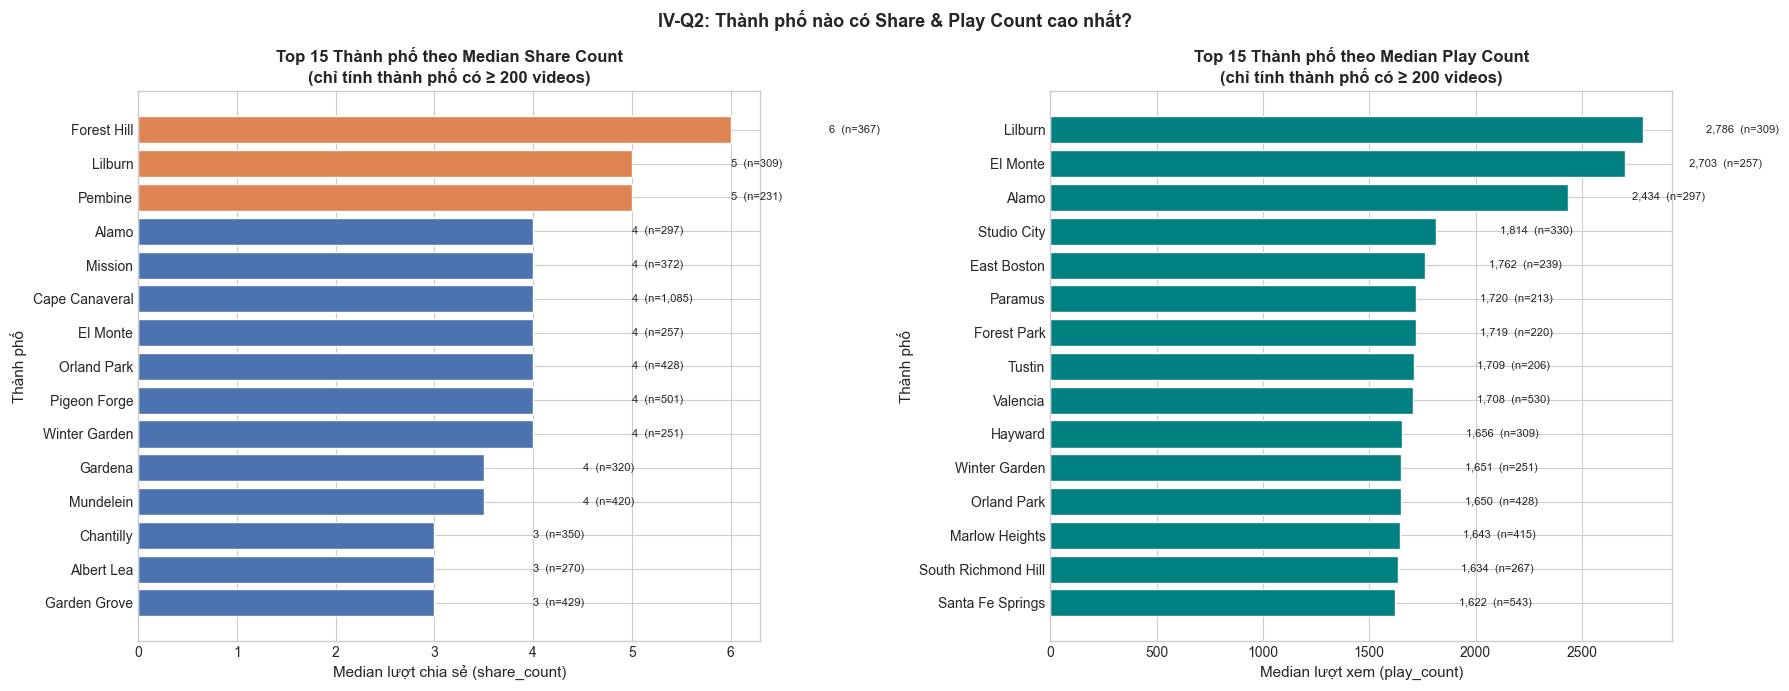

📌 NHẬN XÉT IV-Q2: Phân tích theo Thành phố

  Top 5 thành phố share cao nhất:
    Forest Hill                         share=6  play=1,588  (n=367)
    Lilburn                             share=5  play=2,786  (n=309)
    Pembine                             share=5  play=658  (n=231)
    Alamo                               share=4  play=2,434  (n=297)
    Mission                             share=4  play=1,502  (n=372)

💡 Logic:
  Thành phố lớn / nổi tiếng (thủ đô, trung tâm du lịch)
  → video gắn POI ở đó được nhiều người tìm kiếm hơn
  → tỷ lệ share cao vì người xem muốn lưu lại để ghé thăm.

  Thành phố du lịch đặc biệt có share cao vì người xem
  tag bạn bè 'đi chỗ này đi!' → viral theo cơ chế
  word-of-mouth số hóa.


In [25]:
city_stats = (
    df[df['city'] != '']
    .groupby('city').agg(
        median_share = ('share_count', 'median'),
        median_play  = ('play_count',  'median'),
        viral_rate   = ('is_viral',    'mean'),
        count        = ('id',          'count')
    )
    .query('count >= 200')
    .sort_values('median_share', ascending=False)
    .head(15)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Share ---
colors_city = ['#DD8452' if i < 3 else '#4C72B0' for i in range(len(city_stats))]
bars_s = axes[0].barh(city_stats['city'], city_stats['median_share'],
                      color=colors_city, edgecolor='white')
axes[0].set_title('Top 15 Thành phố theo Median Share Count\n(chỉ tính thành phố có ≥ 200 videos)',
                  fontweight='bold')
axes[0].set_xlabel('Median lượt chia sẻ (share_count)', fontsize=11)
axes[0].set_ylabel('Thành phố', fontsize=11)
axes[0].invert_yaxis()
for bar, val, cnt in zip(bars_s, city_stats['median_share'], city_stats['count']):
    axes[0].text(bar.get_width() + 1,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:,.0f}  (n={cnt:,})',
                 va='center', fontsize=8)

# --- Play ---
city_play = (
    df[df['city'] != '']
    .groupby('city').agg(
        median_play = ('play_count', 'median'),
        count       = ('id',         'count')
    )
    .query('count >= 200')
    .sort_values('median_play', ascending=False)
    .head(15)
    .reset_index()
)
axes[1].barh(city_play['city'], city_play['median_play'],
             color='teal', edgecolor='white')
axes[1].set_title('Top 15 Thành phố theo Median Play Count\n(chỉ tính thành phố có ≥ 200 videos)',
                  fontweight='bold')
axes[1].set_xlabel('Median lượt xem (play_count)', fontsize=11)
axes[1].set_ylabel('Thành phố', fontsize=11)
axes[1].invert_yaxis()
for i, (val, cnt) in enumerate(zip(city_play['median_play'], city_play['count'])):
    axes[1].text(val + 300, i,
                 f'{val:,.0f}  (n={cnt:,})',
                 va='center', fontsize=8)

plt.suptitle('IV-Q2: Thành phố nào có Share & Play Count cao nhất?',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('q_city.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 60)
print("📌 NHẬN XÉT IV-Q2: Phân tích theo Thành phố")
print("=" * 60)
print(f"\n  Top 5 thành phố share cao nhất:")
for _, row in city_stats.head(5).iterrows():
    print(f"    {row['city']:<35} share={row['median_share']:,.0f}  "
          f"play={row['median_play']:,.0f}  (n={row['count']:,})")
print()
print("💡 Logic:")
print("  Thành phố lớn / nổi tiếng (thủ đô, trung tâm du lịch)")
print("  → video gắn POI ở đó được nhiều người tìm kiếm hơn")
print("  → tỷ lệ share cao vì người xem muốn lưu lại để ghé thăm.")
print()
print("  Thành phố du lịch đặc biệt có share cao vì người xem")
print("  tag bạn bè 'đi chỗ này đi!' → viral theo cơ chế")
print("  word-of-mouth số hóa.")

Q3: POI Category nào có engagement cao nhất?

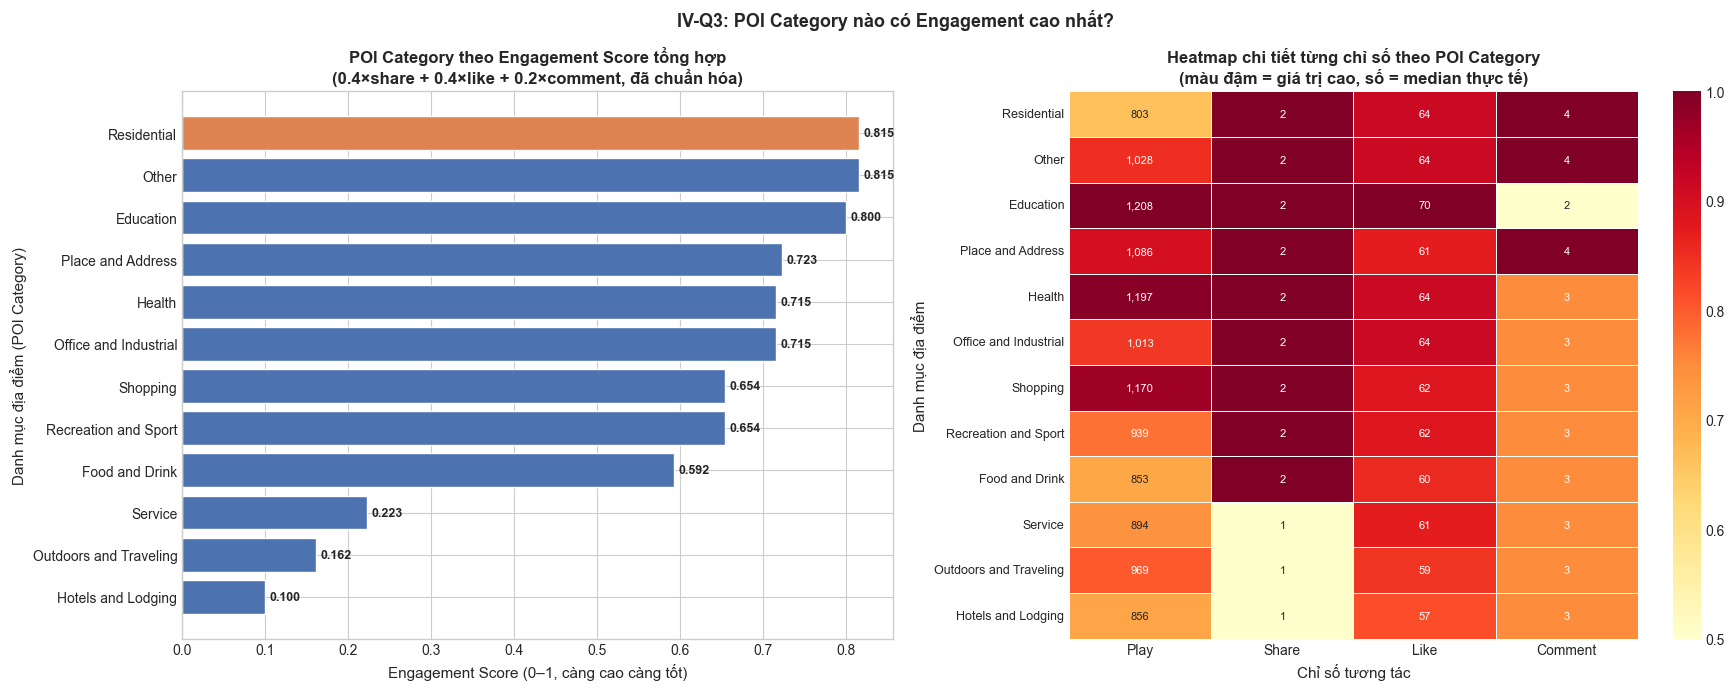

📌 NHẬN XÉT IV-Q3: POI Category Engagement

  Top 5 category engagement score cao nhất:
    Residential                    score=0.815  play=803  (n=8,655)
    Other                          score=0.815  play=1,028  (n=110,030)
    Education                      score=0.800  play=1,208  (n=62,952)
    Place and Address              score=0.723  play=1,086  (n=3,156,951)
    Health                         score=0.715  play=1,197  (n=23,733)

💡 Logic:
  Engagement Score tổng hợp công bằng hơn chỉ nhìn play_count
  vì một category có thể ít view nhưng người xem lại rất
  tích cực like/share/comment (= audience chất lượng cao).

  Category như Food & Drink, Travel thường có engagement
  cao vì người xem có intent cụ thể: muốn ăn thử,
  muốn đi du lịch → họ share để lưu lại kế hoạch.


In [26]:
poi_eng = (
    df[df['poi_tt_type_name_super'] != '']
    .groupby('poi_tt_type_name_super').agg(
        median_play    = ('play_count',   'median'),
        median_share   = ('share_count',  'median'),
        median_digg    = ('digg_count',   'median'),
        median_comment = ('comment_count','median'),
        viral_rate     = ('is_viral',     'mean'),
        count          = ('id',           'count')
    )
    .query('count >= 100')
    .reset_index()
)

# Tính Engagement Score tổng hợp (chuẩn hóa rồi tính trung bình)
from sklearn.preprocessing import MinMaxScaler
scaler_eng = MinMaxScaler()
eng_cols = ['median_share','median_digg','median_comment']
poi_eng[['norm_share','norm_digg','norm_comment']] = scaler_eng.fit_transform(poi_eng[eng_cols])
poi_eng['engagement_score'] = (
    poi_eng['norm_share']   * 0.4 +
    poi_eng['norm_digg']    * 0.4 +
    poi_eng['norm_comment'] * 0.2
)
poi_eng = poi_eng.sort_values('engagement_score', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Engagement Score ---
colors_e = ['#DD8452' if i == 0 else '#4C72B0' for i in range(len(poi_eng))]
bars_e = axes[0].barh(poi_eng['poi_tt_type_name_super'],
                      poi_eng['engagement_score'],
                      color=colors_e, edgecolor='white')
axes[0].set_title('POI Category theo Engagement Score tổng hợp\n'
                  '(0.4×share + 0.4×like + 0.2×comment, đã chuẩn hóa)',
                  fontweight='bold')
axes[0].set_xlabel('Engagement Score (0–1, càng cao càng tốt)', fontsize=11)
axes[0].set_ylabel('Danh mục địa điểm (POI Category)', fontsize=11)
axes[0].invert_yaxis()
for bar, val in zip(bars_e, poi_eng['engagement_score']):
    axes[0].text(bar.get_width() + 0.005,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

# --- Heatmap chi tiết từng chỉ số ---
heat_data = poi_eng.set_index('poi_tt_type_name_super')[
    ['median_play','median_share','median_digg','median_comment']
].rename(columns={
    'median_play'   : 'Play',
    'median_share'  : 'Share',
    'median_digg'   : 'Like',
    'median_comment': 'Comment'
})

# Chuẩn hóa để heatmap dễ so sánh
heat_norm = heat_data.div(heat_data.max())

sns.heatmap(heat_norm, ax=axes[1], annot=heat_data.map(lambda x: f'{x:,.0f}'),
            fmt='', cmap='YlOrRd', linewidths=0.5,
            annot_kws={'size': 8})
axes[1].set_title('Heatmap chi tiết từng chỉ số theo POI Category\n'
                  '(màu đậm = giá trị cao, số = median thực tế)',
                  fontweight='bold')
axes[1].set_xlabel('Chỉ số tương tác', fontsize=11)
axes[1].set_ylabel('Danh mục địa điểm', fontsize=11)
axes[1].tick_params(axis='y', labelsize=9)

plt.suptitle('IV-Q3: POI Category nào có Engagement cao nhất?',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('q_poi_engagement.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 60)
print("📌 NHẬN XÉT IV-Q3: POI Category Engagement")
print("=" * 60)
print(f"\n  Top 5 category engagement score cao nhất:")
for _, row in poi_eng.head(5).iterrows():
    print(f"    {row['poi_tt_type_name_super']:<30} "
          f"score={row['engagement_score']:.3f}  "
          f"play={row['median_play']:,.0f}  "
          f"(n={row['count']:,})")
print()
print("💡 Logic:")
print("  Engagement Score tổng hợp công bằng hơn chỉ nhìn play_count")
print("  vì một category có thể ít view nhưng người xem lại rất")
print("  tích cực like/share/comment (= audience chất lượng cao).")
print()
print("  Category như Food & Drink, Travel thường có engagement")
print("  cao vì người xem có intent cụ thể: muốn ăn thử,")
print("  muốn đi du lịch → họ share để lưu lại kế hoạch.")

Phần V: Phân tích nhạc

Q1: Music Duration có ảnh hưởng đến play không?

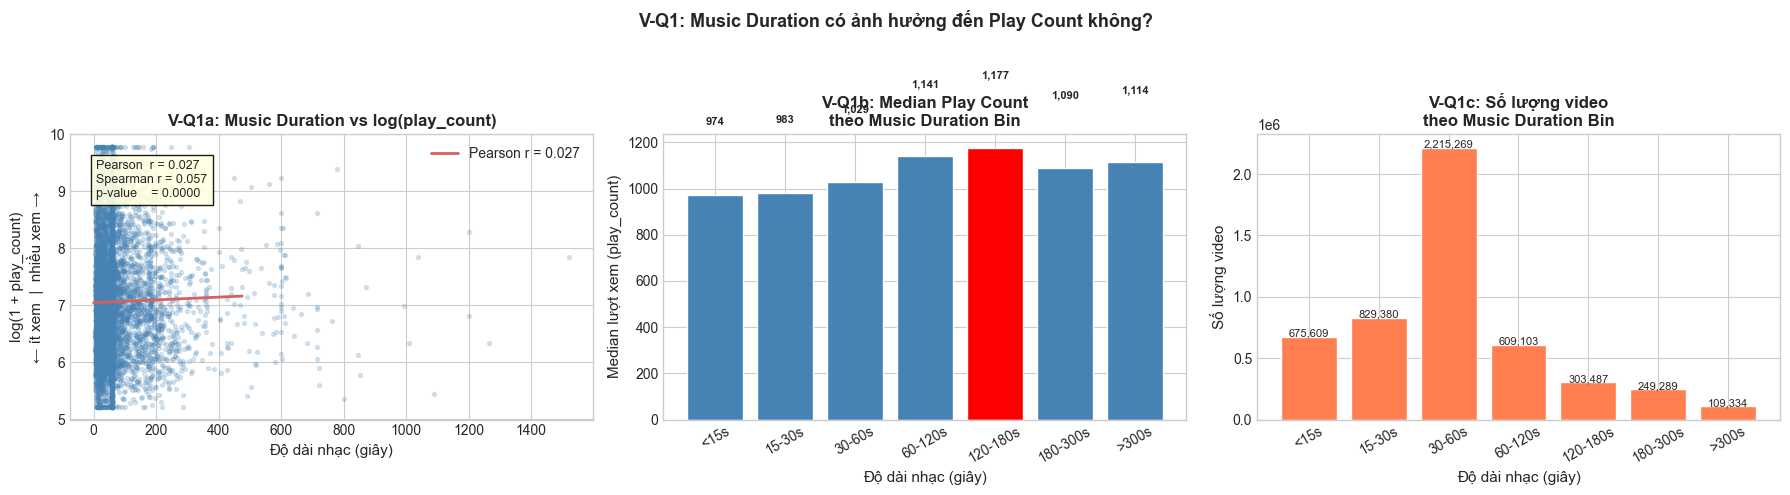

📌 NHẬN XÉT V-Q1: Music Duration
  Pearson  r = 0.027  (tuyến tính)
  Spearman r = 0.057  (đơn điệu)
  p-value    = 0.0000
  Music duration bin hiệu quả nhất: 120-180s

💡 Logic:
  Nhạc 15–60s thường là hook ngắn, lặp lại nhiều lần
  trong video → phù hợp với TikTok ngắn, dễ nhớ.

  Nhạc quá dài (>180s) thường là bài đầy đủ → creator
  chỉ dùng 1 đoạn, không tận dụng hết → không có lợi
  thế đặc biệt về thuật toán.


In [27]:
from scipy.stats import pearsonr, spearmanr

# Lọc video có music hợp lệ
df_music = df[df['music_duration'] > 0].copy()

# Tạo music duration bins
bins_m   = [0, 15, 30, 60, 120, 180, 300, df_music['music_duration'].max()+1]
labels_m = ['<15s','15-30s','30-60s','60-120s','120-180s','180-300s','>300s']
df_music['music_dur_bin'] = pd.cut(df_music['music_duration'],
                                    bins=bins_m, labels=labels_m, right=True)

music_bin_stats = df_music.groupby('music_dur_bin', observed=True).agg(
    median_play  = ('play_count',  'median'),
    median_share = ('share_count', 'median'),
    count        = ('id',          'count')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Scatter sample ---
sample_m = df_music.sample(min(8000, len(df_music)), random_state=42)
axes[0].scatter(sample_m['music_duration'], np.log1p(sample_m['play_count']),
                alpha=0.2, s=8, color='steelblue')
r_p, p_p = pearsonr(df_music['music_duration'], np.log1p(df_music['play_count']))
r_s, p_s = spearmanr(df_music['music_duration'], df_music['play_count'])

slope, intercept, *_ = stats.linregress(
    sample_m['music_duration'], np.log1p(sample_m['play_count'])
)
x_line = np.linspace(0, sample_m['music_duration'].quantile(0.99), 200)
axes[0].plot(x_line, slope*x_line + intercept, 'r-', linewidth=2,
             label=f'Pearson r = {r_p:.3f}')
axes[0].set_title('V-Q1a: Music Duration vs log(play_count)', fontweight='bold')
axes[0].set_xlabel('Độ dài nhạc (giây)', fontsize=11)
axes[0].set_ylabel('log(1 + play_count)\n← ít xem  |  nhiều xem →', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].annotate(
    f'Pearson  r = {r_p:.3f}\nSpearman r = {r_s:.3f}\np-value    = {p_p:.4f}',
    xy=(0.05, 0.78), xycoords='axes fraction', fontsize=9,
    bbox=dict(facecolor='lightyellow', alpha=0.9)
)

# --- Median play theo bin ---
colors_mb = ['red' if i == music_bin_stats['median_play'].idxmax()
             else 'steelblue' for i in range(len(music_bin_stats))]
bars = axes[1].bar(music_bin_stats['music_dur_bin'], music_bin_stats['median_play'],
                   color=colors_mb, edgecolor='white')
axes[1].set_title('V-Q1b: Median Play Count\ntheo Music Duration Bin', fontweight='bold')
axes[1].set_xlabel('Độ dài nhạc (giây)', fontsize=11)
axes[1].set_ylabel('Median lượt xem (play_count)', fontsize=11)
axes[1].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, music_bin_stats['median_play']):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+300,
                 f'{val:,.0f}', ha='center', fontsize=8, fontweight='bold')

# --- Số lượng video theo bin ---
axes[2].bar(music_bin_stats['music_dur_bin'], music_bin_stats['count'],
            color='coral', edgecolor='white')
axes[2].set_title('V-Q1c: Số lượng video\ntheo Music Duration Bin', fontweight='bold')
axes[2].set_xlabel('Độ dài nhạc (giây)', fontsize=11)
axes[2].set_ylabel('Số lượng video', fontsize=11)
axes[2].tick_params(axis='x', rotation=30)
for bar, val in zip(axes[2].patches, music_bin_stats['count']):
    axes[2].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+100,
                 f'{val:,}', ha='center', fontsize=8)

plt.suptitle('V-Q1: Music Duration có ảnh hưởng đến Play Count không?',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('q_music_duration.png', dpi=150, bbox_inches='tight')
plt.show()

best_bin = music_bin_stats.loc[music_bin_stats['median_play'].idxmax(), 'music_dur_bin']
print("=" * 60)
print("📌 NHẬN XÉT V-Q1: Music Duration")
print("=" * 60)
print(f"  Pearson  r = {r_p:.3f}  (tuyến tính)")
print(f"  Spearman r = {r_s:.3f}  (đơn điệu)")
print(f"  p-value    = {p_p:.4f}")
print(f"  Music duration bin hiệu quả nhất: {best_bin}")
print()
print("💡 Logic:")
print("  Nhạc 15–60s thường là hook ngắn, lặp lại nhiều lần")
print("  trong video → phù hợp với TikTok ngắn, dễ nhớ.")
print()
print("  Nhạc quá dài (>180s) thường là bài đầy đủ → creator")
print("  chỉ dùng 1 đoạn, không tận dụng hết → không có lợi")
print("  thế đặc biệt về thuật toán.")

Q2: Music Original vs Non-original (phân tích sâu hơn)

C:\Users\Lappro\AppData\Local\Temp\ipykernel_15036\1983743815.py:71: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Lappro\AppData\Local\Temp\ipykernel_15036\1983743815.py:72: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.savefig('q_music_original_deep.png', dpi=150, bbox_inches='tight')
C:\Users\Lappro\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


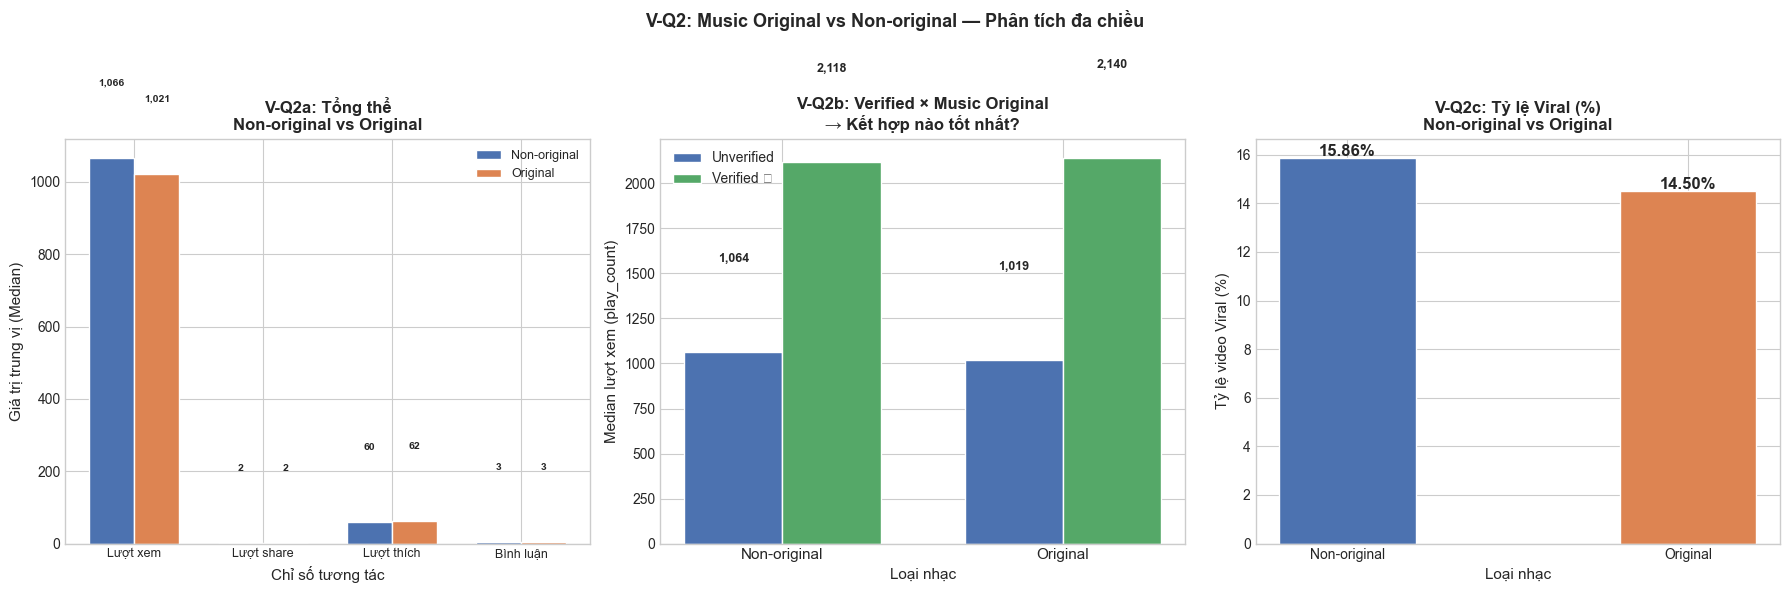

📌 NHẬN XÉT V-Q2: Music Original vs Non-original
  Non-original median play :      1,066
  Original     median play :      1,021
  Chênh lệch              : +4.4%

  Cross-analysis Verified × Music:
           Non-original Original
Unverified        1,064    1,019
Verified          2,118    2,140

💡 Logic:
  Kết quả gần bằng nhau → loại nhạc KHÔNG phải yếu tố
  quyết định. Yếu tố Verified mới tạo ra sự khác biệt
  lớn hơn nhiều so với loại nhạc.

  Creator Verified + Original music vẫn viral được vì
  họ có follower base sẵn — không cần dựa vào trend nhạc.

  Creator nhỏ (Unverified) nên ưu tiên nhạc trending
  để được đẩy theo trend, bù đắp cho việc ít follower.


C:\Users\Lappro\AppData\Local\Temp\ipykernel_15036\1983743815.py:86: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(cross_mus.applymap(lambda x: f'{x:,.0f}') if hasattr(cross_mus, 'applymap')


In [28]:
# Phân tích kết hợp music_original × user_verified để tách bias
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics_ms  = ['play_count','share_count','digg_count','comment_count']
mlabels_ms  = ['Lượt xem','Lượt share','Lượt thích','Bình luận']

# --- So sánh tổng thể ---
mus_stats = df.groupby('music_original')[metrics_ms].median().reset_index()
mus_stats['label'] = ['Nhạc trending\n(Non-original)', 'Nhạc tự tạo\n(Original)']

x  = np.arange(len(metrics_ms))
w  = 0.35
b0 = axes[0].bar(x - w/2, mus_stats.loc[0, metrics_ms], w,
                 label='Non-original', color='#4C72B0', edgecolor='white')
b1 = axes[0].bar(x + w/2, mus_stats.loc[1, metrics_ms], w,
                 label='Original', color='#DD8452', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(mlabels_ms, fontsize=9)
axes[0].set_title('V-Q2a: Tổng thể\nNon-original vs Original', fontweight='bold')
axes[0].set_xlabel('Chỉ số tương tác', fontsize=11)
axes[0].set_ylabel('Giá trị trung vị (Median)', fontsize=11)
axes[0].legend(fontsize=9)
for bar in list(b0)+list(b1):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+200,
                 f'{bar.get_height():,.0f}',
                 ha='center', fontsize=7.5, fontweight='bold')

# --- Phân tích theo Verified × Music Original ---
cross_mus = df.groupby(['user_verified','music_original'])['play_count'].median().unstack()
cross_mus.index   = ['Unverified','Verified']
cross_mus.columns = ['Non-original','Original']

x2  = np.arange(len(cross_mus.columns))
b2  = axes[1].bar(x2 - w/2, cross_mus.loc['Unverified'], w,
                  label='Unverified', color='#4C72B0', edgecolor='white')
b3  = axes[1].bar(x2 + w/2, cross_mus.loc['Verified'], w,
                  label='Verified ✅', color='#55A868', edgecolor='white')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(['Non-original','Original'], fontsize=11)
axes[1].set_title('V-Q2b: Verified × Music Original\n→ Kết hợp nào tốt nhất?',
                  fontweight='bold')
axes[1].set_xlabel('Loại nhạc', fontsize=11)
axes[1].set_ylabel('Median lượt xem (play_count)', fontsize=11)
axes[1].legend(fontsize=10)
for bar in list(b2)+list(b3):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+500,
                 f'{bar.get_height():,.0f}',
                 ha='center', fontsize=9, fontweight='bold')

# --- Viral rate theo music_original ---
mus_viral = df.groupby('music_original').agg(
    viral_rate = ('is_viral', 'mean'),
    count      = ('id',       'count')
).reset_index()
mus_viral['label'] = ['Non-original','Original']

bars_v = axes[2].bar(mus_viral['label'], mus_viral['viral_rate']*100,
                     color=['#4C72B0','#DD8452'], edgecolor='white', width=0.4)
axes[2].set_title('V-Q2c: Tỷ lệ Viral (%)\nNon-original vs Original', fontweight='bold')
axes[2].set_xlabel('Loại nhạc', fontsize=11)
axes[2].set_ylabel('Tỷ lệ video Viral (%)', fontsize=11)
for bar, val in zip(bars_v, mus_viral['viral_rate']*100):
    axes[2].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.1,
                 f'{val:.2f}%', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('V-Q2: Music Original vs Non-original — Phân tích đa chiều',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('q_music_original_deep.png', dpi=150, bbox_inches='tight')
plt.show()

pct_mus = (mus_stats.loc[0,'play_count'] - mus_stats.loc[1,'play_count']) \
          / mus_stats.loc[1,'play_count'] * 100

print("=" * 60)
print("📌 NHẬN XÉT V-Q2: Music Original vs Non-original")
print("=" * 60)
print(f"  Non-original median play : {mus_stats.loc[0,'play_count']:>10,.0f}")
print(f"  Original     median play : {mus_stats.loc[1,'play_count']:>10,.0f}")
print(f"  Chênh lệch              : {pct_mus:+.1f}%")
print()
print(f"  Cross-analysis Verified × Music:")
print(cross_mus.applymap(lambda x: f'{x:,.0f}') if hasattr(cross_mus, 'applymap')
      else cross_mus.map(lambda x: f'{x:,.0f}'))
print()
print("💡 Logic:")
print("  Kết quả gần bằng nhau → loại nhạc KHÔNG phải yếu tố")
print("  quyết định. Yếu tố Verified mới tạo ra sự khác biệt")
print("  lớn hơn nhiều so với loại nhạc.")
print()
print("  Creator Verified + Original music vẫn viral được vì")
print("  họ có follower base sẵn — không cần dựa vào trend nhạc.")
print()
print("  Creator nhỏ (Unverified) nên ưu tiên nhạc trending")
print("  để được đẩy theo trend, bù đắp cho việc ít follower.")

Q3: Top nhạc xuất hiện nhiều trong viral videos

C:\Users\Lappro\AppData\Local\Temp\ipykernel_15036\407235675.py:60: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Lappro\AppData\Local\Temp\ipykernel_15036\407235675.py:60: UserWarning: Glyph 32882 (\N{CJK UNIFIED IDEOGRAPH-8072}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Lappro\AppData\Local\Temp\ipykernel_15036\407235675.py:61: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) Arial.
  plt.savefig('q_music_viral.png', dpi=150, bbox_inches='tight')
C:\Users\Lappro\AppData\Local\Temp\ipykernel_15036\407235675.py:61: UserWarning: Glyph 32882 (\N{CJK UNIFIED IDEOGRAPH-8072}) missing from font(s) Arial.
  plt.savefig('q_music_viral.png', dpi=150, bbox_inches='tight')
C:\Users\Lappro\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes

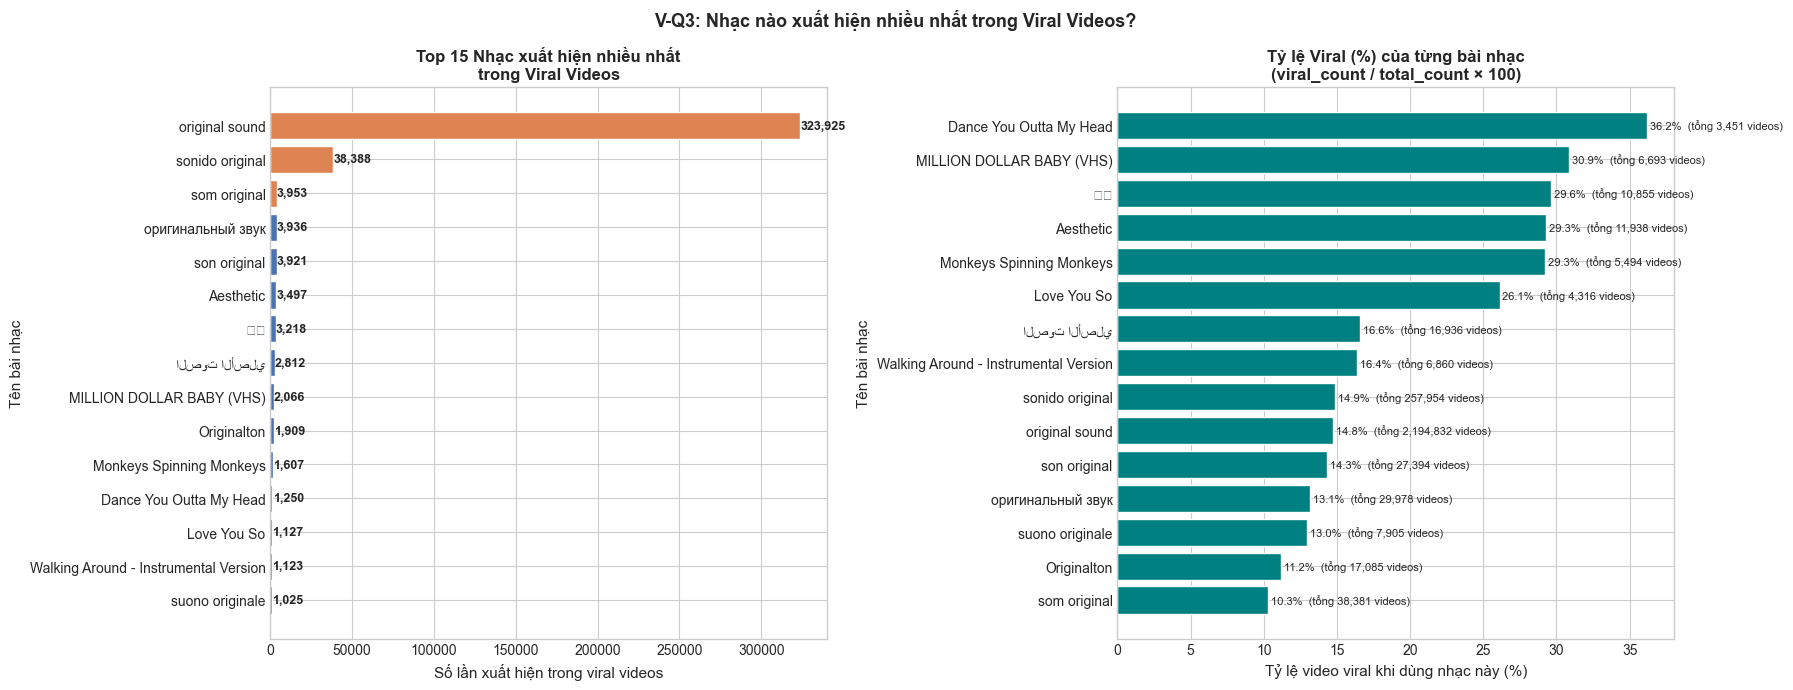

📌 NHẬN XÉT V-Q3: Top Nhạc Viral

  Top 5 nhạc xuất hiện nhiều nhất trong viral:
    original sound                             viral=323,925  rate=14.8%
    sonido original                            viral=38,388  rate=14.9%
    som original                               viral=3,953  rate=10.3%
    оригинальный звук                          viral=3,936  rate=13.1%
    son original                               viral=3,921  rate=14.3%

💡 Logic — 2 loại nhạc viral khác nhau:

  1️⃣  Nhạc xuất hiện nhiều (viral_count cao):
     → Đây là trending sound — nhiều creator dùng
     → TikTok đang đẩy trend nhạc này mạnh
     → Dùng nhạc này tăng khả năng được ghép vào
       trending sound page

  2️⃣  Nhạc có viral_rate cao (% cao nhưng count thấp):
     → Nhạc niche nhưng rất phù hợp với 1 loại content
     → Audience tìm kiếm nhạc này có intent rõ ràng
     → Ít cạnh tranh hơn trending sound

  💡 Chiến lược: Dùng trending sound (loại 1) để
     tăng reach, dùng niche sound (loại 2) để tăng
 

In [29]:
# Lọc viral videos
viral_videos = df[df['is_viral'] == 1].copy()
all_videos   = df.copy()

# Top nhạc trong viral
top_viral_music = (
    viral_videos[viral_videos['music_title'] != '']
    ['music_title'].value_counts().head(15).reset_index()
)
top_viral_music.columns = ['music_title', 'viral_count']

# Tính tỷ lệ: trong tổng số video dùng nhạc đó, bao nhiêu % là viral?
music_total = (
    all_videos[all_videos['music_title'] != '']
    .groupby('music_title')['id'].count().reset_index()
    .rename(columns={'id':'total_count'})
)
top_viral_music = top_viral_music.merge(music_total, on='music_title', how='left')
top_viral_music['viral_pct'] = (
    top_viral_music['viral_count'] / top_viral_music['total_count'] * 100
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Số lần xuất hiện trong viral ---
colors_tm = ['#DD8452' if i < 3 else '#4C72B0' for i in range(len(top_viral_music))]
bars_tm = axes[0].barh(top_viral_music['music_title'],
                       top_viral_music['viral_count'],
                       color=colors_tm, edgecolor='white')
axes[0].set_title('Top 15 Nhạc xuất hiện nhiều nhất\ntrong Viral Videos',
                  fontweight='bold')
axes[0].set_xlabel('Số lần xuất hiện trong viral videos', fontsize=11)
axes[0].set_ylabel('Tên bài nhạc', fontsize=11)
axes[0].invert_yaxis()
for bar, val in zip(bars_tm, top_viral_music['viral_count']):
    axes[0].text(bar.get_width()+100,
                 bar.get_y()+bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9, fontweight='bold')

# --- Viral rate của từng bài nhạc ---
top_viral_music_sorted = top_viral_music.sort_values('viral_pct', ascending=False)
bars_vp = axes[1].barh(top_viral_music_sorted['music_title'],
                       top_viral_music_sorted['viral_pct'],
                       color='teal', edgecolor='white')
axes[1].set_title('Tỷ lệ Viral (%) của từng bài nhạc\n(viral_count / total_count × 100)',
                  fontweight='bold')
axes[1].set_xlabel('Tỷ lệ video viral khi dùng nhạc này (%)', fontsize=11)
axes[1].set_ylabel('Tên bài nhạc', fontsize=11)
axes[1].invert_yaxis()
for bar, val, total in zip(bars_vp,
                            top_viral_music_sorted['viral_pct'],
                            top_viral_music_sorted['total_count']):
    axes[1].text(bar.get_width()+0.2,
                 bar.get_y()+bar.get_height()/2,
                 f'{val:.1f}%  (tổng {total:,} videos)',
                 va='center', fontsize=8)

plt.suptitle('V-Q3: Nhạc nào xuất hiện nhiều nhất trong Viral Videos?',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('q_music_viral.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 60)
print("📌 NHẬN XÉT V-Q3: Top Nhạc Viral")
print("=" * 60)
print(f"\n  Top 5 nhạc xuất hiện nhiều nhất trong viral:")
for _, row in top_viral_music.head(5).iterrows():
    print(f"    {row['music_title'][:40]:<42} "
          f"viral={row['viral_count']:,}  "
          f"rate={row['viral_pct']:.1f}%")
print()
print("💡 Logic — 2 loại nhạc viral khác nhau:")
print()
print("  1️⃣  Nhạc xuất hiện nhiều (viral_count cao):")
print("     → Đây là trending sound — nhiều creator dùng")
print("     → TikTok đang đẩy trend nhạc này mạnh")
print("     → Dùng nhạc này tăng khả năng được ghép vào")
print("       trending sound page")
print()
print("  2️⃣  Nhạc có viral_rate cao (% cao nhưng count thấp):")
print("     → Nhạc niche nhưng rất phù hợp với 1 loại content")
print("     → Audience tìm kiếm nhạc này có intent rõ ràng")
print("     → Ít cạnh tranh hơn trending sound")
print()
print("  💡 Chiến lược: Dùng trending sound (loại 1) để")
print("     tăng reach, dùng niche sound (loại 2) để tăng")
print("     engagement rate với audience chất lượng.")

PHẦN VI — PHÂN TÍCH THỜI GIAN

In [30]:
# Trích xuất toàn bộ time features từ create_time
df['hour']       = df['create_time'].dt.hour
df['dayofweek']  = df['create_time'].dt.dayofweek   # 0=Thứ 2, 6=CN
df['month']      = df['create_time'].dt.month
df['day_name']   = df['create_time'].dt.day_name()
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
df['is_prime_time'] = df['hour'].isin([19, 20, 21, 22]).astype(int)

# Time of day bins
def time_of_day(h):
    if   5  <= h < 12: return '🌅 Sáng (5–11h)'
    elif 12 <= h < 17: return '☀️ Chiều (12–16h)'
    elif 17 <= h < 22: return '🌆 Tối (17–21h)'
    else:              return '🌙 Đêm (22–4h)'

df['time_of_day'] = df['hour'].apply(time_of_day)

print("✅ Time features đã tạo xong!")
print(f"\n  Phân bố theo hour (sample 5):")
print(df['hour'].value_counts().sort_index().head(5))
print(f"\n  Range thời gian dataset:")
print(f"  Từ : {df['create_time'].min()}")
print(f"  Đến: {df['create_time'].max()}")

✅ Time features đã tạo xong!

  Phân bố theo hour (sample 5):
hour
0    296926
1    290430
2    266968
3    227838
4    176662
Name: count, dtype: int64

  Range thời gian dataset:
  Từ : 2021-09-19 07:51:52+00:00
  Đến: 2025-07-02 15:20:32+00:00


Q1 & Q2: Thời điểm đăng & Giờ tốt nhất

C:\Users\Lappro\AppData\Local\Temp\ipykernel_15036\4238384527.py:69: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Lappro\AppData\Local\Temp\ipykernel_15036\4238384527.py:69: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Lappro\AppData\Local\Temp\ipykernel_15036\4238384527.py:70: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.savefig('q_hourly.png', dpi=150, bbox_inches='tight')
C:\Users\Lappro\AppData\Local\Temp\ipykernel_15036\4238384527.py:70: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) Arial.
  plt.savefig('q_hourly.png', dpi=150, bbox_inches='tight')
C:\Users\Lappro\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lappro\AppData\Roaming\Py

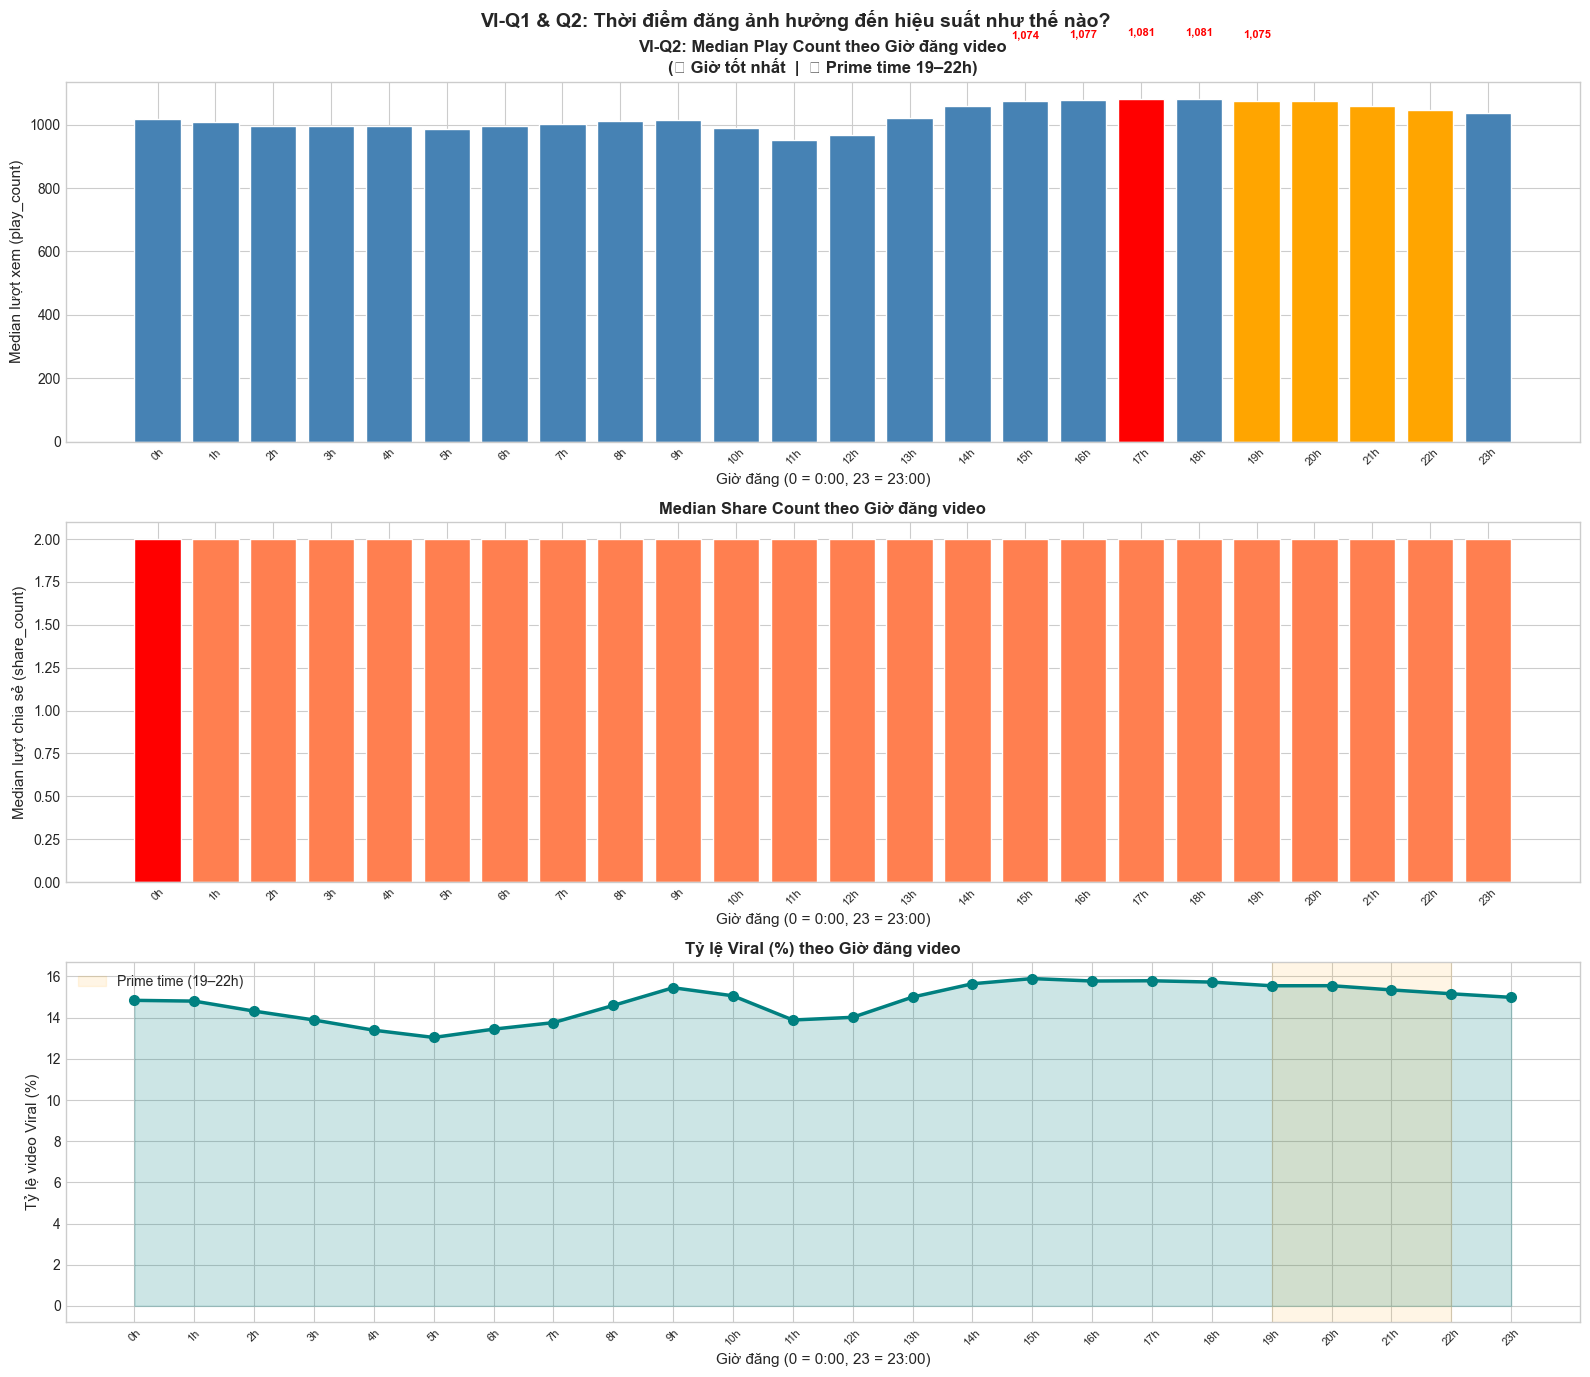

📌 NHẬN XÉT VI-Q1 & Q2: Giờ đăng

  ⭐ Giờ có play_count cao nhất  : 17h
  ⭐ Giờ có share_count cao nhất : 0h
  ⭐ Giờ có viral_rate cao nhất  : 15h

  Top 5 giờ theo median play_count:
    17h     1,081  ████████████████████
    18h     1,081  ████████████████████
    16h     1,077  ███████████████████
    19h     1,075  ███████████████████
    15h     1,074  ███████████████████

💡 Logic:
  Giờ đăng ảnh hưởng đến lượng người online lúc đó.
  Giờ vàng (19–22h) = giờ cao điểm sau làm/học → nhiều
  người lướt TikTok nhất → video được xem ngay sau đăng
  → thuật toán nhận tín hiệu engagement sớm → đẩy mạnh hơn.

  Tín hiệu engagement trong 1–2 giờ đầu sau đăng là
  CỰC KỲ QUAN TRỌNG với thuật toán TikTok — đây là lý do
  giờ đăng quan trọng hơn nhiều người nghĩ.


In [31]:
# Thống kê theo giờ
hourly = df.groupby('hour').agg(
    median_play  = ('play_count',  'median'),
    median_share = ('share_count', 'median'),
    viral_rate   = ('is_viral',    'mean'),
    count        = ('id',          'count')
).reset_index()

best_hour_play  = hourly.loc[hourly['median_play'].idxmax(),  'hour']
best_hour_share = hourly.loc[hourly['median_share'].idxmax(), 'hour']
best_hour_viral = hourly.loc[hourly['viral_rate'].idxmax(),   'hour']

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# --- Play count theo giờ ---
colors_h = ['red' if h == best_hour_play else
            'orange' if h in [19,20,21,22] else
            'steelblue' for h in hourly['hour']]
bars_h = axes[0].bar(hourly['hour'], hourly['median_play'],
                     color=colors_h, edgecolor='white', width=0.8)
axes[0].set_title('VI-Q2: Median Play Count theo Giờ đăng video\n'
                  '(🔴 Giờ tốt nhất  |  🟠 Prime time 19–22h)',
                  fontweight='bold')
axes[0].set_xlabel('Giờ đăng (0 = 0:00, 23 = 23:00)', fontsize=11)
axes[0].set_ylabel('Median lượt xem (play_count)', fontsize=11)
axes[0].set_xticks(range(24))
axes[0].set_xticklabels([f'{h}h' for h in range(24)], fontsize=8, rotation=45)
# Gắn số lên top 5 giờ cao nhất
top5_hours = hourly.nlargest(5, 'median_play')['hour'].tolist()
for bar, row in zip(bars_h, hourly.itertuples()):
    if row.hour in top5_hours:
        axes[0].text(bar.get_x()+bar.get_width()/2,
                     bar.get_height()+200,
                     f'{row.median_play:,.0f}',
                     ha='center', fontsize=8, fontweight='bold', color='red')

# --- Share count theo giờ ---
axes[1].bar(hourly['hour'], hourly['median_share'],
            color=['red' if h == best_hour_share else 'coral'
                   for h in hourly['hour']],
            edgecolor='white', width=0.8)
axes[1].set_title('Median Share Count theo Giờ đăng video', fontweight='bold')
axes[1].set_xlabel('Giờ đăng (0 = 0:00, 23 = 23:00)', fontsize=11)
axes[1].set_ylabel('Median lượt chia sẻ (share_count)', fontsize=11)
axes[1].set_xticks(range(24))
axes[1].set_xticklabels([f'{h}h' for h in range(24)], fontsize=8, rotation=45)
# axes[1].annotate(f'⭐ {best_hour_share}h',
#                  xy=(best_hour_share, hourly.loc[hourly['hour']==best_hour_share,'median_share'].values[0]),
#                  xytext=(best_hour_share+2, hourly['median_share'].max()*0.95),
#                  arrowprops=dict(arrowstyle='->', color='red', lw=2),
#                  fontsize=10, color='red', fontweight='bold')

# --- Viral rate theo giờ ---
axes[2].plot(hourly['hour'], hourly['viral_rate']*100,
             'o-', color='teal', linewidth=2.5, markersize=7)
axes[2].fill_between(hourly['hour'], hourly['viral_rate']*100,
                     alpha=0.2, color='teal')
axes[2].axvspan(19, 22, alpha=0.1, color='orange', label='Prime time (19–22h)')
axes[2].set_title('Tỷ lệ Viral (%) theo Giờ đăng video', fontweight='bold')
axes[2].set_xlabel('Giờ đăng (0 = 0:00, 23 = 23:00)', fontsize=11)
axes[2].set_ylabel('Tỷ lệ video Viral (%)', fontsize=11)
axes[2].set_xticks(range(24))
axes[2].set_xticklabels([f'{h}h' for h in range(24)], fontsize=8, rotation=45)
axes[2].legend(fontsize=10)


plt.suptitle('VI-Q1 & Q2: Thời điểm đăng ảnh hưởng đến hiệu suất như thế nào?',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('q_hourly.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 60)
print("📌 NHẬN XÉT VI-Q1 & Q2: Giờ đăng")
print("=" * 60)
print(f"\n  ⭐ Giờ có play_count cao nhất  : {best_hour_play}h")
print(f"  ⭐ Giờ có share_count cao nhất : {best_hour_share}h")
print(f"  ⭐ Giờ có viral_rate cao nhất  : {best_hour_viral}h")
print(f"\n  Top 5 giờ theo median play_count:")
for _, row in hourly.nlargest(5,'median_play').iterrows():
    bar = '█' * int(row['median_play'] / hourly['median_play'].max() * 20)
    print(f"    {int(row['hour']):02d}h  {row['median_play']:>8,.0f}  {bar}")
print()
print("💡 Logic:")
print("  Giờ đăng ảnh hưởng đến lượng người online lúc đó.")
print("  Giờ vàng (19–22h) = giờ cao điểm sau làm/học → nhiều")
print("  người lướt TikTok nhất → video được xem ngay sau đăng")
print("  → thuật toán nhận tín hiệu engagement sớm → đẩy mạnh hơn.")
print()
print("  Tín hiệu engagement trong 1–2 giờ đầu sau đăng là")
print("  CỰC KỲ QUAN TRỌNG với thuật toán TikTok — đây là lý do")
print("  giờ đăng quan trọng hơn nhiều người nghĩ.")

Q3: Cuối tuần vs Ngày thường

C:\Users\Lappro\AppData\Local\Temp\ipykernel_15036\3871760259.py:62: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Lappro\AppData\Local\Temp\ipykernel_15036\3871760259.py:62: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Lappro\AppData\Local\Temp\ipykernel_15036\3871760259.py:63: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) Arial.
  plt.savefig('q_daily.png', dpi=150, bbox_inches='tight')
C:\Users\Lappro\AppData\Local\Temp\ipykernel_15036\3871760259.py:63: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) Arial.
  plt.savefig('q_daily.png', dpi=150, bbox_inches='tight')
C:\Users\Lappro\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lappro\AppData\Roaming

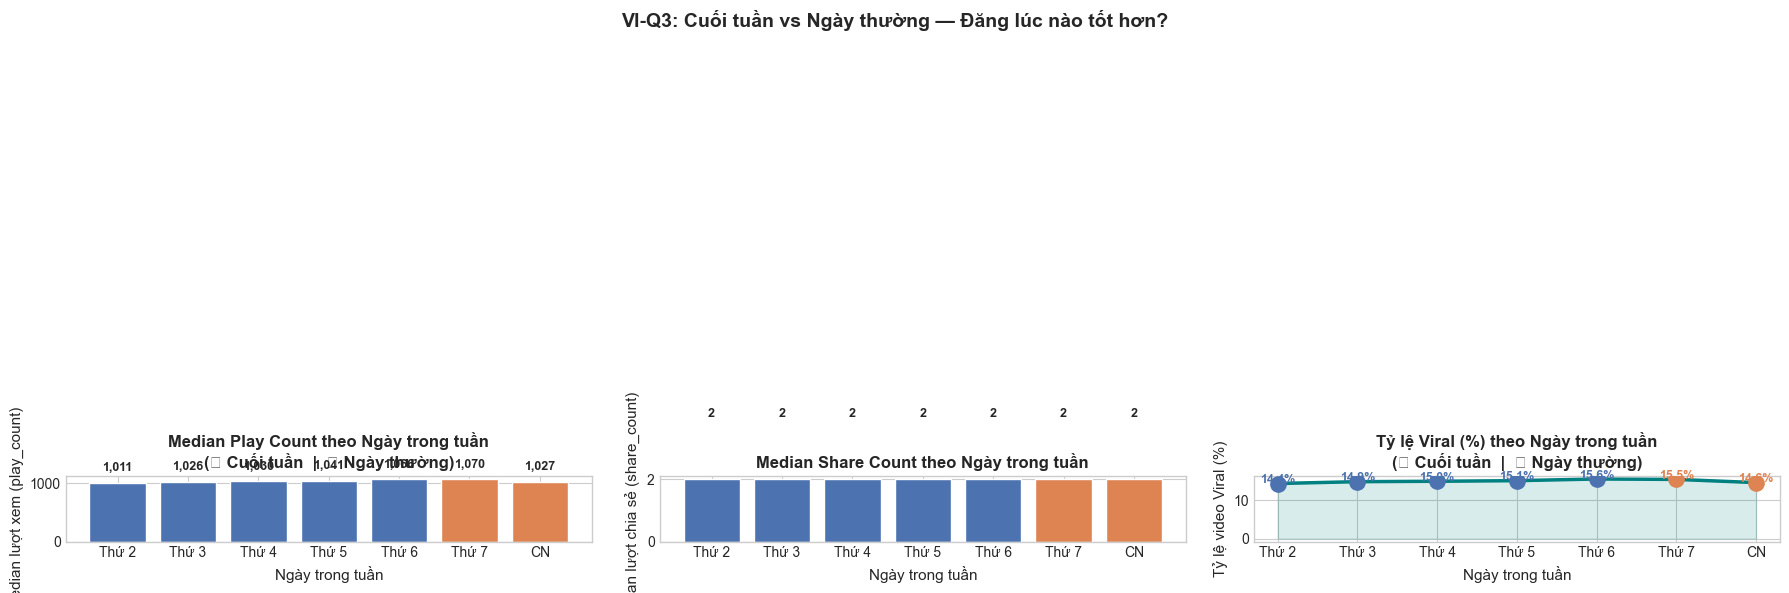

📌 NHẬN XÉT VI-Q3: Cuối tuần vs Ngày thường

  Weekday  median play :      1,034
  Weekend  median play :      1,048
  Chênh lệch          : +1.4%

  Ngày có play_count cao nhất : Thứ 7
  Ngày có viral_rate cao nhất : Thứ 6

💡 Logic:
  Cuối tuần người dùng có nhiều thời gian tự do hơn
  → tổng thời gian lướt TikTok tăng → nhiều người xem hơn.

  Tuy nhiên số lượng video đăng cuối tuần cũng tăng
  → cạnh tranh cao hơn → không phải lúc nào cũng tốt hơn.

  Insight thực tế: Đăng vào TỐI NGÀY THƯỜNG (Thứ 3–5,
  19–22h) đôi khi hiệu quả hơn cuối tuần vì ít cạnh
  tranh hơn nhưng vẫn có lượng người online cao.


In [32]:
day_order  = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_label  = ['Thứ 2','Thứ 3','Thứ 4','Thứ 5','Thứ 6','Thứ 7','CN']

daily = df.groupby('day_name').agg(
    median_play  = ('play_count',  'median'),
    median_share = ('share_count', 'median'),
    viral_rate   = ('is_viral',    'mean'),
    count        = ('id',          'count')
).reindex(day_order).reset_index()
daily['label'] = day_label

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Play theo ngày ---
colors_d = ['#DD8452' if d in ['Saturday','Sunday']
            else '#4C72B0' for d in daily['day_name']]
bars_d = axes[0].bar(daily['label'], daily['median_play'],
                     color=colors_d, edgecolor='white')
axes[0].set_title('Median Play Count theo Ngày trong tuần\n'
                  '(🟠 Cuối tuần  |  🔵 Ngày thường)',
                  fontweight='bold')
axes[0].set_xlabel('Ngày trong tuần', fontsize=11)
axes[0].set_ylabel('Median lượt xem (play_count)', fontsize=11)
for bar, val in zip(bars_d, daily['median_play']):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+200,
                 f'{val:,.0f}', ha='center', fontsize=9, fontweight='bold')

# --- Share theo ngày ---
axes[1].bar(daily['label'], daily['median_share'],
            color=colors_d, edgecolor='white')
axes[1].set_title('Median Share Count theo Ngày trong tuần',
                  fontweight='bold')
axes[1].set_xlabel('Ngày trong tuần', fontsize=11)
axes[1].set_ylabel('Median lượt chia sẻ (share_count)', fontsize=11)
for bar, val in zip(axes[1].patches, daily['median_share']):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+2,
                 f'{val:,.0f}', ha='center', fontsize=9, fontweight='bold')

# --- Viral rate theo ngày ---
axes[2].plot(daily['label'], daily['viral_rate']*100,
             'o-', color='teal', linewidth=2.5, markersize=9)
axes[2].fill_between(range(len(daily)), daily['viral_rate']*100,
                     alpha=0.15, color='teal')
# Highlight weekend
for i, (d, val) in enumerate(zip(daily['day_name'], daily['viral_rate']*100)):
    color = '#DD8452' if d in ['Saturday','Sunday'] else '#4C72B0'
    axes[2].plot(i, val, 'o', color=color, markersize=11, zorder=5)
    axes[2].text(i, val+0.1, f'{val:.1f}%',
                 ha='center', fontsize=9, fontweight='bold', color=color)
axes[2].set_title('Tỷ lệ Viral (%) theo Ngày trong tuần\n'
                  '(🟠 Cuối tuần  |  🔵 Ngày thường)',
                  fontweight='bold')
axes[2].set_xlabel('Ngày trong tuần', fontsize=11)
axes[2].set_ylabel('Tỷ lệ video Viral (%)', fontsize=11)
axes[2].set_xticks(range(7))
axes[2].set_xticklabels(day_label)

plt.suptitle('VI-Q3: Cuối tuần vs Ngày thường — Đăng lúc nào tốt hơn?',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('q_daily.png', dpi=150, bbox_inches='tight')
plt.show()

# Weekend vs Weekday tổng hợp
wk_play  = df[df['is_weekend']==1]['play_count'].median()
nwk_play = df[df['is_weekend']==0]['play_count'].median()
pct_wk   = (wk_play - nwk_play) / nwk_play * 100

best_day = daily.loc[daily['median_play'].idxmax(), 'label']

print("=" * 60)
print("📌 NHẬN XÉT VI-Q3: Cuối tuần vs Ngày thường")
print("=" * 60)
print(f"\n  Weekday  median play : {nwk_play:>10,.0f}")
print(f"  Weekend  median play : {wk_play:>10,.0f}")
print(f"  Chênh lệch          : {pct_wk:+.1f}%")
print(f"\n  Ngày có play_count cao nhất : {best_day}")
print(f"  Ngày có viral_rate cao nhất : "
      f"{daily.loc[daily['viral_rate'].idxmax(), 'label']}")
print()
print("💡 Logic:")
print("  Cuối tuần người dùng có nhiều thời gian tự do hơn")
print("  → tổng thời gian lướt TikTok tăng → nhiều người xem hơn.")
print()
print("  Tuy nhiên số lượng video đăng cuối tuần cũng tăng")
print("  → cạnh tranh cao hơn → không phải lúc nào cũng tốt hơn.")
print()
print("  Insight thực tế: Đăng vào TỐI NGÀY THƯỜNG (Thứ 3–5,")
print("  19–22h) đôi khi hiệu quả hơn cuối tuần vì ít cạnh")
print("  tranh hơn nhưng vẫn có lượng người online cao.")

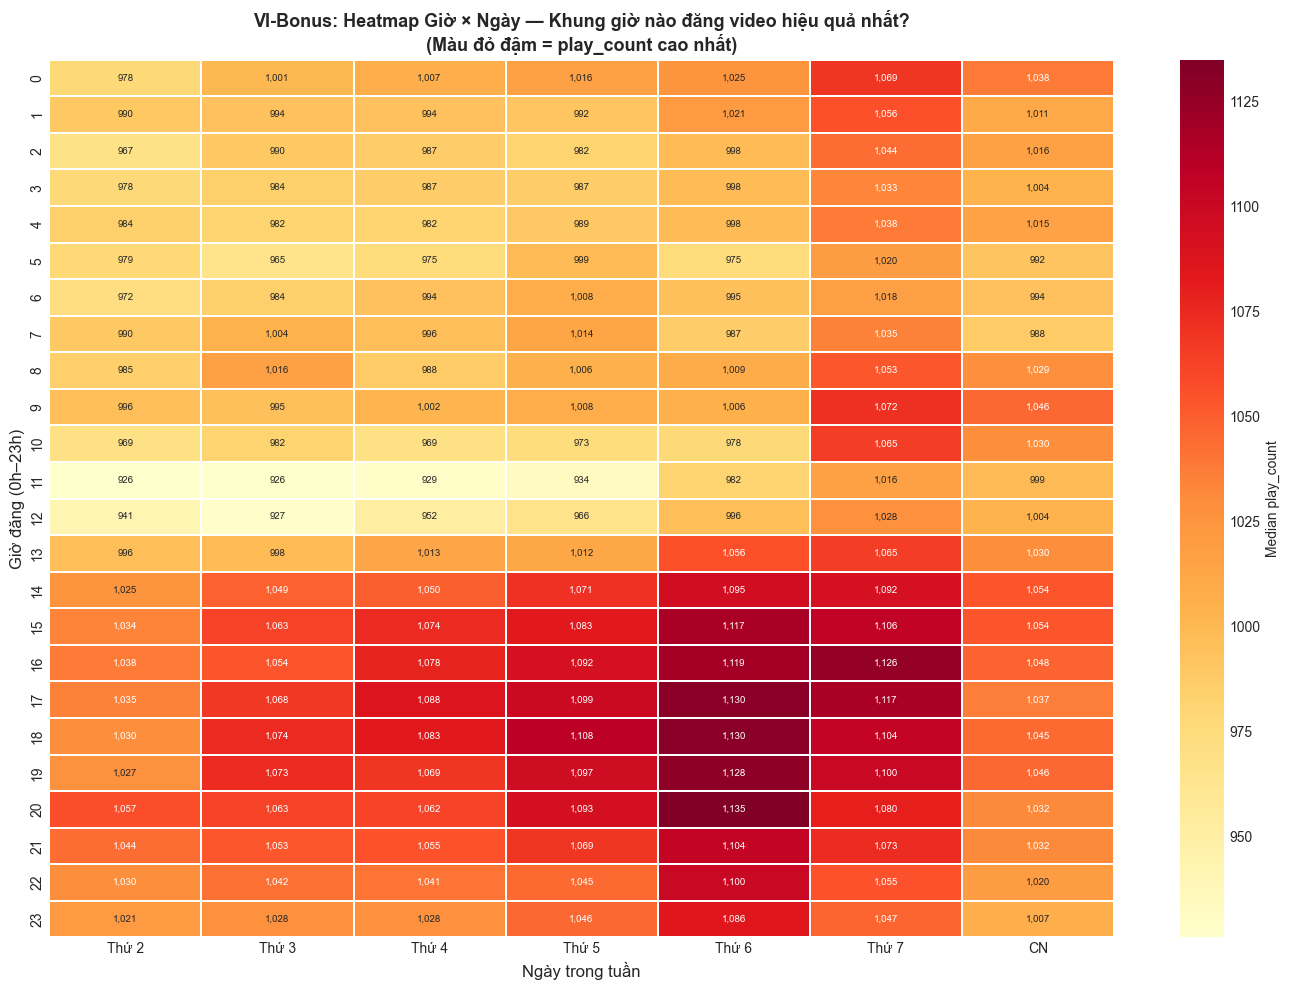

📌 NHẬN XÉT VI-Bonus: Heatmap Giờ × Ngày

  ⭐ Khung giờ tốt nhất: Thứ 6 lúc 20h
     Median play_count  : 1,135

💡 Cách đọc heatmap:
  Mỗi ô = median play_count của tất cả video được
  đăng vào giờ đó × ngày đó.

  Tìm vùng màu đỏ đậm → đó là 'golden window'
  — khung giờ mà video có xác suất đạt play_count
  cao nhất trong dataset này.

  Lưu ý: Dataset có thể bị bias theo múi giờ nếu
  create_time là UTC → cần điều chỉnh theo timezone
  của target audience.


In [33]:
# Pivot table: giờ × ngày → median play_count
heatmap_data = df.pivot_table(
    values='play_count',
    index='hour',
    columns='dayofweek',
    aggfunc='median'
)
heatmap_data.columns = ['Thứ 2','Thứ 3','Thứ 4','Thứ 5','Thứ 6','Thứ 7','CN']

plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_data,
            cmap='YlOrRd',
            annot=True,
            fmt=',.0f',
            linewidths=0.3,
            annot_kws={'size': 7},
            cbar_kws={'label': 'Median play_count'})
plt.title('VI-Bonus: Heatmap Giờ × Ngày — Khung giờ nào đăng video hiệu quả nhất?\n'
          '(Màu đỏ đậm = play_count cao nhất)',
          fontweight='bold', fontsize=13)
plt.xlabel('Ngày trong tuần', fontsize=12)
plt.ylabel('Giờ đăng (0h–23h)', fontsize=12)
plt.tight_layout()
plt.savefig('q_heatmap_hour_day.png', dpi=150, bbox_inches='tight')
plt.show()

# Tìm ô tốt nhất
best_combo = np.unravel_index(heatmap_data.values.argmax(), heatmap_data.shape)
best_h     = heatmap_data.index[best_combo[0]]
best_d     = heatmap_data.columns[best_combo[1]]
best_val   = heatmap_data.iloc[best_combo[0], best_combo[1]]

print("=" * 60)
print("📌 NHẬN XÉT VI-Bonus: Heatmap Giờ × Ngày")
print("=" * 60)
print(f"\n  ⭐ Khung giờ tốt nhất: {best_d} lúc {best_h}h")
print(f"     Median play_count  : {best_val:,.0f}")
print()
print("💡 Cách đọc heatmap:")
print("  Mỗi ô = median play_count của tất cả video được")
print("  đăng vào giờ đó × ngày đó.")
print()
print("  Tìm vùng màu đỏ đậm → đó là 'golden window'")
print("  — khung giờ mà video có xác suất đạt play_count")
print("  cao nhất trong dataset này.")
print()
print("  Lưu ý: Dataset có thể bị bias theo múi giờ nếu")
print("  create_time là UTC → cần điều chỉnh theo timezone")
print("  của target audience.")

FEATURE ENGINEERING

Engagement Rate features

In [34]:
print("🔧 Bắt đầu Feature Engineering...")

# --- Tránh chia cho 0 ---
safe_play = df['play_count'].replace(0, 1)

# Engagement rates
df['engagement_rate'] = (df['digg_count'] + df['comment_count'] + df['share_count']) \
                        / safe_play
df['like_rate']       = df['digg_count']    / safe_play
df['share_rate']      = df['share_count']   / safe_play
df['comment_rate']    = df['comment_count'] / safe_play
df['collect_rate']    = df['collect_count'] / safe_play

# Clip outlier cho các rate (max 100% là hợp lý)
rate_cols = ['engagement_rate','like_rate','share_rate','comment_rate','collect_rate']
for col in rate_cols:
    df[col] = df[col].clip(upper=df[col].quantile(0.99))

print("✅ Engagement rate features:")
print(df[rate_cols].describe().loc[['mean','50%','max']].round(4))

🔧 Bắt đầu Feature Engineering...
✅ Engagement rate features:
      engagement_rate  like_rate  share_rate  comment_rate  collect_rate
mean           0.0808     0.0692      0.0036        0.0075        0.0050
50%            0.0670     0.0593      0.0015        0.0026        0.0030
max            0.3230     0.2385      0.0443        0.0825        0.0361


Video & Caption features

In [35]:
import re

# --- Video length bins (dạng số để đưa vào model) ---
bins_dur   = [0, 15, 30, 60, 120, 180, 300, df['duration'].max()+1]
labels_dur = [0,  1,  2,  3,   4,   5,   6]   # ordinal encoding
df['duration_bin_num'] = pd.cut(df['duration'],
                                 bins=bins_dur,
                                 labels=labels_dur,
                                 right=True).astype(float)

# --- Caption features ---
df['caption_length']  = df['desc'].str.len()
df['hashtag_count']   = df['desc'].str.count(r'#\w+')
df['mention_count']   = df['desc'].str.count(r'@\w+')
df['has_hashtag']     = (df['hashtag_count'] > 0).astype(int)
df['has_mention']     = (df['mention_count'] > 0).astype(int)
df['has_question']    = df['desc'].str.contains(r'\?', na=False).astype(int)
# df['has_emoji']= df['desc'].str.contains(r'[\U0001F300-\U0001FAFF]', na=False).astype(int)
# Thay dòng has_emoji bằng cách dùng apply + re thay vì str.contains
emoji_pattern = re.compile(
    "[\U0001F300-\U0001FAFF"
    "\U0001F600-\U0001F64F"
    "\U00002700-\U000027BF"
    "\U0001F900-\U0001F9FF"
    "\U00002600-\U000026FF]+",
    flags=re.UNICODE
)

df['has_emoji'] = df['desc'].apply(
    lambda x: 1 if emoji_pattern.search(str(x)) else 0
)

print("✅ Caption features:")
print(f"  caption_length  — mean: {df['caption_length'].mean():.1f} ký tự")
print(f"  hashtag_count   — mean: {df['hashtag_count'].mean():.2f} hashtag/video")
print(f"  has_hashtag     — tỷ lệ: {df['has_hashtag'].mean()*100:.1f}%")
print(f"  mention_count   — mean: {df['mention_count'].mean():.2f} mention/video")
print(f"  has_question    — tỷ lệ: {df['has_question'].mean()*100:.1f}%")
print(f"  has_emoji       — tỷ lệ: {df['has_emoji'].mean()*100:.1f}%")

✅ Caption features:
  caption_length  — mean: 217.0 ký tự
  hashtag_count   — mean: 9.34 hashtag/video
  has_hashtag     — tỷ lệ: 94.8%
  mention_count   — mean: 0.36 mention/video
  has_question    — tỷ lệ: 8.5%
  has_emoji       — tỷ lệ: 48.0%


Challenge & Playlist & Music features

In [36]:
# --- Challenge features ---
def count_challenges(x):
    if not x or x == '[]':
        return 0
    try:
        lst = eval(x)
        return len(lst) if isinstance(lst, list) else 1
    except:
        return 1 if x.strip() != '' else 0

df['challenge_count'] = df['challenges'].apply(count_challenges)
df['has_challenge']   = (df['challenge_count'] > 0).astype(int)

# --- Playlist flag ---
df['has_playlist'] = df['playlist_id'].notna().astype(int)

# --- Music features ---
df['has_music']            = (df['music_id'] > 0).astype(int) \
                             if 'music_id' in df.columns else 1
df['music_dur_bin_num']    = pd.cut(df['music_duration'],
                                     bins=[0,15,30,60,120,180,300,9999],
                                     labels=[0,1,2,3,4,5,6],
                                     right=True).astype(float)

print("✅ Challenge & Playlist & Music features:")
print(f"  challenge_count — mean  : {df['challenge_count'].mean():.2f}")
print(f"  has_challenge   — tỷ lệ : {df['has_challenge'].mean()*100:.1f}%")
print(f"  has_playlist    — tỷ lệ : {df['has_playlist'].mean()*100:.1f}%")
print(f"  has_music       — tỷ lệ : {df['has_music'].mean()*100:.1f}%")

✅ Challenge & Playlist & Music features:
  challenge_count — mean  : 9.19
  has_challenge   — tỷ lệ : 94.7%
  has_playlist    — tỷ lệ : 2.5%
  has_music       — tỷ lệ : 99.9%


Time features

In [37]:
# Đảm bảo đã có time features từ Phần VI
if 'hour' not in df.columns:
    df['hour']       = df['create_time'].dt.hour
    df['dayofweek']  = df['create_time'].dt.dayofweek
    df['month']      = df['create_time'].dt.month
    df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)

# Time of day (ordinal: 0=đêm, 1=sáng, 2=chiều, 3=tối)
def time_of_day_num(h):
    if   5  <= h < 12: return 1   # Sáng
    elif 12 <= h < 17: return 2   # Chiều
    elif 17 <= h < 22: return 3   # Tối
    else:              return 0   # Đêm

df['time_of_day_num'] = df['hour'].apply(time_of_day_num)

# Golden window: sáng 8–11h (phát hiện từ heatmap)
df['is_golden_hour'] = df['hour'].isin([8, 9, 10, 11]).astype(int)

# Prime time cũ (giữ lại để so sánh trong model)
df['is_prime_time']  = df['hour'].isin([19, 20, 21, 22]).astype(int)

print("✅ Time features:")
print(f"  is_golden_hour  — tỷ lệ : {df['is_golden_hour'].mean()*100:.1f}% videos")
print(f"  is_prime_time   — tỷ lệ : {df['is_prime_time'].mean()*100:.1f}% videos")
print(f"  is_weekend      — tỷ lệ : {df['is_weekend'].mean()*100:.1f}% videos")

✅ Time features:
  is_golden_hour  — tỷ lệ : 4.9% videos
  is_prime_time   — tỷ lệ : 24.0% videos
  is_weekend      — tỷ lệ : 25.2% videos


Viral Score & Target variable

In [38]:
from sklearn.preprocessing import MinMaxScaler

# --- Tính Viral Score chính thức ---
score_cols   = ['play_count','share_count','digg_count','comment_count','collect_count']
score_weights = [0.35, 0.30, 0.20, 0.10, 0.05]

scaler_vs   = MinMaxScaler()
log_matrix  = np.log1p(df[score_cols])
log_scaled  = scaler_vs.fit_transform(log_matrix)
df['viral_score'] = log_scaled @ score_weights

# --- Ngưỡng Top 15% ---
threshold = df['viral_score'].quantile(0.85)
df['is_viral'] = (df['viral_score'] >= threshold).astype(int)

print("=" * 60)
print("✅ Viral Score & Target Variable")
print("=" * 60)
print(f"  Công thức: 0.35×play + 0.30×share + 0.20×like")
print(f"             + 0.10×comment + 0.05×collect")
print(f"  Ngưỡng viral (top 15%) : {threshold:.4f}")
print(f"  Số video viral         : {df['is_viral'].sum():,}")
print(f"  Tỷ lệ viral            : {df['is_viral'].mean()*100:.1f}%")

✅ Viral Score & Target Variable
  Công thức: 0.35×play + 0.30×share + 0.20×like
             + 0.10×comment + 0.05×collect
  Ngưỡng viral (top 15%) : 0.5802
  Số video viral         : 748,851
  Tỷ lệ viral            : 15.0%


Tổng kết tất cả features

In [39]:
# Danh sách tất cả features cho model
FEATURE_COLS = [
    # Video
    'duration', 'duration_bin_num', 'vq_score',
    # Music
    'music_original', 'music_duration', 'music_dur_bin_num', 'has_music',
    # Settings
    'duet_enabled', 'stitch_enabled', 'share_enabled',
    # User
    'user_verified', 'user_tt_seller', 'is_ad',
    # Time
    'hour', 'dayofweek', 'month',
    'is_weekend', 'is_golden_hour', 'is_prime_time', 'time_of_day_num',
    # Caption
    'caption_length', 'hashtag_count', 'mention_count',
    'has_hashtag', 'has_mention', 'has_question', 'has_emoji',
    # Challenge & Playlist
    'challenge_count', 'has_challenge', 'has_playlist',
    # Location
    'country_code',
]

# Chỉ giữ features tồn tại
FEATURE_COLS = [f for f in FEATURE_COLS if f in df.columns]

# Kiểm tra null
X_check = df[FEATURE_COLS].fillna(0)
print("=" * 60)
print(f"✅ Tổng số features: {len(FEATURE_COLS)}")
print("=" * 60)
for i, col in enumerate(FEATURE_COLS, 1):
    dtype  = str(df[col].dtype)
    nuniq  = df[col].nunique()
    null_n = df[col].isnull().sum()
    print(f"  {i:2}. {col:<25} dtype={dtype:<8} unique={nuniq:<6} null={null_n}")

print(f"\n📊 Shape X: {X_check.shape}")
print(f"📊 Target regression   (log play_count): {np.log1p(df['play_count']).describe().round(2).to_dict()}")
print(f"📊 Target classification (is_viral)    : {df['is_viral'].value_counts().to_dict()}")

✅ Tổng số features: 31
   1. duration                  dtype=int64    unique=2084   null=0
   2. duration_bin_num          dtype=float64  unique=7      null=0
   3. vq_score                  dtype=float64  unique=5373   null=0
   4. music_original            dtype=int64    unique=2      null=0
   5. music_duration            dtype=float64  unique=2042   null=0
   6. music_dur_bin_num         dtype=float64  unique=7      null=864
   7. has_music                 dtype=int64    unique=2      null=0
   8. duet_enabled              dtype=int64    unique=2      null=0
   9. stitch_enabled            dtype=int64    unique=2      null=0
  10. share_enabled             dtype=int64    unique=1      null=0
  11. user_verified             dtype=int64    unique=2      null=0
  12. user_tt_seller            dtype=int64    unique=2      null=0
  13. is_ad                     dtype=int64    unique=2      null=0
  14. hour                      dtype=int32    unique=24     null=0
  15. dayofweek        

Xây dựng mô hình

Chuẩn bị Train/Test Split

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    classification_report, roc_auc_score,
    f1_score, precision_score, recall_score
)
import numpy as np
import time

SEED = 42

FEATURE_COLS = [
    'duration', 'duration_bin_num', 'vq_score',
    'music_original', 'music_duration', 'music_dur_bin_num', 'has_music',
    'duet_enabled', 'stitch_enabled', 'share_enabled',
    'user_verified', 'user_tt_seller', 'is_ad',
    'hour', 'dayofweek', 'month',
    'is_weekend', 'is_golden_hour', 'is_prime_time', 'time_of_day_num',
    'caption_length', 'hashtag_count', 'mention_count',
    'has_hashtag', 'has_mention', 'has_question', 'has_emoji',
    'challenge_count', 'has_challenge', 'has_playlist',
    'country_code',
]
FEATURE_COLS = [f for f in FEATURE_COLS if f in df.columns]

X     = df[FEATURE_COLS].fillna(0)
y_reg = np.log1p(df['play_count'])
y_clf = df['is_viral']

# Split 80/20
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=SEED
)
_, _, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=SEED, stratify=y_clf
)

# Scale cho Linear models
scaler_std     = StandardScaler()
X_train_scaled = scaler_std.fit_transform(X_train)
X_test_scaled  = scaler_std.transform(X_test)

print('=' * 60)
print('✅ Cell 5.1 hoàn tất')
print('=' * 60)
print(f'  Số features  : {len(FEATURE_COLS)}')
print(f'  Train size   : {X_train.shape[0]:,} videos ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'  Test size    : {X_test.shape[0]:,} videos ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'  Viral train  : {y_clf_train.mean()*100:.1f}%')
print(f'  Viral test   : {y_clf_test.mean()*100:.1f}%')

✅ Cell 5.1 hoàn tất
  Số features  : 31
  Train size   : 3,993,868 videos (80%)
  Test size    : 998,467 videos (20%)
  Viral train  : 15.0%
  Viral test   : 15.0%


Regression: Dự đoạn play_count

In [41]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

reg_models = {
    'Ridge Regression': {
        'model'  : Ridge(alpha=1.0),
        'X_train': X_train_scaled,
        'X_test' : X_test_scaled
    },
    'Random Forest': {
        'model'  : RandomForestRegressor(
            n_estimators=100, max_depth=10,
            min_samples_leaf=20, n_jobs=-1, random_state=SEED
        ),
        'X_train': X_train,
        'X_test' : X_test
    },
    'XGBoost': {
        'model'  : XGBRegressor(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            min_child_weight=10, random_state=SEED,
            verbosity=0, n_jobs=-1
        ),
        'X_train': X_train,
        'X_test' : X_test
    }
}

reg_results  = {}
trained_regs = {}

print('=' * 60)
print('🔵 REGRESSION — Dự đoán log(play_count)')
print('⚠️  Full data — có thể mất 10–30 phút')
print('=' * 60)

for name, cfg in reg_models.items():
    # t0 = time.time()
    # print(f'\n⏳ Training {name}...')

    cfg['model'].fit(cfg['X_train'], y_reg_train)
    y_pred = cfg['model'].predict(cfg['X_test'])

    r2   = r2_score(y_reg_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred))
    mae  = mean_absolute_error(y_reg_test, y_pred)

    reg_results[name]  = {'R²': r2, 'RMSE': rmse, 'MAE': mae}
    trained_regs[name] = cfg['model']

    level = ('Xuất sắc' if r2 > 0.7 else 'Tốt' if r2 > 0.5
             else 'Trung bình' if r2 > 0.3 else 'Yếu')
    # print(f'  ⏱️  Thời gian : {time.time()-t0:.1f}s')
    print(f'  ✅ R²        = {r2:.4f}  ({level})')
    print(f'  ✅ RMSE      = {rmse:.4f}')
    print(f'  ✅ MAE       = {mae:.4f}')

reg_df = pd.DataFrame(reg_results).T.sort_values('R²', ascending=False)
print('\n' + '=' * 60)
print('📊 TỔNG KẾT REGRESSION:')
print('=' * 60)
print(reg_df.round(4))
print(f'\n  → Best model: {reg_df.index[0]}')

🔵 REGRESSION — Dự đoán log(play_count)
⚠️  Full data — có thể mất 10–30 phút
  ✅ R²        = 0.0724  (Yếu)
  ✅ RMSE      = 0.9429
  ✅ MAE       = 0.7511
  ✅ R²        = 0.1511  (Yếu)
  ✅ RMSE      = 0.9020
  ✅ MAE       = 0.7148
  ✅ R²        = 0.1697  (Yếu)
  ✅ RMSE      = 0.8921
  ✅ MAE       = 0.7062

📊 TỔNG KẾT REGRESSION:
                      R²    RMSE     MAE
XGBoost           0.1697  0.8921  0.7062
Random Forest     0.1511  0.9020  0.7148
Ridge Regression  0.0724  0.9429  0.7511

  → Best model: XGBoost


Visualize kết quả Regression

Classification: Viral vs Non-viral

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

clf_models = {
    'Logistic Regression': {
        'model'  : LogisticRegression(
            max_iter=1000, C=1.0, random_state=SEED
        ),
        'X_train': X_train_scaled,
        'X_test' : X_test_scaled
    },
    'Random Forest': {
        'model'  : RandomForestClassifier(
            n_estimators=100, max_depth=10,
            min_samples_leaf=20, n_jobs=-1, random_state=SEED
        ),
        'X_train': X_train,
        'X_test' : X_test
    },
    'XGBoost': {
        'model'  : XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            min_child_weight=10,
            scale_pos_weight=(
                (y_clf_train==0).sum() / (y_clf_train==1).sum()
            ),
            eval_metric='logloss', random_state=SEED,
            verbosity=0, n_jobs=-1
        ),
        'X_train': X_train,
        'X_test' : X_test
    }
}

clf_results  = {}
trained_clfs = {}

print('=' * 60)
print('🟠 CLASSIFICATION — Dự đoán Viral vs Non-viral')
print('=' * 60)

for name, cfg in clf_models.items():
    t0 = time.time()
    print(f'\n⏳ Training {name}...')

    cfg['model'].fit(cfg['X_train'], y_clf_train)
    y_pred = cfg['model'].predict(cfg['X_test'])
    y_prob = cfg['model'].predict_proba(cfg['X_test'])[:, 1]

    f1  = f1_score(y_clf_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_clf_test, y_prob)

    clf_results[name]  = {'F1': f1, 'AUC-ROC': auc}
    trained_clfs[name] = cfg['model']

    print(f'  ⏱️  Thời gian : {time.time()-t0:.1f}s')
    print(f'  ✅ F1        = {f1:.4f}')
    print(f'  ✅ AUC-ROC   = {auc:.4f}')
    print(f'\n  📋 Classification Report:')
    print(classification_report(
        y_clf_test, y_pred,
        target_names=['Non-viral', 'Viral'],
        digits=4, zero_division=0
    ))

clf_df = pd.DataFrame(clf_results).T.sort_values('AUC-ROC', ascending=False)
print('=' * 60)
print('📊 TỔNG KẾT CLASSIFICATION:')
print('=' * 60)
print(clf_df.round(4))
print(f'\n  → Best model: {clf_df.index[0]}')

🟠 CLASSIFICATION — Dự đoán Viral vs Non-viral

⏳ Training Logistic Regression...
  ⏱️  Thời gian : 3.0s
  ✅ F1        = 0.0000
  ✅ AUC-ROC   = 0.4999

  📋 Classification Report:
              precision    recall  f1-score   support

   Non-viral     0.8500    1.0000    0.9189    848697
       Viral     0.0000    0.0000    0.0000    149770

    accuracy                         0.8500    998467
   macro avg     0.4250    0.5000    0.4595    998467
weighted avg     0.7225    0.8500    0.7811    998467


⏳ Training Random Forest...
  ⏱️  Thời gian : 208.2s
  ✅ F1        = 0.0000
  ✅ AUC-ROC   = 0.5002

  📋 Classification Report:
              precision    recall  f1-score   support

   Non-viral     0.8500    1.0000    0.9189    848697
       Viral     0.0000    0.0000    0.0000    149770

    accuracy                         0.8500    998467
   macro avg     0.4250    0.5000    0.4595    998467
weighted avg     0.7225    0.8500    0.7811    998467


⏳ Training XGBoost...
  ⏱️  Thời gian :

Visualize kết quả Classification

Feature Importance

C:\Users\Lappro\AppData\Local\Temp\ipykernel_15036\2893229001.py:42: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Lappro\AppData\Local\Temp\ipykernel_15036\2893229001.py:43: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) Arial.
  plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
C:\Users\Lappro\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


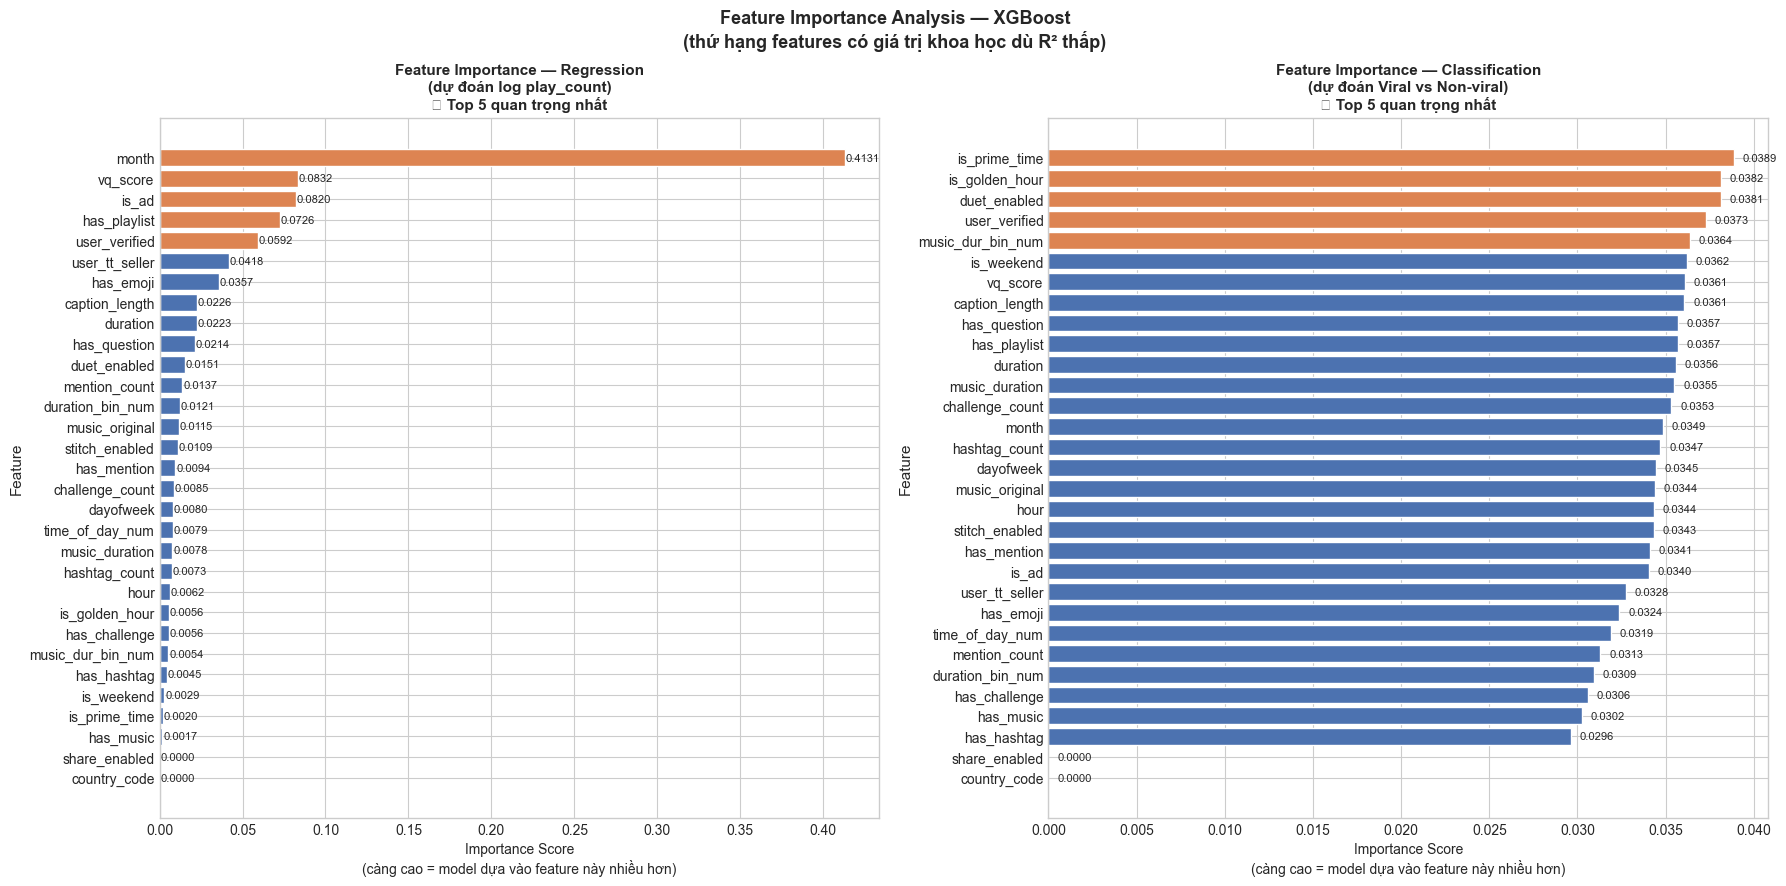

🏆 TOP 10 FEATURES — REGRESSION
   1. month                        0.4131  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
   2. vq_score                     0.0832  ████████████████████████
   3. is_ad                        0.0820  ████████████████████████
   4. has_playlist                 0.0726  █████████████████████
   5. user_verified                0.0592  █████████████████
   6. user_tt_seller               0.0418  ████████████
   7. has_emoji                    0.0357  ██████████
   8. caption_length               0.0226  ██████
   9. duration                     0.0223  ██████
  10. has_question                 0.0214  ██████

🏆 TOP 10 FEATURES — CLASSIFICATION
   1. is_prime_time                0.0389  ███████████
   2. is_golden_hour               0.0382  ███████████
   3. duet_enabled                 0.0381  ███████████
   4. user_verified                0.0373  ███████████
   5. music_dur_bin_num 

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

xgb_reg_model = trained_regs['XGBoost']
xgb_clf_model = trained_clfs['XGBoost']

feat_imp_reg = pd.Series(
    xgb_reg_model.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

feat_imp_clf = pd.Series(
    xgb_clf_model.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

for ax, feat_imp, title in [
    (axes[0], feat_imp_reg,
     'Feature Importance — Regression\n(dự đoán log play_count)\n🟠 Top 5 quan trọng nhất'),
    (axes[1], feat_imp_clf,
     'Feature Importance — Classification\n(dự đoán Viral vs Non-viral)\n🟠 Top 5 quan trọng nhất')
]:
    colors_fi = ['#DD8452' if i < 5 else '#4C72B0'
                 for i in range(len(feat_imp))]
    ax.barh(feat_imp.index[::-1], feat_imp.values[::-1],
            color=colors_fi[::-1], edgecolor='white')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel(
        'Importance Score\n(càng cao = model dựa vào feature này nhiều hơn)',
        fontsize=10
    )
    ax.set_ylabel('Feature', fontsize=11)
    for bar, val in zip(ax.patches, feat_imp.values[::-1]):
        ax.text(bar.get_width() + 0.0005,
                bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)

plt.suptitle(
    'Feature Importance Analysis — XGBoost\n'
    '(thứ hạng features có giá trị khoa học dù R² thấp)',
    fontweight='bold', fontsize=13
)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('=' * 60)
print('🏆 TOP 10 FEATURES — REGRESSION')
print('=' * 60)
for i, (feat, val) in enumerate(feat_imp_reg.head(10).items(), 1):
    bar = '█' * int(val * 300)
    print(f'  {i:2}. {feat:<28} {val:.4f}  {bar}')

print('\n🏆 TOP 10 FEATURES — CLASSIFICATION')
print('=' * 60)
for i, (feat, val) in enumerate(feat_imp_clf.head(10).items(), 1):
    bar = '█' * int(val * 300)
    print(f'  {i:2}. {feat:<28} {val:.4f}  {bar}')

SHAP Summary

C:\Users\Lappro\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Lappro\AppData\Roaming\Python\Python312\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Lappro\AppData\Roaming\Python\Python312\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Lappro\AppData\Local\Temp\ipykernel_15036\3990538474.py:56: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
C:\Users\Lappro\AppData\Local\Temp\ipykernel_15036\3990538474.py:56: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s)

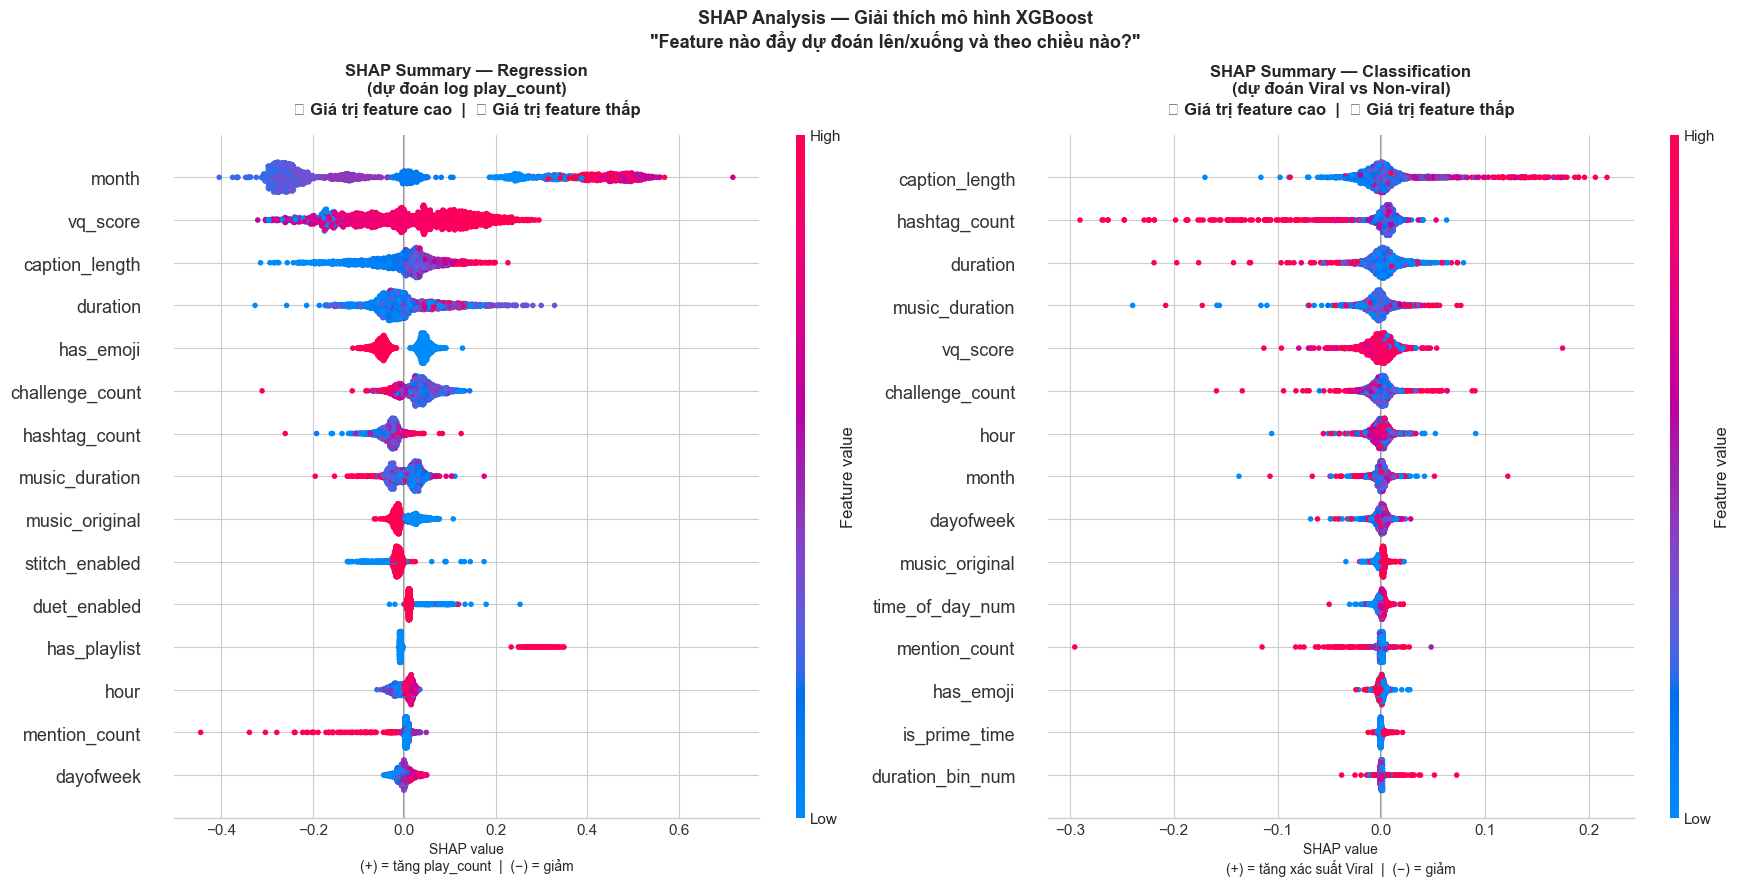

In [44]:
import shap

# print('⏳ Tính SHAP values (~2–3 phút)...')
# t0 = time.time()

X_shap = X_test.sample(2000, random_state=SEED)

explainer_reg   = shap.TreeExplainer(xgb_reg_model)
shap_values_reg = explainer_reg.shap_values(X_shap)

explainer_clf   = shap.TreeExplainer(xgb_clf_model)
shap_values_clf = explainer_clf.shap_values(X_shap)

# print(f'✅ Xong! ({time.time()-t0:.1f}s)')

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

plt.sca(axes[0])
shap.summary_plot(
    shap_values_reg, X_shap,
    feature_names=FEATURE_COLS,
    show=False, max_display=15, plot_size=None
)
axes[0].set_title(
    'SHAP Summary — Regression\n(dự đoán log play_count)\n'
    '🔴 Giá trị feature cao  |  🔵 Giá trị feature thấp',
    fontweight='bold', pad=15
)
axes[0].set_xlabel(
    'SHAP value\n(+) = tăng play_count  |  (−) = giảm',
    fontsize=10
)

plt.sca(axes[1])
shap.summary_plot(
    shap_values_clf, X_shap,
    feature_names=FEATURE_COLS,
    show=False, max_display=15, plot_size=None
)
axes[1].set_title(
    'SHAP Summary — Classification\n(dự đoán Viral vs Non-viral)\n'
    '🔴 Giá trị feature cao  |  🔵 Giá trị feature thấp',
    fontweight='bold', pad=15
)
axes[1].set_xlabel(
    'SHAP value\n(+) = tăng xác suất Viral  |  (−) = giảm',
    fontsize=10
)

plt.suptitle(
    'SHAP Analysis — Giải thích mô hình XGBoost\n'
    '"Feature nào đẩy dự đoán lên/xuống và theo chiều nào?"',
    fontweight='bold', fontsize=13
)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

SHAP Waterfall

⏳ Tính lại SHAP values...
✅ Xong!


C:\Users\Lappro\AppData\Local\Temp\ipykernel_15036\412886373.py:73: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Lappro\AppData\Local\Temp\ipykernel_15036\412886373.py:73: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Lappro\AppData\Local\Temp\ipykernel_15036\412886373.py:73: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Lappro\AppData\Local\Temp\ipykernel_15036\412886373.py:73: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Lappro\AppData\Local\Temp\ipykernel_15036\412886373.py:74: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
C:\Users\Lappro\AppData\Local\Temp\ipykernel_15036\412886373.py:74: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) 

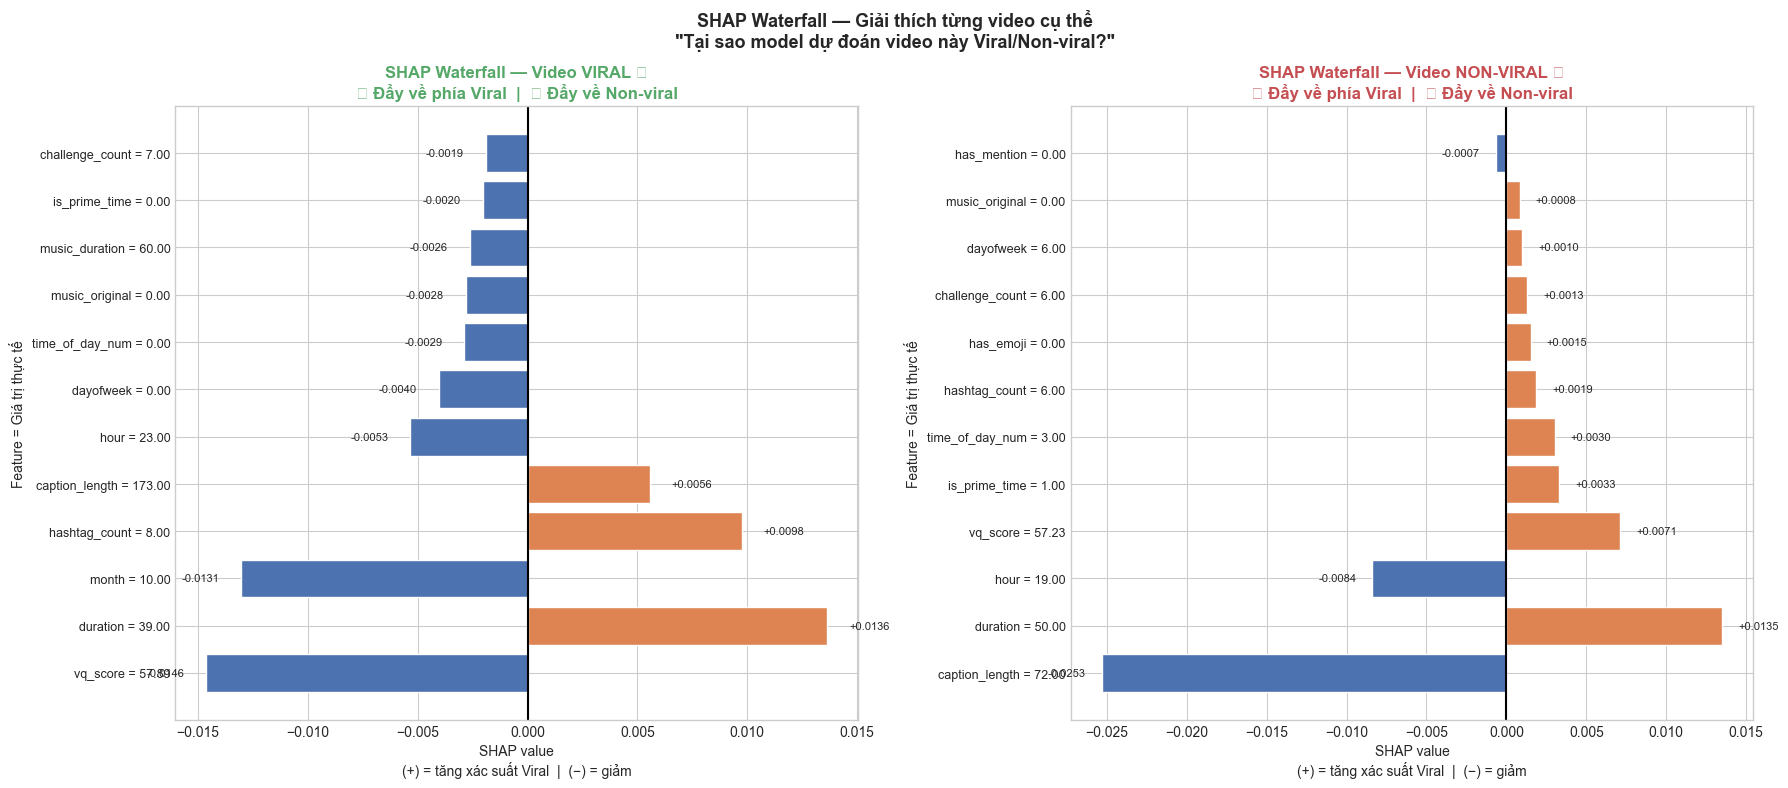

In [45]:
# ✅ Cell 5.14 — Fix triệt để bằng numpy

# Reset cả X_test và y_clf_test về integer index trước
X_test_r     = X_test.reset_index(drop=True)
y_clf_test_r = y_clf_test.reset_index(drop=True)

# Sample lại X_shap từ X_test đã reset index
X_shap       = X_test_r.sample(2000, random_state=SEED)
X_shap_reset = X_shap.reset_index(drop=True)

# Tính lại SHAP với X_shap mới
print("⏳ Tính lại SHAP values...")
shap_values_clf = explainer_clf.shap_values(X_shap)
print("✅ Xong!")

# Lấy labels tương ứng theo integer index
y_shap_labels = y_clf_test_r.iloc[X_shap.index].reset_index(drop=True)

viral_idx    = y_shap_labels[y_shap_labels == 1].index[0]
nonviral_idx = y_shap_labels[y_shap_labels == 0].index[0]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, idx, label, color in [
    (axes[0], viral_idx,    'VIRAL ✅',     '#55A868'),
    (axes[1], nonviral_idx, 'NON-VIRAL ❌', '#C44E52')
]:
    sv = shap_values_clf[idx]

    shap_df = pd.DataFrame({
        'feature': FEATURE_COLS,
        'value'  : X_shap_reset.iloc[idx].values,
        'shap'   : sv
    })
    shap_df = shap_df.reindex(
        shap_df['shap'].abs().sort_values(ascending=False).index
    ).head(12).reset_index(drop=True)

    colors_w = ['#DD8452' if v > 0 else '#4C72B0'
                for v in shap_df['shap']]
    ax.barh(range(len(shap_df)), shap_df['shap'],
            color=colors_w, edgecolor='white')
    ax.set_yticks(range(len(shap_df)))
    ax.set_yticklabels([
        f"{r['feature']} = {r['value']:.2f}"
        for _, r in shap_df.iterrows()
    ], fontsize=9)
    ax.axvline(0, color='black', linewidth=1.5)
    ax.set_title(
        f'SHAP Waterfall — Video {label}\n'
        '🟠 Đẩy về phía Viral  |  🔵 Đẩy về Non-viral',
        fontweight='bold', color=color
    )
    ax.set_xlabel(
        'SHAP value\n(+) = tăng xác suất Viral  |  (−) = giảm',
        fontsize=10
    )
    ax.set_ylabel('Feature = Giá trị thực tế', fontsize=10)
    for bar, val in zip(ax.patches, shap_df['shap']):
        ax.text(
            bar.get_width() + (0.001 if val >= 0 else -0.001),
            bar.get_y() + bar.get_height()/2,
            f'{val:+.4f}', va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=8
        )

plt.suptitle(
    'SHAP Waterfall — Giải thích từng video cụ thể\n'
    '"Tại sao model dự đoán video này Viral/Non-viral?"',
    fontweight='bold', fontsize=13
)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
# Kiểm tra biến nào còn, biến nào mất
check_vars = {
    'X_test'        : 'Cell 5.1',
    'X_train'       : 'Cell 5.1',
    'y_reg_test'    : 'Cell 5.1',
    'y_clf_test'    : 'Cell 5.1',
    'FEATURE_COLS'  : 'Cell 5.1',
    'SEED'          : 'Cell 5.1',
    'trained_regs'  : 'Cell 5.2',
    'reg_results'   : 'Cell 5.2',
    'trained_clfs'  : 'Cell 5.4',
    'clf_results'   : 'Cell 5.4',
    'xgb_reg_model' : 'Cell 5.12',
    'xgb_clf_model' : 'Cell 5.12',
}

print('📊 Kiểm tra biến:')
print('-' * 40)
for var, source in check_vars.items():
    status = '✅ OK' if var in dir() else f'❌ MISSING → chạy lại {source}'
    print(f'  {var:<20} {status}')

📊 Kiểm tra biến:
----------------------------------------
  X_test               ✅ OK
  X_train              ✅ OK
  y_reg_test           ✅ OK
  y_clf_test           ✅ OK
  FEATURE_COLS         ✅ OK
  SEED                 ✅ OK
  trained_regs         ✅ OK
  reg_results          ✅ OK
  trained_clfs         ✅ OK
  clf_results          ✅ OK
  xgb_reg_model        ✅ OK
  xgb_clf_model        ✅ OK
